# EEGNet 四数据集论文复现 notebook（四个 zip 最小跑通版）

这一版专门适配你现在云端上传的四个独立 zip：

- `ERN小测试集.zip`
- `ERP-P300替代数据集.zip`
- `MRCP数据集.zip`
- `SMR数据集.zip`

本版重点：

1. **不再解压旧的 `四组数据集.zip`**，避免卡在 `replace ... ? [y/n/A/N]`。
2. 所有解压都使用 `unzip -oq`，自动覆盖且静默，不会再等待输入。
3. 默认 `RUN_PROFILE = "smoke"`，每组只取 4 个 subject、训练很少 epoch，用来快速检查完整流程能否跑通。
4. 会在关键步骤前后打印 GPU 状态。

说明：smoke 版只用于确认流程，不用于最终论文结果。正式全量运行请在跑通后把 `RUN_PROFILE` 改成 `normal_all`。


## 使用说明

你现在只需要按顺序运行：

1. Cell 0：依赖已经装过可以跳过；
2. Cell 1：路径设置 + 四个 zip 自动解压；
3. Cell 2：运行参数和 GPU 检查；
4. Cell 3–Cell 6：模型、工具函数、四组数据加载；
5. Cell 11 / 12：within-subject 和 cross-subject 最小跑通；
6. Cell 13 之后：画论文风格图表。

如果 Cell 1 发现旧解压目录存在，会直接跳过。若你重新上传了 zip，想强制重新解压，把 Cell 1 里的 `FORCE_REEXTRACT = True`。


## 本版修复点

之前卡住的位置是因为命令：

```bash
unzip -q 四组数据集.zip -d 机器学习proj_上传AutoDL
```

遇到已有同名文件时会询问：

```text
replace ... ? [y]es, [n]o, [A]ll, [N]one, [r]ename:
```

Jupyter 无法自动回答，所以会一直卡住。本版不使用这条命令，改为四个 zip 分别解压，并使用 `unzip -oq`。


In [1]:
# 查看 /root/autodl-tmp 下的文件，确认四个 zip 是否在这里
!ls -lh /root/autodl-tmp


total 2.9G
drwxr-xr-x 6 root root   72 May 31 05:18 EEGNet_four_zip_extracted
drwxr-xr-x 2 root root  28K May 31 05:30 EEGNet_reproduction_outputs_smoke_fourzip
-rw-r--r-- 1 root root 360K May 31 05:34 EEGNet_四zip数据集_最多10subject_P300正确事件最终版.ipynb
-rw-r--r-- 1 root root 3.9M May 31 05:35 EEGNet_四zip数据集_最多10subject_仅修ERN56通道版.ipynb
-rw-r--r-- 1 root root 3.9M May 31 04:07 EEGNet_四zip数据集_最小跑通_P300事件稳健修正版.ipynb
-rw-r--r-- 1 root root 2.1G May 31 02:32 ERN大测试集.zip
-rw-r--r-- 1 root root 353M May 31 02:27 ERP-P300替代数据集.zip
-rw-r--r-- 1 root root  43M May 31 02:26 MRCP数据集.zip
-rw-r--r-- 1 root root 420M May 31 02:27 SMR数据集.zip


In [2]:
# 这一格不再手动解压旧的“四组数据集.zip”。
# 所有解压都在下一个“路径设置 + 自动解压”cell 内完成，且使用 unzip -oq，不会卡在 replace 提示。
print("跳过旧手动解压 cell：请继续运行下一格 Cell 1。")


跳过旧手动解压 cell：请继续运行下一格 Cell 1。


In [3]:
# Cell 0：安装依赖，只需要第一次运行
# 如果已经装过，可以直接跳过本 cell

import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorflow mne pyriemann scikit-learn matplotlib pandas numpy scipy h5py tqdm

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [4]:
# Cell 1：路径设置 + 四个 zip 自动解压【无卡顿版】
# 目标：直接使用你现在云端上传的四个独立 zip：
#   ERN大测试集.zip / ERN小测试集.zip
#   ERP-P300替代数据集.zip
#   MRCP数据集.zip
#   SMR数据集.zip
# 关键修复：所有解压命令都使用 unzip -oq，不会再卡在 replace ... ? [y/n/A/N]

from pathlib import Path
import os, re, shutil, subprocess

AUTODL_DIR = Path("/root/autodl-tmp")
EXTRACT_ROOT = AUTODL_DIR / "EEGNet_four_zip_extracted"

# 如果你刚刚重新上传/替换了 zip，想重新解压，改成 True；平时保持 False 可节省时间。
# 本版会记录 source zip；如果 zip 名/大小/修改时间变了，即使 False 也会自动重解压，避免还在用旧小测试集。
FORCE_REEXTRACT = False


def _run(cmd):
    print(">", " ".join(map(str, cmd)))
    subprocess.run(list(map(str, cmd)), check=True)


def _first_existing(patterns, exclude_patterns=None):
    """在 /root/autodl-tmp 下按多个 pattern 找 zip。"""
    exclude_patterns = exclude_patterns or []
    hits = []
    for pat in patterns:
        hits.extend(sorted(AUTODL_DIR.glob(pat)))
    clean = []
    for p in hits:
        name = p.name
        if any(re.search(ep, name, re.I) for ep in exclude_patterns):
            continue
        if p not in clean:
            clean.append(p)
    return clean[0] if clean else None


def _unzip_if_needed(zip_path, out_dir, force=False):
    """安全解压：使用 unzip -oq，自动覆盖、不询问；解压到独立目录，避免和旧数据混在一起。"""
    zip_path = Path(zip_path) if zip_path is not None else None
    out_dir = Path(out_dir)

    if zip_path is None or not zip_path.exists():
        print(f"⚠️ 找不到 zip：{zip_path}")
        return False

    if force and out_dir.exists():
        print(f"删除旧解压目录：{out_dir}")
        shutil.rmtree(out_dir)

    out_dir.mkdir(parents=True, exist_ok=True)

    # 已经解压过则跳过，避免每次都浪费时间；但如果 zip 换了，就自动清空重解压。
    marker = out_dir / ".source_zip.txt"
    current_sig = f"{zip_path.resolve()}|size={zip_path.stat().st_size}|mtime={zip_path.stat().st_mtime}"
    if any(out_dir.iterdir()) and not force:
        old_sig = marker.read_text(encoding="utf-8") if marker.exists() else ""
        if old_sig == current_sig:
            print(f"已存在且来源 zip 未变化，跳过解压：{out_dir}")
            return True
        print(f"检测到 zip 已变化或旧目录无来源记录，重新解压：{zip_path.name} -> {out_dir}")
        shutil.rmtree(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

    _run(["unzip", "-oq", zip_path, "-d", out_dir])
    marker.write_text(current_sig, encoding="utf-8")
    print(f"✅ 解压完成：{zip_path.name} -> {out_dir}")
    return True


def _has_case_insensitive_file(root, filename):
    root = Path(root)
    target = filename.lower()
    return any(p.is_file() and p.name.lower() == target for p in root.iterdir()) if root.exists() else False


def _find_case_insensitive_file(root, filename):
    root = Path(root)
    target = filename.lower()
    for p in root.iterdir():
        if p.is_file() and p.name.lower() == target:
            return p
    return root / filename


def _find_ern_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for p in candidates:
        if (p / "train").exists() and _has_case_insensitive_file(p, "TrainLabels.csv"):
            return p
    raise FileNotFoundError(f"在 {root} 中没有找到 ERN 结构：train/ + TrainLabels.csv")


def _find_p300_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for p in candidates:
        n1 = len(list(p.glob("s[0-9][0-9]/rc*.edf")))
        n2 = len(list(p.glob("S[0-9][0-9]/rc*.edf")))
        if n1 + n2 > 0:
            return p
    edfs = list(root.rglob("rc*.edf"))
    if edfs:
        parents = {}
        for f in edfs:
            parents[f.parent.parent] = parents.get(f.parent.parent, 0) + 1
        return max(parents, key=parents.get)
    raise FileNotFoundError(f"在 {root} 中没有找到 P300 的 sXX/rc*.edf 结构")


def _find_mrcp_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for p in candidates:
        if len(list(p.glob("S*/S*R*.edf"))) > 0:
            return p
    edfs = list(root.rglob("*.edf"))
    if edfs:
        parents = {}
        for f in edfs:
            parent = f.parent.parent if re.fullmatch(r"S\d+", f.parent.name, re.I) else f.parent
            parents[parent] = parents.get(parent, 0) + 1
        return max(parents, key=parents.get)
    raise FileNotFoundError(f"在 {root} 中没有找到 MRCP EDF 文件")


def _find_smr_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for p in candidates:
        if len(list(p.glob("A*T.gdf"))) > 0:
            return p
    raise FileNotFoundError(f"在 {root} 中没有找到 SMR 的 A*T.gdf 文件")


# 1) 识别四个 zip
ERN_ZIP = _first_existing(["*ERN*大测试*.zip", "*ERN*大*.zip", "*ERN*小测试*.zip", "*ERN*.zip"], exclude_patterns=[r"四组"])
P300_ZIP = _first_existing(["*ERP-P300*替代*.zip", "*P300*替代*.zip", "*RP-300*替代*.zip", "*P-300*替代*.zip"])
MRCP_ZIP = _first_existing(["*MRCP*数据集*.zip", "*MRCP*.zip"])
SMR_ZIP = _first_existing(["*SMR*数据集*.zip", "*SMR*.zip"], exclude_patterns=[r"四组"])

print("识别到 ERN zip :", ERN_ZIP)
print("识别到 P300 zip:", P300_ZIP)
print("识别到 MRCP zip:", MRCP_ZIP)
print("识别到 SMR zip :", SMR_ZIP)

# 2) 分别解压到独立目录，避免互相覆盖/卡住
ERN_EXTRACT  = EXTRACT_ROOT / "ERN"
P300_EXTRACT = EXTRACT_ROOT / "P300"
MRCP_EXTRACT = EXTRACT_ROOT / "MRCP"
SMR_EXTRACT  = EXTRACT_ROOT / "SMR"

_unzip_if_needed(ERN_ZIP, ERN_EXTRACT, force=FORCE_REEXTRACT)
_unzip_if_needed(P300_ZIP, P300_EXTRACT, force=FORCE_REEXTRACT)
_unzip_if_needed(MRCP_ZIP, MRCP_EXTRACT, force=FORCE_REEXTRACT)
_unzip_if_needed(SMR_ZIP, SMR_EXTRACT, force=FORCE_REEXTRACT)

# 3) 自动定位真正的数据根目录
DATA_PATHS = {
    "ERN": _find_ern_root(ERN_EXTRACT),
    "P300": _find_p300_root(P300_EXTRACT),
    "MRCP": _find_mrcp_root(MRCP_EXTRACT),
    "SMR": _find_smr_root(SMR_EXTRACT),
}

OUTPUT_DIR = AUTODL_DIR / "EEGNet_reproduction_outputs_smoke_fourzip"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\n========== DATA_PATHS ==========")
for name, path in DATA_PATHS.items():
    print(f"{name:5s} -> {path} | exists={path.exists()}")

print("\n输出文件夹:", OUTPUT_DIR)

# 4) 结构检查：先确认不会缺核心文件
print("\n========== 数据结构快速检查 ==========")
# ERN
try:
    ern_root = DATA_PATHS["ERN"]
    label_p = _find_case_insensitive_file(ern_root, "TrainLabels.csv")
    chan_p = _find_case_insensitive_file(ern_root, "ChannelsLocation.csv")
    ern_train_files = sorted((ern_root / "train").glob("*.csv"))
    print(f"ERN : train csv={len(ern_train_files)}, TrainLabels={label_p.exists()}, ChannelsLocation={chan_p.exists()}")
except Exception as e:
    print("ERN 检查失败:", e)

# P300
try:
    p300_root = DATA_PATHS["P300"]
    p300_subjects = sorted([p.name for p in p300_root.glob("s*") if p.is_dir()])
    p300_edfs = sorted(p300_root.glob("s*/rc*.edf"))
    p300_missing_event = [p for p in p300_edfs if not Path(str(p)+".event").exists()]
    print(f"P300: subjects={len(p300_subjects)} {p300_subjects[:15]}, edf={len(p300_edfs)}, missing_event={len(p300_missing_event)}")
except Exception as e:
    print("P300 检查失败:", e)

# MRCP
try:
    mrcp_root = DATA_PATHS["MRCP"]
    mrcp_subjects = sorted([p.name for p in mrcp_root.glob("S*") if p.is_dir()])
    mrcp_edfs = sorted(mrcp_root.glob("S*/*.edf"))
    mrcp_missing_event = [p for p in mrcp_edfs if not Path(str(p)+".event").exists()]
    print(f"MRCP: subjects={len(mrcp_subjects)} {mrcp_subjects[:15]}, edf={len(mrcp_edfs)}, missing_event={len(mrcp_missing_event)}")
except Exception as e:
    print("MRCP 检查失败:", e)

# SMR
try:
    smr_root = DATA_PATHS["SMR"]
    t_files = sorted(smr_root.glob("A*T.gdf"))
    e_files = sorted(smr_root.glob("A*E.gdf"))
    print(f"SMR : T files={len(t_files)} {[p.name for p in t_files]}, E files={len(e_files)} {[p.name for p in e_files]}")
    print("      训练/评价将只使用 A*T.gdf；A*E.gdf 没有标签时不用于 accuracy。")
except Exception as e:
    print("SMR 检查失败:", e)


识别到 ERN zip : /root/autodl-tmp/ERN大测试集.zip
识别到 P300 zip: /root/autodl-tmp/ERP-P300替代数据集.zip
识别到 MRCP zip: /root/autodl-tmp/MRCP数据集.zip
识别到 SMR zip : /root/autodl-tmp/SMR数据集.zip
已存在且来源 zip 未变化，跳过解压：/root/autodl-tmp/EEGNet_four_zip_extracted/ERN
已存在且来源 zip 未变化，跳过解压：/root/autodl-tmp/EEGNet_four_zip_extracted/P300
已存在且来源 zip 未变化，跳过解压：/root/autodl-tmp/EEGNet_four_zip_extracted/MRCP
已存在且来源 zip 未变化，跳过解压：/root/autodl-tmp/EEGNet_four_zip_extracted/SMR

========== DATA_PATHS ==========
ERN   -> /root/autodl-tmp/EEGNet_four_zip_extracted/ERN/ERN大测试集 | exists=True
P300  -> /root/autodl-tmp/EEGNet_four_zip_extracted/P300/ERP-P300替代数据集 | exists=True
MRCP  -> /root/autodl-tmp/EEGNet_four_zip_extracted/MRCP/MRCP数据集 | exists=True
SMR   -> /root/autodl-tmp/EEGNet_four_zip_extracted/SMR/SMR数据集 | exists=True

输出文件夹: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip

========== 数据结构快速检查 ==========
ERN : train csv=45, TrainLabels=True, ChannelsLocation=True
P300: subjects=10 ['s01', 's02', 's03', '

In [5]:
# Cell 2：导入库 + 固定随机种子 + 运行模式【GPU检查 + 最小/正式两档】

import os
import re
import glob
import math
import random
import itertools
import warnings
import subprocess
warnings.filterwarnings("ignore")

# 减少 TensorFlow 冗余日志
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import utils as np_utils
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D, BatchNormalization,
    Activation, AveragePooling2D, MaxPooling2D, Dropout, SpatialDropout2D,
    Flatten, Dense, Permute
)
from tensorflow.keras.models import Model

import mne
from mne.time_frequency import tfr_array_morlet
from mne.decoding import CSP

from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import KFold
from sklearn.multiclass import OneVsRestClassifier

from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace

# ============================================================
# 运行档位：
# smoke       ：小规模复现版。每组最多取 10 个 subject；不足 10 个就用最多数量，epochs 较少。
# normal_all  ：正式全量版。四个 zip 都读取全部可用 subject。
# paperfull   ：最接近原论文 500 epochs，很慢，一般不建议课程项目直接跑。
# ============================================================
RUN_PROFILE = "smoke"   # 本版 smoke=每组最多 10 个 subject；若以后想全量再改成 "normal_all"

if RUN_PROFILE == "smoke":
    # 小规模复现：每组最多 10 个 subject，先确认多 subject 读取、训练、保存、画图都不报错
    EPOCHS = 3
    CROSS_FOLDS = 3
    CROSS_VAL_SUBJECTS = 1
    SMR_CROSS_REPEATS = 1
    SUBJECT_LIMITS = {
        "P300": 10,
        "MRCP": 10,
        "SMR": 10,
        "ERN": 10,
    }
    # smoke 版保留所有模型，保证 Figure 2-5 的柱子都能生成；若还嫌慢，可临时只留 EEGNet-8,2。
    MODEL_NAMES = ["DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"]

elif RUN_PROFILE == "normal_all":
    # 正式全量：比原论文少 epochs，但 subject/folds 设置尽量接近论文
    EPOCHS = 100
    CROSS_FOLDS = 30
    CROSS_VAL_SUBJECTS = 4
    SMR_CROSS_REPEATS = 10
    SUBJECT_LIMITS = {
        "P300": None,
        "MRCP": None,
        "SMR": None,
        "ERN": None,
    }
    MODEL_NAMES = ["DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"]

elif RUN_PROFILE == "paperfull":
    # 理论上最接近论文：500 epochs + 30 folds + SMR 90 folds，可能非常慢
    EPOCHS = 500
    CROSS_FOLDS = 30
    CROSS_VAL_SUBJECTS = 4
    SMR_CROSS_REPEATS = 10
    SUBJECT_LIMITS = {
        "P300": None,
        "MRCP": None,
        "SMR": None,
        "ERN": None,
    }
    MODEL_NAMES = ["DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"]

else:
    raise ValueError("RUN_PROFILE 只能是 smoke / normal_all / paperfull")

BATCH_SIZE = 16
RANDOM_SEED = 42

# 原文 Table 1 信息，用于后面自动生成“原文 vs 当前数据”对照表。
PAPER_TABLE1_INFO = {
    "P300": {"feature_type": "ERP", "bandpass": "1–40", "paper_subjects": 15, "paper_trials_per_subject": "~2000", "paper_classes": 2, "paper_imbalance": "Yes, ~5.6:1", "metric": "AUC"},
    "ERN":  {"feature_type": "ERP", "bandpass": "1–40", "paper_subjects": 26, "paper_trials_per_subject": "340", "paper_classes": 2, "paper_imbalance": "Yes, ~3.4:1", "metric": "AUC"},
    "MRCP": {"feature_type": "ERP/Oscillatory", "bandpass": "0.1–40", "paper_subjects": 13, "paper_trials_per_subject": "~1100", "paper_classes": 2, "paper_imbalance": "No", "metric": "AUC"},
    "SMR":  {"feature_type": "Oscillatory", "bandpass": "4–40", "paper_subjects": 9, "paper_trials_per_subject": "288", "paper_classes": 4, "paper_imbalance": "No", "metric": "Accuracy"},
}

def get_subject_limit(dataset_name):
    return SUBJECT_LIMITS.get(dataset_name, None)

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def gpu_status(tag=""):
    """打印当前是否识别 GPU，以及 nvidia-smi 中 python 是否占用 GPU。"""
    gpus = tf.config.list_physical_devices("GPU")
    print("\n" + "=" * 70)
    print(f"GPU CHECK | {tag}")
    print("TensorFlow:", tf.__version__)
    print("tf GPUs:", gpus)
    if gpus:
        print("✅ TensorFlow 已识别 GPU，CNN 的 model.fit 会优先用 GPU。")
    else:
        print("❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。")
    try:
        out = subprocess.check_output(
            "nvidia-smi --query-gpu=name,memory.used,memory.total,utilization.gpu --format=csv,noheader,nounits",
            shell=True, text=True
        ).strip()
        print("nvidia-smi:", out)
    except Exception as e:
        print("nvidia-smi 不可用：", repr(e))
    print("=" * 70 + "\n")

set_seed(RANDOM_SEED)
gpu_status("Cell 2 初始化完成")

print("RUN_PROFILE:", RUN_PROFILE)
print("EPOCHS:", EPOCHS, "| CROSS_FOLDS:", CROSS_FOLDS, "| CROSS_VAL_SUBJECTS:", CROSS_VAL_SUBJECTS)
print("SMR_CROSS_REPEATS:", SMR_CROSS_REPEATS)
print("SUBJECT_LIMITS:", SUBJECT_LIMITS)
print("MODEL_NAMES:", MODEL_NAMES)


I0000 00:00:1780176912.638718  470939 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780176912.639667  470939 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780176913.629505  470939 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780176913.630020  470939 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.



GPU CHECK | Cell 2 初始化完成
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100

RUN_PROFILE: smoke
EPOCHS: 3 | CROSS_FOLDS: 3 | CROSS_VAL_SUBJECTS: 1
SMR_CROSS_REPEATS: 1
SUBJECT_LIMITS: {'P300': 10, 'MRCP': 10, 'SMR': 10, 'ERN': 10}
MODEL_NAMES: ['DeepConvNet', 'ShallowConvNet', 'EEGNet-4,2', 'EEGNet-8,2']


E0000 00:00:1780176914.348801  470939 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


In [6]:
# Cell 3：EEGNet / DeepConvNet / ShallowConvNet 模型定义
# 说明：这里直接内置模型，不依赖外部 EEGModels.py，避免路径出错。
# 输入格式统一为 trials × channels × samples × 1。

def square(x):
    return K.square(x)

def log_activation(x):
    return K.log(K.clip(x, min_value=1e-7, max_value=10000))

def EEGNet_custom(
    nb_classes,
    Chans=64,
    Samples=128,
    dropoutRate=0.5,
    kernLength=64,
    F1=8,
    D=2,
    F2=16,
    norm_rate=0.25,
    dropoutType="Dropout"
):
    if dropoutType == "SpatialDropout2D":
        dropout_layer = SpatialDropout2D
    elif dropoutType == "Dropout":
        dropout_layer = Dropout
    else:
        raise ValueError("dropoutType 必须是 Dropout 或 SpatialDropout2D")

    input1 = Input(shape=(Chans, Samples, 1), name="eeg_input")

    block1 = Conv2D(
        F1, (1, kernLength), padding="same", use_bias=False,
        name="conv_temporal"
    )(input1)
    block1 = BatchNormalization(name="bn_temporal")(block1)

    block1 = DepthwiseConv2D(
        (Chans, 1), use_bias=False, depth_multiplier=D,
        depthwise_constraint=max_norm(1.0),
        name="conv_spatial"
    )(block1)
    block1 = BatchNormalization(name="bn_spatial")(block1)
    block1 = Activation("elu", name="elu_spatial")(block1)
    block1 = AveragePooling2D((1, 4), name="avg_pool_1")(block1)
    block1 = dropout_layer(dropoutRate, name="dropout_1")(block1)

    block2 = SeparableConv2D(
        F2, (1, 16), use_bias=False, padding="same",
        name="separable_conv"
    )(block1)
    block2 = BatchNormalization(name="bn_separable")(block2)
    block2 = Activation("elu", name="elu_separable")(block2)
    block2 = AveragePooling2D((1, 8), name="avg_pool_2")(block2)
    block2 = dropout_layer(dropoutRate, name="dropout_2")(block2)

    flatten = Flatten(name="flatten")(block2)

    dense = Dense(
        nb_classes,
        name="dense",
        kernel_constraint=max_norm(norm_rate)
    )(flatten)
    softmax = Activation("softmax", name="softmax")(dense)

    return Model(inputs=input1, outputs=softmax, name=f"EEGNet_F{F1}_D{D}")


def DeepConvNet_custom(nb_classes, Chans=64, Samples=128, dropoutRate=0.5):
    input_main = Input((Chans, Samples, 1), name="eeg_input")

    block1 = Conv2D(25, (1, 5), padding="valid", use_bias=False, name="deep_conv_t1")(input_main)
    block1 = Conv2D(25, (Chans, 1), padding="valid", use_bias=False, name="deep_conv_s1")(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation("elu")(block1)
    block1 = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block1)
    block1 = Dropout(dropoutRate)(block1)

    block2 = Conv2D(50, (1, 5), padding="valid", use_bias=False)(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation("elu")(block2)
    block2 = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block2)
    block2 = Dropout(dropoutRate)(block2)

    block3 = Conv2D(100, (1, 5), padding="valid", use_bias=False)(block2)
    block3 = BatchNormalization()(block3)
    block3 = Activation("elu")(block3)
    block3 = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block3)
    block3 = Dropout(dropoutRate)(block3)

    block4 = Conv2D(200, (1, 5), padding="valid", use_bias=False)(block3)
    block4 = BatchNormalization()(block4)
    block4 = Activation("elu")(block4)
    block4 = MaxPooling2D(pool_size=(1, 2), strides=(1, 2))(block4)
    block4 = Dropout(dropoutRate)(block4)

    flatten = Flatten()(block4)
    dense = Dense(nb_classes, kernel_constraint=max_norm(0.5))(flatten)
    softmax = Activation("softmax")(dense)

    return Model(inputs=input_main, outputs=softmax, name="DeepConvNet")


def ShallowConvNet_custom(nb_classes, Chans=64, Samples=128, dropoutRate=0.5):
    input_main = Input((Chans, Samples, 1), name="eeg_input")

    block1 = Conv2D(40, (1, 13), padding="same", use_bias=False, name="shallow_conv_t")(input_main)
    block1 = Conv2D(40, (Chans, 1), padding="valid", use_bias=False, name="shallow_conv_s")(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation(square, name="square")(block1)

    pool_size = min(35, max(4, Samples // 4))
    pool_stride = max(2, pool_size // 5)
    block1 = AveragePooling2D(pool_size=(1, pool_size), strides=(1, pool_stride))(block1)
    block1 = Activation(log_activation, name="log")(block1)
    block1 = Dropout(dropoutRate)(block1)

    flatten = Flatten()(block1)
    dense = Dense(nb_classes, kernel_constraint=max_norm(0.5))(flatten)
    softmax = Activation("softmax")(dense)

    return Model(inputs=input_main, outputs=softmax, name="ShallowConvNet")


def build_model(
    model_name,
    nb_classes,
    chans,
    samples,
    fs=128,
    dataset_name="P300",
    cv_type="within"
):
    dropout_rate = 0.5 if cv_type == "within" else 0.25

    # 原文：128 Hz 一般 kernLength=64；SMR 高通 4 Hz，所以 kernLength=32。
    if dataset_name == "SMR":
        kern_length = 32
    else:
        kern_length = int(fs / 2)

    if model_name == "EEGNet-4,2":
        return EEGNet_custom(nb_classes, chans, samples, dropout_rate, kern_length, F1=4, D=2, F2=8)
    if model_name == "EEGNet-8,2":
        return EEGNet_custom(nb_classes, chans, samples, dropout_rate, kern_length, F1=8, D=2, F2=16)
    if model_name == "EEGNet-4,1":
        return EEGNet_custom(nb_classes, chans, samples, dropout_rate, kern_length, F1=4, D=1, F2=4)
    if model_name == "DeepConvNet":
        return DeepConvNet_custom(nb_classes, chans, samples, dropout_rate)
    if model_name == "ShallowConvNet":
        return ShallowConvNet_custom(nb_classes, chans, samples, dropout_rate)

    raise ValueError(f"未知模型名称：{model_name}")

MODEL_NAMES = ["DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"]

In [7]:
# Cell 4：通用工具函数
# 后面所有 loader 都会把数据整理成：
# X: trials × channels × samples
# y: 0,1,2,... 整数标签
# subjects: 每个 trial 对应 subject
# blocks: 每个 trial 对应 run/session/block，用于 within-subject blockwise CV

def encode_to_int(y):
    y = np.asarray(y)
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    return y_enc.astype(int), le

def as_4d(X):
    X = np.asarray(X, dtype="float32")
    if X.ndim == 3:
        return X[..., np.newaxis]
    if X.ndim == 4:
        return X
    raise ValueError(f"X 维度应为 3 或 4，当前 shape={X.shape}")

def infer_sfreq_from_time(time_values, default=200.0):
    time_values = np.asarray(time_values)
    diffs = np.diff(time_values)
    diffs = diffs[np.isfinite(diffs) & (diffs > 0)]
    if len(diffs) == 0:
        return float(default)
    dt = float(np.median(diffs))
    # 如果 dt 看起来是毫秒
    if dt > 1:
        return 1000.0 / dt
    return 1.0 / dt

def make_info_from_ch_names(ch_names, sfreq=128):
    info = mne.create_info(ch_names=list(ch_names), sfreq=sfreq, ch_types="eeg")
    # 尽量设置标准电极位置；设置失败不会影响训练，只影响 topomap。
    for montage_name in ["biosemi64", "standard_1005", "standard_1020"]:
        try:
            montage = mne.channels.make_standard_montage(montage_name)
            info.set_montage(montage, match_case=False, on_missing="ignore")
            break
        except Exception:
            pass
    return info


def info_has_eeg_locations(info):
    """检查 info 里是否真的有可用于 topomap 的 EEG 电极三维坐标。"""
    try:
        locs = np.array([ch["loc"][:3] for ch in info["chs"]], dtype=float)
        if locs.size == 0:
            return False
        return bool(np.isfinite(locs).all() and np.nanmax(np.linalg.norm(locs, axis=1)) > 1e-6)
    except Exception:
        return False

def plot_topomap_safe(values, info, ax, title="", cmap=None):
    """安全画 topomap：没有 montage 时自动退化成通道权重折线图，避免 Warning 刷屏和报错。"""
    values = np.asarray(values).ravel()
    try:
        if not info_has_eeg_locations(info):
            raise RuntimeError("info 中没有有效 electrode locations")
        mne.viz.plot_topomap(values, info, axes=ax, show=False, cmap=cmap)
    except Exception:
        ax.plot(values, linewidth=1.2)
        ax.axhline(0, linewidth=0.8, alpha=0.3)
        ax.set_xticks([])
        ax.set_yticks([])
    if title:
        ax.set_title(title)


def create_dataset(name, X, y, subjects, blocks, ch_names, sfreq=128, metric=None, class_weight=False, info=None):
    X = np.asarray(X, dtype="float32")
    y_enc, label_encoder = encode_to_int(y)
    subjects = np.asarray(subjects)
    blocks = np.asarray(blocks)

    if metric is None:
        metric = "accuracy" if len(np.unique(y_enc)) > 2 else "auc"

    if info is None:
        info = make_info_from_ch_names(ch_names, sfreq=sfreq)

    ds = {
        "name": name,
        "X": X,
        "y": y_enc,
        "subjects": subjects,
        "blocks": blocks,
        "ch_names": list(ch_names),
        "sfreq": int(round(sfreq)),
        "metric": metric,
        "class_weight": class_weight,
        "nb_classes": len(np.unique(y_enc)),
        "label_encoder": label_encoder,
        "info": info
    }

    print(f"\n========== {name} 数据检查 ==========")
    print("X:", ds["X"].shape, "| y:", ds["y"].shape)
    print("subjects:", len(np.unique(subjects)), np.unique(subjects)[:10])
    print("blocks:", len(np.unique(blocks)), np.unique(blocks)[:10])
    print("classes:", ds["nb_classes"], "| labels:", label_encoder.classes_)
    print("metric:", ds["metric"], "| class_weight:", ds["class_weight"])
    print("sfreq:", ds["sfreq"], "| channels:", len(ch_names))
    return ds

def make_class_weights(y_train):
    counts = np.bincount(y_train.astype(int))
    max_count = counts.max()
    return {i: float(max_count / c) if c > 0 else 1.0 for i, c in enumerate(counts)}

def evaluate_metric(y_true, probs, metric_name):
    preds = probs.argmax(axis=1)
    if metric_name == "auc":
        if probs.shape[1] != 2:
            return accuracy_score(y_true, preds)
        # 如果某个测试 fold 只有一个类别，AUC 无定义；退回 accuracy，避免中断。
        if len(np.unique(y_true)) < 2:
            return accuracy_score(y_true, preds)
        return roc_auc_score(y_true, probs[:, 1])
    if metric_name == "accuracy":
        return accuracy_score(y_true, preds)
    raise ValueError("metric_name 只能是 auc 或 accuracy")

def standardize_fold(X_train, X_val, X_test):
    # 按 channel 标准化，只用 train 的均值和方差，避免数据泄漏。
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    return (X_train - mean) / std, (X_val - mean) / std, (X_test - mean) / std

def subset_subjects(ds, max_subjects=None):
    if max_subjects is None:
        return ds
    keep_subjects = np.unique(ds["subjects"])[:max_subjects]
    mask = np.isin(ds["subjects"], keep_subjects)
    ds2 = ds.copy()
    for k in ["X", "y", "subjects", "blocks"]:
        ds2[k] = ds[k][mask]
    print(f"{ds['name']} debug 模式：只保留 subjects={keep_subjects}")
    return ds2


def read_external_event_file_generic(event_path, sfreq, n_times=None):
    """
    通用 .event / .evt 文本解析兜底。
    支持常见格式：
    - sample, code
    - time_seconds, code
    - POS/TYP/DUR 表格
    解析失败会返回 (None, None)。
    """
    event_path = Path(event_path)
    if not event_path.exists():
        return None, None

    # 尝试多种分隔符和 header 方式
    dfs = []
    for header in [0, None]:
        try:
            dfs.append(pd.read_csv(event_path, sep=None, engine="python", comment="#", header=header))
        except Exception:
            pass
        try:
            dfs.append(pd.read_csv(event_path, delim_whitespace=True, comment="#", header=header))
        except Exception:
            pass

    for df in dfs:
        if df is None or df.shape[1] < 2:
            continue

        original_cols = list(df.columns)
        low_cols = [str(c).lower() for c in original_cols]

        # 尽量找 position/time/sample 列和 type/code/event/label 列
        pos_col = None
        code_col = None

        for c, lc in zip(original_cols, low_cols):
            if re.search(r"pos|sample|onset|latency|time", lc):
                pos_col = c
                break

        for c, lc in zip(original_cols, low_cols):
            if re.search(r"typ|type|code|event|label|class|trigger|stim", lc):
                code_col = c
                break

        # 如果没有列名提示：默认第一列位置，最后一列事件码
        if pos_col is None:
            pos_col = original_cols[0]
        if code_col is None:
            code_col = original_cols[-1]

        pos = pd.to_numeric(df[pos_col], errors="coerce")
        code_raw = df[code_col].astype(str)

        valid = pos.notna() & code_raw.notna()
        pos = pos[valid].values.astype(float)
        code_raw = code_raw[valid].values

        if len(pos) == 0:
            continue

        # 判断 pos 是 samples / seconds / milliseconds
        max_pos = np.nanmax(pos)
        if n_times is not None and max_pos > n_times * 0.8:
            samples = pos.astype(int)
        elif max_pos < 1000:  # 多数情况下是秒
            samples = np.round(pos * sfreq).astype(int)
        else:                 # 可能是 ms
            samples = np.round(pos / 1000.0 * sfreq).astype(int)

        # 过滤 rest/0/boundary
        keep = []
        for i, code in enumerate(code_raw):
            if re.search(r"boundary|rest|T0|^0$|nan", str(code), re.I):
                continue
            if samples[i] < 0:
                continue
            if n_times is not None and samples[i] >= n_times:
                continue
            keep.append(i)

        if len(keep) == 0:
            continue

        samples = samples[keep]
        codes_text = code_raw[keep]
        le = LabelEncoder()
        codes_int = le.fit_transform(codes_text) + 1
        events = np.column_stack([samples, np.zeros(len(samples), dtype=int), codes_int.astype(int)])
        event_id = {str(label): int(i + 1) for i, label in enumerate(le.classes_)}
        return events, event_id

    return None, None


In [8]:
# Cell 5A：读取 ERN Kaggle / INRIA BCI Challenge CSV 数据
# 目标：接近原文 ERN 数据。原文 ERN 是 56 通道，epoch=[0,1.25]s，1-40Hz，128Hz，二分类 AUC。

def _find_label_columns(labels_df):
    cols = list(labels_df.columns)
    id_col = None
    for c in cols:
        if re.search(r"id|feedback|feed", c, re.I):
            id_col = c
            break
    if id_col is None:
        id_col = cols[0]

    label_candidates = [c for c in cols if c != id_col]
    # Kaggle 常见是 Prediction
    pred_cols = [c for c in label_candidates if re.search(r"pred|label|class|y", c, re.I)]
    label_col = pred_cols[0] if pred_cols else label_candidates[-1]
    return id_col, label_col

def _parse_subject_session_from_filename(path):
    name = Path(path).stem
    m = re.search(r"S(\d+).*?Sess(?:ion)?(\d+)", name, re.I)
    if m:
        return int(m.group(1)), int(m.group(2))
    m = re.search(r"Data_S(\d+)_Sess(\d+)", name, re.I)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

def _labels_for_ern_file(labels_df, id_col, label_col, subj, sess, global_cursor, n_events):
    # 优先按 ID 中的 Sxx / Sessyy 匹配；不行再按全局顺序切。
    id_str = labels_df[id_col].astype(str)
    mask = id_str.str.contains(f"S{subj:02d}", case=False, regex=False)
    mask &= id_str.str.contains(f"Sess{sess:02d}", case=False, regex=False) | id_str.str.contains(f"Sess{sess}", case=False, regex=False)
    rows = labels_df.loc[mask, label_col].values

    if len(rows) >= n_events:
        return rows[:n_events], global_cursor

    # 兜底：按 TrainLabels.csv 原始顺序取
    rows = labels_df[label_col].values[global_cursor:global_cursor+n_events]
    return rows, global_cursor + len(rows)

def _find_file_ci(root, filename):
    """case-insensitive 找文件：兼容 TrainLabels.csv / Trainlabels.csv 等大小写差异。"""
    root = Path(root)
    target = filename.lower()
    for p in root.iterdir():
        if p.is_file() and p.name.lower() == target:
            return p
    return root / filename


def load_ern_dataset(root):
    root = Path(root)
    train_dir = root / "train"
    label_path = _find_file_ci(root, "TrainLabels.csv")
    channel_path = _find_file_ci(root, "ChannelsLocation.csv")

    if not train_dir.exists():
        raise FileNotFoundError(f"找不到 ERN train 文件夹：{train_dir}")
    if not label_path.exists():
        raise FileNotFoundError(f"找不到 ERN TrainLabels.csv / Trainlabels.csv：{label_path}")
    if not channel_path.exists():
        print(f"⚠️ 找不到 ChannelsLocation.csv：{channel_path}。训练仍可继续，但 topomap/通道定位可能受影响。")

    print("ERN 只读取 train/ + TrainLabels，不读取 test/。")
    print("ERN label file:", label_path)
    labels_df = pd.read_csv(label_path)
    id_col, label_col = _find_label_columns(labels_df)
    print("ERN labels:", id_col, label_col)

    files = sorted(train_dir.glob("Data_S*_Sess*.csv"))
    if len(files) == 0:
        files = sorted(train_dir.glob("*.csv"))
    if len(files) == 0:
        raise FileNotFoundError(f"在 {train_dir} 找不到 csv 文件")

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref = None
    info_ref = None
    global_cursor = 0

    for f in tqdm(files, desc="Loading ERN csv"):
        subj, sess = _parse_subject_session_from_filename(f)
        if subj is None:
            subj, sess = 0, 0

        data = pd.read_csv(f)
        cols = list(data.columns)

        time_cols = [c for c in cols if re.fullmatch(r"time|timestamp|sample", c, re.I)]
        stim_cols = [c for c in cols if re.search(r"feedbackevent|event|stim|trigger", c, re.I)]

        time_col = time_cols[0] if time_cols else None
        stim_col = stim_cols[-1] if stim_cols else None
        if stim_col is None:
            raise ValueError(f"{f.name} 中找不到 FeedBackEvent/event/stim 列；实际列名={cols[:10]}...")

        exclude = set([stim_col])
        if time_col is not None:
            exclude.add(time_col)

        ch_names = [c for c in cols if c not in exclude]
        x_cont = data[ch_names].values.T.astype("float64")

        if time_col is not None:
            sfreq = infer_sfreq_from_time(data[time_col].values, default=200)
        else:
            sfreq = 200.0

        stim = data[stim_col].values
        stim_binary = np.asarray(stim != 0, dtype=int)
        event_samples = np.where(np.diff(np.r_[0, stim_binary]) == 1)[0]

        if len(event_samples) == 0:
            print(f"警告：{f.name} 没找到 event，跳过")
            continue

        labels_raw, global_cursor = _labels_for_ern_file(
            labels_df, id_col, label_col, subj, sess, global_cursor, len(event_samples)
        )
        n = min(len(event_samples), len(labels_raw))
        event_samples = event_samples[:n]
        labels_raw = np.asarray(labels_raw[:n])

        # MNE event code 必须是正整数；真实 y 之后再 encode。
        tmp_codes = LabelEncoder().fit_transform(labels_raw) + 1
        events = np.column_stack([event_samples, np.zeros(n, dtype=int), tmp_codes.astype(int)])

        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")
        raw = mne.io.RawArray(x_cont, info, verbose=False)
        raw.filter(1.0, 40.0, fir_design="firwin", verbose=False)

        epochs = mne.Epochs(
            raw, events, event_id=None,
            tmin=0.0, tmax=1.25 - 1.0 / sfreq,
            baseline=None, preload=True, verbose=False
        )
        epochs.resample(128, npad="auto", verbose=False)

        X = epochs.get_data().astype("float32")
        y = labels_raw[:len(X)]

        X_all.append(X)
        y_all.extend(list(y))
        subj_all.extend([subj] * len(X))
        # 用 session 作为 block；如果一个 subject 有 5 sessions，within-CV 会自动切成最多 4 折。
        block_all.extend([sess] * len(X))

        ch_names_ref = ch_names
        info_ref = epochs.info

    if len(X_all) == 0:
        raise RuntimeError("ERN 没有成功读取任何 epoch")

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.asarray(y_all)
    return create_dataset(
        "ERN", X_all, y_all, subj_all, block_all,
        ch_names=ch_names_ref, sfreq=128, metric="auc",
        class_weight=True, info=info_ref
    )


In [9]:
# Cell 5B：读取 SMR / BCI Competition IV 2a GDF 数据【修正版】
# 关键修改：强制只保留 22 个 EEG 通道，去掉 3 个 EOG；设置标准通道名和 montage，方便 Figure 7/8 画 topomap。
# 目标：更接近原文 SMR。原文使用 A01-A09，22 EEG 通道，4 类，epoch=[0.5,2.5]s，4-40Hz，128Hz。

BCI2A_22_NAMES = [
    "Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4", "P1", "Pz", "P2", "POz"
]

def _subject_from_a_file(path):
    m = re.search(r"A(\d{2})", Path(path).name, re.I)
    return int(m.group(1)) if m else 0

def _infer_smr_event_id(event_id):
    selected = {}
    for desc, code in event_id.items():
        d = str(desc)
        if "769" in d or re.search(r"left", d, re.I):
            selected[desc] = code
        elif "770" in d or re.search(r"right", d, re.I):
            selected[desc] = code
        elif "771" in d or re.search(r"foot|feet", d, re.I):
            selected[desc] = code
        elif "772" in d or re.search(r"tongue", d, re.I):
            selected[desc] = code
    return selected

def _fix_bci2a_channels(raw, file_name=""):
    """BCI IV 2a 的 GDF 有 22 EEG + 3 EOG。MNE 有时会把 EOG 也当 EEG 读入，所以这里显式处理。"""
    # 先删除名字里明显是 EOG 的通道
    eog_like = [ch for ch in raw.ch_names if re.search(r"EOG|eye", ch, re.I)]
    if len(eog_like) > 0:
        raw.drop_channels(eog_like)

    # 如果仍然超过 22 个，BCI2a 一般前 22 个是 EEG，后 3 个是 EOG
    if len(raw.ch_names) > 22:
        print(f"{file_name}: 当前通道数={len(raw.ch_names)}，强制保留前 22 个 EEG 通道，去掉后面的疑似 EOG。")
        raw.pick(raw.ch_names[:22])

    if len(raw.ch_names) != 22:
        print(f"警告：{file_name} 处理后通道数={len(raw.ch_names)}，不是论文 SMR 的 22 EEG。仍继续运行。")

    if len(raw.ch_names) == 22:
        rename_map = {old: new for old, new in zip(raw.ch_names, BCI2A_22_NAMES)}
        raw.rename_channels(rename_map)
        raw.set_montage(mne.channels.make_standard_montage("standard_1005"), match_case=False, on_missing="ignore")
    return raw

def load_smr_dataset(root):
    root = Path(root)

    files = sorted(root.glob("A*T.gdf"))
    if len(files) == 0:
        files = sorted(root.glob("*.gdf"))
    if len(files) == 0:
        raise FileNotFoundError(f"在 {root} 找不到 GDF 文件")

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref = None
    info_ref = None

    for f in tqdm(files, desc="Loading SMR gdf"):
        subj = _subject_from_a_file(f)
        raw = mne.io.read_raw_gdf(f, preload=True, verbose=False)
        raw = _fix_bci2a_channels(raw, f.name)

        raw.filter(4.0, 40.0, method="iir", verbose=False)
        raw.resample(128, npad="auto", verbose=False)

        events, event_id = mne.events_from_annotations(raw, verbose=False)
        selected = _infer_smr_event_id(event_id)
        if len(selected) < 4:
            print(f"警告：{f.name} 没找到完整 769-772 四类事件，event_id={event_id}，跳过")
            continue

        ordered_desc = []
        for key in ["769", "770", "771", "772"]:
            match = [d for d in selected if key in str(d)]
            if match:
                ordered_desc.append(match[0])
        if len(ordered_desc) != 4:
            ordered_desc = list(selected.keys())[:4]
        selected_ordered = {d: selected[d] for d in ordered_desc}

        epochs = mne.Epochs(
            raw, events, event_id=selected_ordered,
            tmin=0.5, tmax=2.5 - 1.0 / 128,
            baseline=None, preload=True, verbose=False
        )

        X = epochs.get_data().astype("float32")
        code_to_label = {selected_ordered[d]: i for i, d in enumerate(ordered_desc)}
        y = np.array([code_to_label[e] for e in epochs.events[:, 2]], dtype=int)

        n = len(y)
        blocks = np.repeat(np.arange(4), math.ceil(n / 4))[:n]

        X_all.append(X)
        y_all.extend(list(y))
        subj_all.extend([subj] * n)
        block_all.extend([f"{subj}_B{b}" for b in blocks])

        ch_names_ref = epochs.ch_names
        info_ref = epochs.info

    if len(X_all) == 0:
        raise RuntimeError("SMR 没有成功读取任何 epoch")

    X_all = np.concatenate(X_all, axis=0)
    return create_dataset(
        "SMR", X_all, y_all, subj_all, block_all,
        ch_names=ch_names_ref, sfreq=128, metric="accuracy",
        class_weight=False, info=info_ref
    )


In [10]:
# Cell 5C：读取 MRCP 替代数据：PhysioNet EEG Motor Movement/Imagery EDF
# 你的截图里 S001R03.edf / S001R07.edf / S001R11.edf 这类文件更像 PhysioNet EEGBCI，
# 不是原文 MRCP 13 subjects 的完全同源数据；但可以做 left vs right 二分类近似复现。
# 默认只取 T1/T2，epoch=[-0.5,1.0]s，0.1-40Hz，128Hz。

def _parse_physionet_file(path):
    name = Path(path).stem
    m = re.search(r"S(\d{3})R(\d{2})", name, re.I)
    if m:
        return int(m.group(1)), int(m.group(2))
    return 0, 0

def _standardize_eegbci_channel_names(raw):
    # MNE 官方 eegbci 数据常需要去掉点号并标准化名称
    mapping = {}
    for ch in raw.ch_names:
        new = ch.strip(".").replace("Fc", "FC").replace("Af", "AF").replace("Cp", "CP").replace("Po", "PO").replace("Ft", "FT").replace("Tp", "TP")
        mapping[ch] = new
    raw.rename_channels(mapping)

def load_mrcp_physionet_dataset(root):
    root = Path(root)
    files = sorted(root.glob("S*/S*R*.edf"))
    if len(files) == 0:
        files = sorted(root.glob("**/*.edf"))
    if len(files) == 0:
        raise FileNotFoundError(f"在 {root} 找不到 EDF 文件")

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref = None
    info_ref = None

    for f in tqdm(files, desc="Loading MRCP/PhysioNet edf"):
        subj, run = _parse_physionet_file(f)
        raw = mne.io.read_raw_edf(f, preload=True, verbose=False)
        _standardize_eegbci_channel_names(raw)

        picks = mne.pick_types(raw.info, eeg=True, stim=False, eog=False, exclude="bads")
        raw.pick(picks)

        try:
            raw.set_montage(mne.channels.make_standard_montage("standard_1005"), match_case=False, on_missing="ignore")
        except Exception:
            pass

        raw.filter(0.1, 40.0, fir_design="firwin", verbose=False)
        raw.resample(128, npad="auto", verbose=False)

        events, event_id = mne.events_from_annotations(raw, verbose=False)

        # 常见标签：T1/T2；有些会被读成包含 T1/T2 的字符串。
        selected = {}
        for desc, code in event_id.items():
            d = str(desc)
            if "T1" in d or re.fullmatch(r"1", d):
                selected[desc] = code
            elif "T2" in d or re.fullmatch(r"2", d):
                selected[desc] = code

        if len(selected) < 2:
            # 先尝试读取旁边的 .edf.event 文本文件
            ext_events, ext_event_id = read_external_event_file_generic(str(f) + ".event", raw.info["sfreq"], raw.n_times)
            if ext_events is not None and len(ext_event_id) >= 2:
                events, event_id = ext_events, ext_event_id
                selected = dict(list(ext_event_id.items())[:2])
                print(f"{f.name}: 使用外部 event 文件 {str(f)+'.event'}")
            else:
                # 兜底：排除 T0/rest 后，取两个最常见事件
                candidate = {d: c for d, c in event_id.items() if "T0" not in str(d)}
                if len(candidate) >= 2:
                    selected = dict(list(candidate.items())[:2])
                else:
                    print(f"警告：{f.name} 找不到 T1/T2，event_id={event_id}，跳过")
                    continue

        epochs = mne.Epochs(
            raw, events, event_id=selected,
            tmin=-0.5, tmax=1.0 - 1.0 / 128,
            baseline=None, preload=True, verbose=False
        )

        X = epochs.get_data().astype("float32")
        code_to_label = {code: i for i, code in enumerate(selected.values())}
        y = np.array([code_to_label[e] for e in epochs.events[:, 2]], dtype=int)

        X_all.append(X)
        y_all.extend(list(y))
        subj_all.extend([subj] * len(y))
        block_all.extend([f"{subj}_R{run}"] * len(y))

        ch_names_ref = epochs.ch_names
        info_ref = epochs.info

    if len(X_all) == 0:
        raise RuntimeError("MRCP 替代数据没有成功读取任何 epoch")

    X_all = np.concatenate(X_all, axis=0)
    return create_dataset(
        "MRCP", X_all, y_all, subj_all, block_all,
        ch_names=ch_names_ref, sfreq=128, metric="auc",
        class_weight=False, info=info_ref
    )

In [11]:
# Cell 5D：读取 P300 / ERP 替代 EDF 数据【最终稳健版：解析二进制 .edf.event】
# 关键修复：
# 1. 你的 rcXX.edf.event 不是普通 csv，而是 WFDB/二进制 annotation 风格文件。
# 2. 每个 flash group 以 b"\x06\xfc" 开头，后面 6 个字符是刺激组，例如 ABCDEF / 56789_ / MNOPQR。
# 3. target 字符在 "#TgtM_RC01_SOA63" 这类字段中；如果 stimulus group 包含 target 字符，就标为 target=1。
# 4. 不再把 EDF annotation 里的 56789_ / ABCDEF 这种 50:50 结果当作严格 P300 标签。
#
# 正常输出应类似：
# ✅ rc01.edf: 使用 binary .event | target=M | raw_events=120 | target比例≈0.167 | external_event=True
# 最终统计应尽量是：external_ok=50, fallback_annotation=0

P300_EPOCH_TMIN = 0.0
P300_EPOCH_TMAX = 1.0 - 1.0 / 128

# 正式复现建议不要允许 fallback，因为 fallback 会变成 56789_/ABCDEF 这种 50:50 假标签。
# 如果只是流程测试、即使 P300 标签不严格也想继续跑，可以临时改成 True。
P300_ALLOW_ANNOTATION_FALLBACK = False


def _parse_p300_subject_block(path):
    p = Path(path)
    subj = 0
    for part in p.parts[::-1]:
        m = re.fullmatch(r"s(\d+)", part, re.I)
        if m:
            subj = int(m.group(1))
            break
    m = re.search(r"rc(\d+)", p.stem, re.I)
    block = int(m.group(1)) if m else 0
    return subj, block


def _parse_p300_binary_event_file(event_path, raw, min_events=20):
    """
    解析你的 P300 .edf.event 二进制文件。

    文件特征：
    - 里面有 "#TgtM_RC01_SOA63" 这样的 target 字符说明。
    - 刺激组以 b"\\x06\\xfc" 标记，随后 6 个字符是 group，例如 ABCDEF / 56789_。
    - group 后面的两个字节通常编码到下一个刺激的时间间隔，例如 b"3Y" 对应约 307/2048 秒。
    - 这里不依赖 pandas 读表，也不依赖 EDF annotation 的 56789_/ABCDEF。
    """
    event_path = Path(event_path)
    if not event_path.exists():
        return None, None, None

    buf = event_path.read_bytes()
    text = buf.decode("latin1", errors="ignore")

    # 1) 取 target 字符
    m = re.search(r"#?Tgt([A-Z0-9_])_RC", text)
    if m is None:
        m = re.search(r"#?Tgt([A-Z0-9_])", text)
    if m is None:
        print(f"⚠️ {event_path.name}: 找不到 #TgtX_RCxx，无法确定 target 字符。")
        return None, None, None
    target_char = m.group(1)

    # 2) 取 .event 的时间分辨率，通常是 2048
    m_res = re.search(r"time resolution:\s*(\d+)", text, re.I)
    event_sfreq = float(m_res.group(1)) if m_res else 2048.0

    # 3) 只解析 #start 到 #end 之间的 flash groups
    start_idx = buf.find(b"#start")
    end_idx = buf.find(b"#end")
    if start_idx < 0:
        print(f"⚠️ {event_path.name}: 找不到 #start。")
        return None, None, None
    if end_idx < 0 or end_idx <= start_idx:
        end_idx = len(buf)

    seg = buf[start_idx:end_idx]

    groups = []
    rel_samples = []

    # 第一个 group 设为相对 0；group 后两个字节编码到下个 group 的 interval。
    cur = 0
    marker = b"\x06\xfc"
    parts = seg.split(marker)

    for part in parts[1:]:
        # part 可能是 b"#start..." 或 b"#end..."，跳过控制字段
        if part.startswith(b"#"):
            continue
        if len(part) < 6:
            continue

        group = part[:6].decode("latin1", errors="ignore")
        if not re.fullmatch(r"[A-Z0-9_]{6}", group):
            continue

        groups.append(group)
        rel_samples.append(cur)

        # group 后两个字节一般就是下一个刺激的时间间隔编码。
        # 例如 b"3Y": interval = (0x59 & 3)*256 + 0x33 = 307。
        if len(part) >= 8:
            b0, b1 = part[6], part[7]
            ann_type = b1 >> 2
            interval = ((b1 & 0x03) << 8) + b0
            if ann_type == 22 and 30 <= interval <= 5000:
                cur += interval
            else:
                # 少数文件尾部可能格式不完整；用常见间隔兜底。
                cur += 307
        else:
            cur += 307

    if len(groups) < min_events:
        print(f"⚠️ {event_path.name}: 解析到的 flash group 太少：{len(groups)}。")
        return None, None, None

    y_bin = np.array([1 if target_char in g else 0 for g in groups], dtype=int)
    target_ratio = float(y_bin.mean())

    # P300 target 比例通常约 1/6 或 1/5；太极端说明解析有问题。
    if not (0.03 <= target_ratio <= 0.35):
        print(
            f"⚠️ {event_path.name}: target比例={target_ratio:.3f} 不合理，"
            f"target={target_char}, groups前12个={groups[:12]}"
        )
        return None, None, None

    raw_sfreq = float(raw.info["sfreq"])
    rel_samples = np.asarray(rel_samples, dtype=float)

    # 将 .event 内部 sample 转成当前 raw 的 sample。
    # 这里用相对时间，避免 WFDB 文件中的巨大绝对 sample / skip 信息干扰。
    samples = np.round(rel_samples / event_sfreq * raw_sfreq).astype(int)

    # 保证事件在 raw 范围内。最后 1 秒不够 epoch 的，MNE 会自动 drop；这里先不过度删。
    keep = (samples >= 0) & (samples < raw.n_times)
    samples = samples[keep]
    y_bin = y_bin[keep]
    groups_kept = [g for g, k in zip(groups, keep) if k]

    if len(samples) < min_events or len(np.unique(y_bin)) < 2:
        print(
            f"⚠️ {event_path.name}: 过滤后事件不足或不是二分类，"
            f"events={len(samples)}, labels={np.unique(y_bin)}"
        )
        return None, None, None

    # 去掉同一个 sample 的重复事件
    _, unique_idx = np.unique(samples, return_index=True)
    unique_idx = np.sort(unique_idx)
    samples = samples[unique_idx]
    y_bin = y_bin[unique_idx]
    groups_kept = [groups_kept[i] for i in unique_idx]

    codes = y_bin.astype(int) + 1  # 1=non_target, 2=target
    events = np.column_stack([samples, np.zeros(len(samples), dtype=int), codes]).astype(int)
    event_id = {"non_target": 1, "target": 2}

    debug = {
        "target": target_char,
        "groups": groups_kept,
        "event_sfreq": event_sfreq,
        "target_ratio": float((events[:, 2] == 2).mean()),
        "n_events": len(events),
    }

    return events, event_id, debug


def _infer_binary_events_from_annotations(raw, file_name=""):
    """
    仅作为非严格流程测试 fallback。
    正式 P300 复现不建议使用，因为 EDF annotation 往往只有 56789_/ABCDEF 这种刺激组，
    不是 target/non-target 标签。
    """
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    if len(events) == 0:
        return None, None

    descs = list(event_id.keys())

    bad_words = r"boundary|edge|start|stop|sync|rest|new|32766|T0"
    usable_desc = [d for d in descs if not re.search(bad_words, str(d), re.I)]
    if len(usable_desc) < 2:
        usable_desc = descs

    counts = [(d, int(np.sum(events[:, 2] == event_id[d]))) for d in usable_desc]
    counts = sorted(counts, key=lambda x: x[1], reverse=True)
    chosen = [d for d, _ in counts[:2]]
    if len(chosen) < 2:
        return None, None

    selected = {chosen[0]: event_id[chosen[0]], chosen[1]: event_id[chosen[1]]}
    print(
        f"⚠️ {file_name}: 没有成功使用 .event，退回 EDF annotation，自动选择 {selected}。"
        f"这只适合流程测试，不适合严格 P300 复现。"
    )
    return events, selected


def load_p300_edf_dataset(root):
    root = Path(root)
    files = sorted(root.glob("s*/rc*.edf"))
    if len(files) == 0:
        files = sorted(root.glob("**/*.edf"))
    if len(files) == 0:
        raise FileNotFoundError(f"在 {root} 找不到 EDF 文件")

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref = None
    info_ref = None

    external_ok = 0
    fallback_count = 0
    skipped_count = 0

    for f in tqdm(files, desc="Loading P300 edf"):
        subj, block = _parse_p300_subject_block(f)

        raw = mne.io.read_raw_edf(f, preload=True, verbose=False)

        picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False, exclude="bads")
        raw.pick(picks)

        try:
            raw.set_montage(
                mne.channels.make_standard_montage("standard_1005"),
                match_case=False,
                on_missing="ignore"
            )
        except Exception:
            pass

        raw.filter(1.0, 40.0, fir_design="firwin", verbose=False)

        # 重点：优先读取二进制 .edf.event；这一步必须在 resample 前做。
        events, selected, debug = _parse_p300_binary_event_file(str(f) + ".event", raw)

        external_event = events is not None
        if external_event:
            external_ok += 1
            print(
                f"✅ {f.name}: 使用 binary .event | "
                f"target={debug['target']} | raw_events={debug['n_events']} | "
                f"target比例≈{debug['target_ratio']:.3f} | external_event=True"
            )

            # resample 会同步调整 events 位置
            resampled = raw.resample(128, events=events, npad="auto", verbose=False)
            if isinstance(resampled, tuple):
                raw, events = resampled
            else:
                raw = resampled

        else:
            if not P300_ALLOW_ANNOTATION_FALLBACK:
                print(f"⏭️ {f.name}: .event 解析失败；为避免伪标签，已跳过该文件。")
                skipped_count += 1
                continue

            raw.resample(128, npad="auto", verbose=False)
            events, selected = _infer_binary_events_from_annotations(raw, file_name=f.name)
            if events is None or selected is None:
                print(f"警告：{f.name} 没找到可用 P300 事件，跳过")
                skipped_count += 1
                continue
            fallback_count += 1

        try:
            epochs = mne.Epochs(
                raw, events, event_id=selected,
                tmin=P300_EPOCH_TMIN, tmax=P300_EPOCH_TMAX,
                baseline=None, preload=True, verbose=False,
                event_repeated="drop"
            )
        except TypeError:
            epochs = mne.Epochs(
                raw, events, event_id=selected,
                tmin=P300_EPOCH_TMIN, tmax=P300_EPOCH_TMAX,
                baseline=None, preload=True, verbose=False
            )

        X = epochs.get_data().astype("float32")

        # 1=non_target, 2=target；最终 y=0/1
        if external_event:
            y = (epochs.events[:, 2] == 2).astype(int)
        else:
            codes = list(selected.values())
            code_to_label = {code: i for i, code in enumerate(codes)}
            y = np.array([code_to_label[e] for e in epochs.events[:, 2]], dtype=int)
            if len(np.unique(y)) == 2:
                counts = np.bincount(y)
                minority = int(np.argmin(counts))
                y = (y == minority).astype(int)

        if len(X) == 0 or len(np.unique(y)) < 2:
            print(f"警告：{f.name} epoch 数不足或不是二分类，跳过")
            skipped_count += 1
            continue

        print(
            f"{f.name}: epochs={len(y)}, target比例={y.mean():.3f}, "
            f"X={X.shape}, external_event={external_event}"
        )

        X_all.append(X)
        y_all.extend(list(y))
        subj_all.extend([subj] * len(y))
        block_all.extend([f"{subj}_RC{block}"] * len(y))

        ch_names_ref = epochs.ch_names
        info_ref = epochs.info

    print(
        f"\nP300 .event 使用统计：external_ok={external_ok}, "
        f"fallback_annotation={fallback_count}, skipped={skipped_count}, total_files={len(files)}"
    )

    if len(X_all) == 0:
        raise RuntimeError(
            "P300 替代数据没有成功读取任何 epoch。"
            "请检查 .edf.event 是否包含 #TgtX_RCxx 和 b'\\x06\\xfc' flash group。"
        )

    X_all = np.concatenate(X_all, axis=0)
    return create_dataset(
        "P300", X_all, y_all, subj_all, block_all,
        ch_names=ch_names_ref, sfreq=128, metric="auc",
        class_weight=True, info=info_ref
    )


In [12]:
# Cell 5E：10-subject 扩展 + 文件错误自动跳过 + P300 正确事件/通道修正版
# 放在 Cell 6 之前运行：会覆盖前面四个 loader 的定义，但保留所有读取方式和预处理逻辑。
# 目标：每组最多读取 10 个 subject；不足 10 个就读取全部；某个文件坏了就 print 后跳过，不中断整组数据。

MAX_SUBJECTS_PER_DATASET = 10
SUBJECT_LIMITS = {"P300": 10, "MRCP": 10, "SMR": 10, "ERN": 10}
print("✅ 已切换为每组最多 10 个 subject；文件读取失败会自动跳过。SUBJECT_LIMITS=", SUBJECT_LIMITS)


def _limit_files_by_subject(files, subject_func, max_subjects=10):
    """保留排序后前 max_subjects 个 subject 的所有文件；不足 max_subjects 就全保留。"""
    files = sorted([Path(f) for f in files], key=lambda p: str(p).lower())
    if max_subjects is None:
        return files
    keep_subjects = []
    kept = []
    for f in files:
        try:
            s = subject_func(f)
        except Exception:
            s = 0
        if s not in keep_subjects:
            if len(keep_subjects) >= int(max_subjects):
                continue
            keep_subjects.append(s)
        if s in keep_subjects:
            kept.append(f)
    print(f"  文件筛选：最多 {max_subjects} 个 subject -> 实际 subjects={keep_subjects}, files={len(kept)}/{len(files)}")
    return kept


# -----------------------------
# ERN：保留原读取方式，增加 subject limit + per-file try/except
# -----------------------------
def load_ern_dataset(root):
    root = Path(root)
    train_dir = root / "train"
    label_path = _find_file_ci(root, "TrainLabels.csv")
    channel_path = _find_file_ci(root, "ChannelsLocation.csv")

    if not train_dir.exists():
        raise FileNotFoundError(f"找不到 ERN train 文件夹：{train_dir}")
    if not label_path.exists():
        raise FileNotFoundError(f"找不到 ERN TrainLabels.csv / Trainlabels.csv：{label_path}")
    if not channel_path.exists():
        print(f"⚠️ 找不到 ChannelsLocation.csv：{channel_path}。训练仍可继续，但 topomap/通道定位可能受影响。")

    print("ERN 只读取 train/ + TrainLabels，不读取 test/。")
    print("ERN label file:", label_path)
    labels_df = pd.read_csv(label_path)
    id_col, label_col = _find_label_columns(labels_df)
    print("ERN labels:", id_col, label_col)

    files = sorted(train_dir.glob("Data_S*_Sess*.csv"))
    if len(files) == 0:
        files = sorted(train_dir.glob("*.csv"))
    if len(files) == 0:
        raise FileNotFoundError(f"在 {train_dir} 找不到 csv 文件")
    files = _limit_files_by_subject(files, lambda p: _parse_subject_session_from_filename(p)[0] or 0, MAX_SUBJECTS_PER_DATASET)

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref = None
    info_ref = None
    global_cursor = 0
    skipped = 0

    for f in tqdm(files, desc="Loading ERN csv"):
        try:
            subj, sess = _parse_subject_session_from_filename(f)
            if subj is None:
                subj, sess = 0, 0

            data = pd.read_csv(f)
            cols = list(data.columns)
            # 只修 ERN 通道数问题：原文 ERN 是 56 个 EEG sensors。
            # 这里不改变 ERN 的读取方式/标签方式/epoch/滤波/重采样，只把非 EEG 列排除，最后强制保留 56 个 EEG 通道。
            time_cols = [c for c in cols if re.search(r"(^|[^a-zA-Z])(time|timestamp|sample)([^a-zA-Z]|$)", str(c), re.I)]
            stim_cols = [c for c in cols if re.search(r"feedbackevent|event|stim|trigger", str(c), re.I)]
            time_col = time_cols[0] if time_cols else None
            stim_col = stim_cols[-1] if stim_cols else None
            if stim_col is None:
                raise ValueError(f"找不到 FeedBackEvent/event/stim 列；实际列名={cols[:10]}...")

            exclude = {stim_col}
            if time_col is not None:
                exclude.add(time_col)

            def _is_probably_time_column(series):
                """兜底排除没有被列名识别出来的时间列；只用于 ERN。"""
                try:
                    v = pd.to_numeric(series, errors="coerce").dropna().values
                    if len(v) < 10:
                        return False
                    vv = v[:min(len(v), 2000)]
                    d = np.diff(vv)
                    # 时间列通常单调递增、差分几乎恒定；EEG 通道不会这样。
                    return (np.all(d >= 0) or np.all(d <= 0)) and np.nanstd(d) < 1e-6 and abs(vv[-1] - vv[0]) > 0
                except Exception:
                    return False

            candidate_cols = []
            for c in cols:
                if c in exclude:
                    continue
                if not pd.api.types.is_numeric_dtype(data[c]):
                    continue
                if _is_probably_time_column(data[c]):
                    continue
                candidate_cols.append(c)

            # 优先用 ChannelsLocation.csv 里的通道名匹配，避免把 Time/Id/marker 当 EEG。
            ch_names = None
            if channel_path.exists():
                try:
                    chloc = pd.read_csv(channel_path)
                    loc_values = []
                    for cc in chloc.columns:
                        vals = chloc[cc].dropna().astype(str).str.strip().tolist()
                        # 选择最像通道名的一列：与 data columns 有较多交集。
                        overlap = sum(v in set(map(str, data.columns)) for v in vals)
                        if overlap >= 20:
                            loc_values = vals
                            break
                    if len(loc_values) > 0:
                        by_loc_order = [v for v in loc_values if v in data.columns and v in candidate_cols]
                        if len(by_loc_order) >= 56:
                            ch_names = by_loc_order[:56]
                        else:
                            by_data_order = [c for c in candidate_cols if str(c).strip() in set(loc_values)]
                            if len(by_data_order) >= 56:
                                ch_names = by_data_order[:56]
                except Exception as e:
                    print(f"  ⚠️ ERN ChannelsLocation.csv 匹配失败，改用列名兜底：{repr(e)}")

            if ch_names is None:
                bad_keywords = ["time", "timestamp", "sample", "feedback", "event", "stim", "trigger", "marker", "id", "prediction", "label", "class"]
                ch_names = [c for c in candidate_cols if not any(k in str(c).lower() for k in bad_keywords)]

            # 关键修正：严格对齐原文 ERN 的 56 EEG sensors。
            if len(ch_names) > 56:
                removed = ch_names[56:]
                print(f"  ERN {f.name}: 候选 EEG 列 {len(ch_names)} 个，按原文只保留前 56 个；剔除多余列={removed[:5]}")
                ch_names = ch_names[:56]
            if len(ch_names) < 56:
                raise ValueError(f"ERN EEG 通道数不足 56：当前 {len(ch_names)}。候选列前20个={candidate_cols[:20]}")

            x_cont = data[ch_names].values.T.astype("float64")
            sfreq = infer_sfreq_from_time(data[time_col].values, default=200) if time_col is not None else 200.0

            stim = data[stim_col].values
            stim_binary = np.asarray(stim != 0, dtype=int)
            event_samples = np.where(np.diff(np.r_[0, stim_binary]) == 1)[0]
            if len(event_samples) == 0:
                print(f"⏭️ ERN 跳过 {f.name}: 没找到 event")
                skipped += 1
                continue

            labels_raw, global_cursor = _labels_for_ern_file(labels_df, id_col, label_col, subj, sess, global_cursor, len(event_samples))
            n = min(len(event_samples), len(labels_raw))
            event_samples = event_samples[:n]
            labels_raw = np.asarray(labels_raw[:n])
            if n == 0:
                print(f"⏭️ ERN 跳过 {f.name}: 没有匹配 label")
                skipped += 1
                continue

            tmp_codes = LabelEncoder().fit_transform(labels_raw) + 1
            events = np.column_stack([event_samples, np.zeros(n, dtype=int), tmp_codes.astype(int)])
            info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types="eeg")
            raw = mne.io.RawArray(x_cont, info, verbose=False)
            raw.filter(1.0, 40.0, fir_design="firwin", verbose=False)
            epochs = mne.Epochs(raw, events, event_id=None, tmin=0.0, tmax=1.25 - 1.0 / sfreq,
                                baseline=None, preload=True, verbose=False)
            epochs.resample(128, npad="auto", verbose=False)
            X = epochs.get_data().astype("float32")
            y = labels_raw[:len(X)]
            if len(X) == 0 or len(np.unique(y)) < 2:
                print(f"⏭️ ERN 跳过 {f.name}: epoch不足或不是二分类")
                skipped += 1
                continue

            X_all.append(X)
            y_all.extend(list(y))
            subj_all.extend([subj] * len(X))
            block_all.extend([sess] * len(X))
            ch_names_ref = ch_names
            info_ref = epochs.info
        except Exception as e:
            print(f"⏭️ ERN 跳过 {f.name}: {repr(e)}")
            skipped += 1
            continue

    print(f"ERN 读取完成：成功文件={len(X_all)}, 跳过文件={skipped}, 候选文件={len(files)}")
    if len(X_all) == 0:
        raise RuntimeError("ERN 没有成功读取任何 epoch")
    return create_dataset("ERN", np.concatenate(X_all, axis=0), y_all, subj_all, block_all,
                          ch_names=ch_names_ref, sfreq=128, metric="auc", class_weight=True, info=info_ref)


# -----------------------------
# SMR：保留 A*T.gdf，增加 subject limit + per-file try/except
# -----------------------------
def load_smr_dataset(root):
    root = Path(root)
    files = sorted(root.glob("A*T.gdf"))
    if len(files) == 0:
        files = sorted(root.glob("*.gdf"))
    if len(files) == 0:
        raise FileNotFoundError(f"在 {root} 找不到 GDF 文件")
    files = _limit_files_by_subject(files, _subject_from_a_file, MAX_SUBJECTS_PER_DATASET)

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref = None
    info_ref = None
    skipped = 0

    for f in tqdm(files, desc="Loading SMR gdf"):
        try:
            subj = _subject_from_a_file(f)
            raw = mne.io.read_raw_gdf(f, preload=True, verbose=False)
            raw = _fix_bci2a_channels(raw, f.name)
            raw.filter(4.0, 40.0, method="iir", verbose=False)
            raw.resample(128, npad="auto", verbose=False)
            events, event_id = mne.events_from_annotations(raw, verbose=False)
            selected = _infer_smr_event_id(event_id)
            if len(selected) < 4:
                print(f"⏭️ SMR 跳过 {f.name}: 没找到完整 769-772 四类事件，event_id={event_id}")
                skipped += 1
                continue

            ordered_desc = []
            for key in ["769", "770", "771", "772"]:
                match = [d for d in selected if key in str(d)]
                if match:
                    ordered_desc.append(match[0])
            if len(ordered_desc) != 4:
                ordered_desc = list(selected.keys())[:4]
            selected_ordered = {d: selected[d] for d in ordered_desc}

            epochs = mne.Epochs(raw, events, event_id=selected_ordered, tmin=0.5, tmax=2.5 - 1.0 / 128,
                                baseline=None, preload=True, verbose=False)
            X = epochs.get_data().astype("float32")
            code_to_label = {selected_ordered[d]: i for i, d in enumerate(ordered_desc)}
            y = np.array([code_to_label[e] for e in epochs.events[:, 2]], dtype=int)
            if len(X) == 0 or len(np.unique(y)) < 4:
                print(f"⏭️ SMR 跳过 {f.name}: epoch不足或类别不完整")
                skipped += 1
                continue

            n = len(y)
            blocks = np.repeat(np.arange(4), math.ceil(n / 4))[:n]
            X_all.append(X)
            y_all.extend(list(y))
            subj_all.extend([subj] * n)
            block_all.extend([f"{subj}_B{b}" for b in blocks])
            ch_names_ref = epochs.ch_names
            info_ref = epochs.info
            print(f"✅ SMR {f.name}: X={X.shape}, classes={np.bincount(y)}")
        except Exception as e:
            print(f"⏭️ SMR 跳过 {f.name}: {repr(e)}")
            skipped += 1
            continue

    print(f"SMR 读取完成：成功文件={len(X_all)}, 跳过文件={skipped}, 候选文件={len(files)}")
    if len(X_all) == 0:
        raise RuntimeError("SMR 没有成功读取任何 epoch")
    return create_dataset("SMR", np.concatenate(X_all, axis=0), y_all, subj_all, block_all,
                          ch_names=ch_names_ref, sfreq=128, metric="accuracy", class_weight=False, info=info_ref)


# -----------------------------
# MRCP 替代数据：保留 PhysioNet EEGBCI 读取方式，增加 subject limit + per-file try/except
# -----------------------------
def load_mrcp_physionet_dataset(root):
    root = Path(root)
    files = sorted(root.glob("S*/S*R*.edf"))
    if len(files) == 0:
        files = sorted(root.glob("**/*.edf"))
    if len(files) == 0:
        raise FileNotFoundError(f"在 {root} 找不到 EDF 文件")
    files = _limit_files_by_subject(files, lambda p: _parse_physionet_file(p)[0], MAX_SUBJECTS_PER_DATASET)

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref = None
    info_ref = None
    skipped = 0

    for f in tqdm(files, desc="Loading MRCP/PhysioNet edf"):
        try:
            subj, run = _parse_physionet_file(f)
            raw = mne.io.read_raw_edf(f, preload=True, verbose=False)
            _standardize_eegbci_channel_names(raw)
            picks = mne.pick_types(raw.info, eeg=True, stim=False, eog=False, exclude="bads")
            raw.pick(picks)
            try:
                raw.set_montage(mne.channels.make_standard_montage("standard_1005"), match_case=False, on_missing="ignore")
            except Exception:
                pass
            raw.filter(0.1, 40.0, fir_design="firwin", verbose=False)
            raw.resample(128, npad="auto", verbose=False)
            events, event_id = mne.events_from_annotations(raw, verbose=False)

            selected = {}
            for desc, code in event_id.items():
                d = str(desc)
                if "T1" in d or re.fullmatch(r"1", d):
                    selected[desc] = code
                elif "T2" in d or re.fullmatch(r"2", d):
                    selected[desc] = code
            if len(selected) < 2:
                ext_events, ext_event_id = read_external_event_file_generic(str(f) + ".event", raw.info["sfreq"], raw.n_times)
                if ext_events is not None and len(ext_event_id) >= 2:
                    events, event_id = ext_events, ext_event_id
                    selected = dict(list(ext_event_id.items())[:2])
                    print(f"{f.name}: 使用外部 event 文件 {str(f)+'.event'}")
                else:
                    candidate = {d: c for d, c in event_id.items() if "T0" not in str(d)}
                    if len(candidate) >= 2:
                        selected = dict(list(candidate.items())[:2])
                    else:
                        print(f"⏭️ MRCP 跳过 {f.name}: 找不到 T1/T2，event_id={event_id}")
                        skipped += 1
                        continue

            epochs = mne.Epochs(raw, events, event_id=selected, tmin=-0.5, tmax=1.0 - 1.0 / 128,
                                baseline=None, preload=True, verbose=False)
            X = epochs.get_data().astype("float32")
            code_to_label = {code: i for i, code in enumerate(selected.values())}
            y = np.array([code_to_label[e] for e in epochs.events[:, 2]], dtype=int)
            if len(X) == 0 or len(np.unique(y)) < 2:
                print(f"⏭️ MRCP 跳过 {f.name}: epoch不足或不是二分类")
                skipped += 1
                continue
            X_all.append(X)
            y_all.extend(list(y))
            subj_all.extend([subj] * len(y))
            block_all.extend([f"{subj}_R{run}"] * len(y))
            ch_names_ref = epochs.ch_names
            info_ref = epochs.info
            print(f"✅ MRCP {f.name}: X={X.shape}, classes={np.bincount(y)}")
        except Exception as e:
            print(f"⏭️ MRCP 跳过 {f.name}: {repr(e)}")
            skipped += 1
            continue

    print(f"MRCP 读取完成：成功文件={len(X_all)}, 跳过文件={skipped}, 候选文件={len(files)}")
    if len(X_all) == 0:
        raise RuntimeError("MRCP 替代数据没有成功读取任何 epoch")
    return create_dataset("MRCP", np.concatenate(X_all, axis=0), y_all, subj_all, block_all,
                          ch_names=ch_names_ref, sfreq=128, metric="auc", class_weight=False, info=info_ref)


# -----------------------------
# P300：替换为真正解析 WFDB/SKIP 的版本，并用 EARL/EARR 参考，去掉 EAR/EOG 保留 64 scalp EEG
# -----------------------------
P300_EPOCH_TMIN = 0.0
P300_EPOCH_TMAX = 1.0 - 1.0 / 128
P300_EVENT_SFREQ_DEFAULT = 2048.0
P300_REQUIRE_EXTERNAL_EVENT = False


def _parse_p300_subject_block(path):
    p = Path(path)
    subj = 0
    for part in p.parts[::-1]:
        m = re.fullmatch(r"s(\d+)", part, re.I)
        if m:
            subj = int(m.group(1))
            break
    m = re.search(r"rc(\d+)", p.stem, re.I)
    block = int(m.group(1)) if m else 0
    return subj, block


def _find_p300_event_file(edf_path):
    edf_path = Path(edf_path)
    candidates = [
        Path(str(edf_path) + ".event"),
        edf_path.with_suffix(edf_path.suffix + ".event"),
        edf_path.parent / (edf_path.stem + ".edf.event"),
        edf_path.parent / (edf_path.stem + ".event"),
    ]
    for c in candidates:
        if c.exists():
            return c
    hits = sorted(edf_path.parent.glob(edf_path.stem + "*.event"))
    return hits[0] if hits else None


def _wfdb_skip_value_4bytes(x):
    if len(x) < 4:
        return 0
    return int(x[2]) + (int(x[3]) << 8) + (int(x[0]) << 16) + (int(x[1]) << 24)


def _parse_p300_wfdb_event_binary(event_path):
    event_path = Path(event_path)
    if event_path is None or not event_path.exists():
        return [], P300_EVENT_SFREQ_DEFAULT, None, None

    b = event_path.read_bytes()
    i = 0
    abs_sample = 0
    start_abs_sample = None
    event_sfreq = P300_EVENT_SFREQ_DEFAULT
    target_char = None
    events_info = []

    while i + 1 < len(b):
        b0 = b[i]
        b1 = b[i + 1]
        i += 2
        interval = int(b0) + ((int(b1) & 0x03) << 8)
        code = int(b1) >> 2
        if code == 0 and interval == 0:
            break
        if code == 59:  # WFDB SKIP
            if i + 4 <= len(b):
                skip_bytes = b[i:i + 4]
                i += 4
                skip_val = _wfdb_skip_value_4bytes(skip_bytes)
                if skip_val != 0xFFFFFFFF:
                    abs_sample += int(skip_val)
            continue
        if code == 63:  # AUX NOTE
            n = interval
            aux = b[i:i + n]
            i += n
            if n % 2 == 1:
                i += 1
            text = aux.rstrip(b"\x00").decode("latin1", errors="ignore").strip()
            if not text:
                continue
            m_res = re.search(r"time\s+resolution\s*:\s*([0-9.]+)", text, flags=re.I)
            if m_res:
                try:
                    event_sfreq = float(m_res.group(1))
                except Exception:
                    event_sfreq = P300_EVENT_SFREQ_DEFAULT
                continue
            m_tgt = re.search(r"#Tgt([A-Za-z0-9_])", text)
            if m_tgt:
                target_char = m_tgt.group(1)
                continue
            if text.startswith("#start"):
                start_abs_sample = int(abs_sample)
                continue
            if text.startswith("#end"):
                break
            if re.fullmatch(r"[A-Za-z0-9_]{6}", text):
                label = int(target_char in text) if target_char is not None else 0
                rel_sample = int(abs_sample - start_abs_sample) if start_abs_sample is not None else int(abs_sample)
                events_info.append({
                    "abs_sample": int(abs_sample),
                    "rel_sample": rel_sample,
                    "onset_sec": float(abs_sample / event_sfreq),
                    "flash": text,
                    "label": int(label),
                })
            continue
        if code != 0:
            abs_sample += int(interval)

    return events_info, event_sfreq, target_char, start_abs_sample


def _events_from_p300_wfdb_event_file(event_path, raw):
    events_info, event_sfreq, target_char, start_abs_sample = _parse_p300_wfdb_event_binary(event_path)
    if len(events_info) == 0 or target_char is None:
        return None, None, False, target_char, 0, None, None
    labels = np.array([e["label"] for e in events_info], dtype=int)
    if len(np.unique(labels)) < 2:
        return None, None, False, target_char, len(events_info), float(labels.mean()) if len(labels) else None, None

    sfreq_raw = float(raw.info["sfreq"])
    event_samples_raw = np.array([int(round(e["abs_sample"] / event_sfreq * sfreq_raw)) for e in events_info], dtype=int)
    event_codes = labels + 1
    events = np.column_stack([event_samples_raw, np.zeros(len(event_samples_raw), dtype=int), event_codes.astype(int)]).astype(int)
    tmax_samples = int(round(P300_EPOCH_TMAX * sfreq_raw))
    valid = (events[:, 0] >= 0) & ((events[:, 0] + tmax_samples) < raw.n_times)
    events = events[valid]
    labels_kept = labels[valid]
    events_info_kept = [e for e, ok in zip(events_info, valid) if ok]
    if len(events) > 0:
        _, unique_idx = np.unique(events[:, 0], return_index=True)
        unique_idx = np.sort(unique_idx)
        events = events[unique_idx]
        labels_kept = labels_kept[unique_idx]
        events_info_kept = [events_info_kept[i] for i in unique_idx]
    if len(events) == 0 or len(np.unique(labels_kept)) < 2:
        return None, None, False, target_char, len(events_info), float(labels.mean()) if len(labels) else None, None
    selected = {"nontarget": 1, "target": 2}
    first_onset_sec = events_info_kept[0]["onset_sec"] if events_info_kept else None
    return events, selected, True, target_char, len(events_info), float(labels_kept.mean()), first_onset_sec


def _events_from_p300_edf_annotations(raw):
    desc = np.asarray(raw.annotations.description).astype(str)
    onset = np.asarray(raw.annotations.onset).astype(float)
    target_char = None
    for d in desc:
        m = re.search(r"#Tgt([A-Za-z0-9_])", d)
        if m:
            target_char = m.group(1)
            break
    if target_char is None:
        return None, None, None, 0, None
    flash_mask = np.array([re.fullmatch(r"[A-Za-z0-9_]{6}", d) is not None for d in desc])
    flash_desc = desc[flash_mask]
    flash_onset = onset[flash_mask]
    if len(flash_desc) == 0:
        return None, None, target_char, 0, None
    labels = np.array([int(target_char in d) for d in flash_desc], dtype=int)
    if len(np.unique(labels)) < 2:
        return None, None, target_char, len(labels), float(labels.mean()) if len(labels) else None
    sfreq_raw = float(raw.info["sfreq"])
    samples = np.round(flash_onset * sfreq_raw).astype(int)
    codes = labels + 1
    events = np.column_stack([samples, np.zeros(len(samples), dtype=int), codes.astype(int)]).astype(int)
    tmax_samples = int(round(P300_EPOCH_TMAX * sfreq_raw))
    valid = (events[:, 0] >= 0) & ((events[:, 0] + tmax_samples) < raw.n_times)
    events = events[valid]
    labels = labels[valid]
    flash_onset = flash_onset[valid]
    if len(events) == 0 or len(np.unique(labels)) < 2:
        return None, None, target_char, len(labels), float(labels.mean()) if len(labels) else None
    _, unique_idx = np.unique(events[:, 0], return_index=True)
    unique_idx = np.sort(unique_idx)
    events = events[unique_idx]
    labels = labels[unique_idx]
    flash_onset = flash_onset[unique_idx]
    selected = {"nontarget": 1, "target": 2}
    first_onset_sec = float(flash_onset[0]) if len(flash_onset) else None
    return events, selected, target_char, len(labels), float(labels.mean()), first_onset_sec


def _prepare_p300_raw(f):
    raw = mne.io.read_raw_edf(f, preload=True, verbose=False)
    eog_like = [ch for ch in raw.ch_names if re.search(r"EOG|VEOG|HEOG", ch, re.I)]
    if len(eog_like) > 0:
        try:
            raw.set_channel_types({ch: "eog" for ch in eog_like}, verbose=False)
        except TypeError:
            raw.set_channel_types({ch: "eog" for ch in eog_like})
    ref_chs = [ch for ch in ["EARL", "EARR"] if ch in raw.ch_names]
    if len(ref_chs) == 2:
        try:
            raw.set_eeg_reference(ref_channels=ref_chs, verbose=False)
        except Exception as e:
            print(f"  ⚠️ 耳垂参考失败，改用当前参考：{e}")
    drop_chs = [ch for ch in ["EARL", "EARR", "VEOGL", "VEOGR", "HEOGL", "HEOGR"] if ch in raw.ch_names]
    if len(drop_chs) > 0:
        raw.drop_channels(drop_chs)
    picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False, exclude="bads")
    raw.pick(picks)
    try:
        raw.set_montage(mne.channels.make_standard_montage("standard_1005"), match_case=False, on_missing="ignore")
    except Exception:
        pass
    raw.filter(1.0, 40.0, fir_design="firwin", verbose=False)
    raw.resample(128, npad="auto", verbose=False)
    return raw


def load_p300_edf_dataset(root):
    root = Path(root)
    files = sorted(root.glob("s*/rc*.edf"), key=lambda p: str(p).lower())
    if len(files) == 0:
        files = sorted(root.rglob("rc*.edf"), key=lambda p: str(p).lower())
    if len(files) == 0:
        raise RuntimeError(f"P300 没找到 rc*.edf：{root}")
    files = _limit_files_by_subject(files, lambda p: _parse_p300_subject_block(p)[0], MAX_SUBJECTS_PER_DATASET)

    X_all, y_all, subj_all, block_all = [], [], [], []
    ch_names_ref, info_ref = None, None
    external_ok = 0
    annotation_ok = 0
    failed = 0

    for f in tqdm(files, desc="Loading P300 edf"):
        try:
            subj, block = _parse_p300_subject_block(f)
            raw = _prepare_p300_raw(f)
            event_file = _find_p300_event_file(f)
            events = selected = None
            source = target_char = None
            n_raw_events = 0
            target_ratio = None
            first_onset_sec = None

            if event_file is not None and event_file.exists():
                events, selected, used_external, target_char, n_raw_events, target_ratio, first_onset_sec = _events_from_p300_wfdb_event_file(event_file, raw)
                if used_external:
                    source = f"binary .event ({event_file.name})"
                    external_ok += 1
            if events is None:
                if P300_REQUIRE_EXTERNAL_EVENT:
                    print(f"⏭️ P300 跳过 {f.name}: 找不到或无法解析外部 .event")
                    failed += 1
                    continue
                events, selected, target_char, n_raw_events, target_ratio, first_onset_sec = _events_from_p300_edf_annotations(raw)
                if events is not None:
                    source = "EDF annotations"
                    annotation_ok += 1
            if events is None or selected is None:
                print(f"⏭️ P300 跳过 {f.name}: 没找到可用 target/non-target 事件")
                failed += 1
                continue

            try:
                epochs = mne.Epochs(raw, events, event_id=selected, tmin=P300_EPOCH_TMIN, tmax=P300_EPOCH_TMAX,
                                    baseline=None, preload=True, verbose=False, event_repeated="drop")
            except TypeError:
                epochs = mne.Epochs(raw, events, event_id=selected, tmin=P300_EPOCH_TMIN, tmax=P300_EPOCH_TMAX,
                                    baseline=None, preload=True, verbose=False)
            X = epochs.get_data().astype("float32")
            y = (epochs.events[:, 2] == selected["target"]).astype(int)
            if len(X) == 0 or len(np.unique(y)) < 2:
                print(f"⏭️ P300 跳过 {f.name}: epoch 数不足或不是二分类")
                failed += 1
                continue
            print(f"✅ {f.name}: source={source} | target={target_char} | events={len(y)}/{n_raw_events} | "
                  f"target比例={y.mean():.3f} | first_onset≈{first_onset_sec:.3f}s | X={X.shape} | channels={len(epochs.ch_names)}")
            X_all.append(X)
            y_all.extend(list(y))
            subj_all.extend([subj] * len(y))
            block_all.extend([f"{subj}_RC{block}"] * len(y))
            ch_names_ref = epochs.ch_names
            info_ref = epochs.info
        except Exception as e:
            print(f"⏭️ P300 跳过 {Path(f).name}: {repr(e)}")
            failed += 1
            continue

    print(f"\nP300 事件读取统计：external_event_ok={external_ok}, edf_annotation_ok={annotation_ok}, failed={failed}, total_files={len(files)}")
    if external_ok == 0 and annotation_ok == 0:
        raise RuntimeError("P300 没有任何文件成功读取出 target/non-target epoch。")
    if external_ok == 0:
        print("⚠️ 没有文件成功使用外部 .event；当前是从 EDF 内嵌 annotations 读取。若想强制检查 .event，把 P300_REQUIRE_EXTERNAL_EVENT=True。")
    if len(X_all) == 0:
        raise RuntimeError("P300 替代数据没有成功读取任何 epoch。")
    return create_dataset("P300", np.concatenate(X_all, axis=0), y_all, subj_all, block_all,
                          ch_names=ch_names_ref, sfreq=128, metric="auc", class_weight=True, info=info_ref)


✅ 已切换为每组最多 10 个 subject；文件读取失败会自动跳过。SUBJECT_LIMITS= {'P300': 10, 'MRCP': 10, 'SMR': 10, 'ERN': 10}


In [13]:
# Cell 6：实际加载四组数据
# 重要：这一步会真正读取硬盘数据，并把 subject 数固定到 DATASETS 里面。
# 你现在的路径策略：四组都来自独立 zip 解压目录：ERN/P300/MRCP/SMR

gpu_status("Cell 6 开始加载四组数据；注意：加载/预处理大多是 CPU，GPU 利用率低是正常的。")

DATASETS = {}

LOAD_WHICH = ["ERN", "SMR", "MRCP", "P300"]  # 临时调试某组时可删掉其他名字

if "ERN" in LOAD_WHICH:
    DATASETS["ERN"] = subset_subjects(load_ern_dataset(DATA_PATHS["ERN"]), get_subject_limit("ERN"))

if "SMR" in LOAD_WHICH:
    DATASETS["SMR"] = subset_subjects(load_smr_dataset(DATA_PATHS["SMR"]), get_subject_limit("SMR"))

if "MRCP" in LOAD_WHICH:
    DATASETS["MRCP"] = subset_subjects(load_mrcp_physionet_dataset(DATA_PATHS["MRCP"]), get_subject_limit("MRCP"))

if "P300" in LOAD_WHICH:
    DATASETS["P300"] = subset_subjects(load_p300_edf_dataset(DATA_PATHS["P300"]), get_subject_limit("P300"))

print("\n已加载数据集：", list(DATASETS.keys()))
print("\n========== 当前真正参与训练的 subject 数 ==========")
for name, ds in DATASETS.items():
    subject_list = sorted(pd.unique(ds["subjects"]))
    limit = get_subject_limit(name)
    print(f"{name}: subject数量 = {len(subject_list)} | limit={limit} | subjects = {subject_list[:30]}")
    print(f"  X={ds['X'].shape}, y={ds['y'].shape}, classes={ds['nb_classes']}, metric={ds['metric']}")
    if len(subject_list) < 3:
        print(f"  ⚠️ {name}: 少于 3 个 subject，Cell 12 的 cross-subject 会自动跳过。")

gpu_status("Cell 6 四组数据加载完成")



GPU CHECK | Cell 6 开始加载四组数据；注意：加载/预处理大多是 CPU，GPU 利用率低是正常的。
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100

ERN 只读取 train/ + TrainLabels，不读取 test/。
ERN label file: /root/autodl-tmp/EEGNet_four_zip_extracted/ERN/ERN大测试集/TrainLabels.csv
ERN labels: IdFeedBack Prediction
  文件筛选：最多 10 个 subject -> 实际 subjects=[2, 6, 7, 11, 12, 13, 14, 16, 17], files=45/45


Loading ERN csv:   0%|          | 0/45 [00:00<?, ?it/s]

ERN 读取完成：成功文件=45, 跳过文件=0, 候选文件=45

========== ERN 数据检查 ==========
X: (3060, 56, 160) | y: (3060,)
subjects: 9 [ 2  6  7 11 12 13 14 16 17]
blocks: 5 [1 2 3 4 5]
classes: 2 | labels: [0 1]
metric: auc | class_weight: True
sfreq: 128 | channels: 56
ERN debug 模式：只保留 subjects=[ 2  6  7 11 12 13 14 16 17]
  文件筛选：最多 10 个 subject -> 实际 subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9], files=9/9


Loading SMR gdf:   0%|          | 0/9 [00:00<?, ?it/s]

✅ SMR A01T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A02T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A03T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A04T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A05T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A06T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A07T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A08T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
✅ SMR A09T.gdf: X=(288, 22, 256), classes=[72 72 72 72]
SMR 读取完成：成功文件=9, 跳过文件=0, 候选文件=9

========== SMR 数据检查 ==========
X: (2592, 22, 256) | y: (2592,)
subjects: 9 [1 2 3 4 5 6 7 8 9]
blocks: 36 ['1_B0' '1_B1' '1_B2' '1_B3' '2_B0' '2_B1' '2_B2' '2_B3' '3_B0' '3_B1']
classes: 4 | labels: [0 1 2 3]
metric: accuracy | class_weight: False
sfreq: 128 | channels: 22
SMR debug 模式：只保留 subjects=[1 2 3 4 5 6 7 8 9]
  文件筛选：最多 10 个 subject -> 实际 subjects=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], files=30/30


Loading MRCP/PhysioNet edf:   0%|          | 0/30 [00:00<?, ?it/s]

✅ MRCP S001R03.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S001R07.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S001R11.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S002R03.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S002R07.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S002R11.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S003R03.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S003R07.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S003R11.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S004R03.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S004R07.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S004R11.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S005R03.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S005R07.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S005R11.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S006R03.edf: X=(15, 64, 192), classes=[8 7]
✅ MRCP S006R07.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S006R11.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S007R03.edf: X=(15, 64, 192), classes=[7 8]
✅ MRCP S007R07.edf: X=(15, 64, 

Loading P300 edf:   0%|          | 0/50 [00:00<?, ?it/s]

✅ rc01.edf: source=binary .event (rc01.edf.event) | target=M | events=240/240 | target比例=0.167 | first_onset≈5.132s | X=(240, 64, 128) | channels=64
✅ rc02.edf: source=binary .event (rc02.edf.event) | target=A | events=120/120 | target比例=0.167 | first_onset≈4.753s | X=(120, 64, 128) | channels=64
✅ rc03.edf: source=binary .event (rc03.edf.event) | target=O | events=120/120 | target比例=0.167 | first_onset≈5.280s | X=(120, 64, 128) | channels=64
✅ rc04.edf: source=binary .event (rc04.edf.event) | target=X | events=120/120 | target比例=0.167 | first_onset≈4.744s | X=(120, 64, 128) | channels=64
✅ rc05.edf: source=binary .event (rc05.edf.event) | target=3 | events=120/120 | target比例=0.167 | first_onset≈4.562s | X=(120, 64, 128) | channels=64
✅ rc01.edf: source=binary .event (rc01.edf.event) | target=M | events=120/120 | target比例=0.167 | first_onset≈5.692s | X=(120, 64, 128) | channels=64
✅ rc02.edf: source=binary .event (rc02.edf.event) | target=A | events=120/120 | target比例=0.167 | first_ons

## v11：补充原文对应表格与统计检验

下面几个 Cell 不改变训练结果，但会让你的 notebook 和论文结构更对应：
- Figure 1-like：EEGNet 架构示意图。
- Table 1-like：原文数据集设置 vs 当前实际读取的数据。
- Table 2-like：EEGNet 架构表。
- Table 3-like：不同 CNN 模型参数量表。
- Figure 2–5 的 ANOVA / Friedman / pairwise 统计检验表。


In [14]:
# Cell 6B：Table 1-like —— 原文数据集设置 vs 当前实际读取数据

def _class_imbalance_string(y):
    y = np.asarray(y)
    counts = pd.Series(y).value_counts().sort_index()
    if len(counts) <= 1:
        return "N/A"
    ratio = counts.max() / max(1, counts.min())
    return f"{ratio:.2f}:1 | counts={dict(counts)}"


def make_table1_like(DATASETS):
    paper_rows, current_rows = [], []
    for name in ["P300", "ERN", "MRCP", "SMR"]:
        p = PAPER_TABLE1_INFO[name]
        paper_rows.append({
            "Paradigm": name,
            "Feature type": p["feature_type"],
            "Bandpass filter (Hz)": p["bandpass"],
            "# Subjects (paper)": p["paper_subjects"],
            "Trials per subject (paper)": p["paper_trials_per_subject"],
            "# Classes (paper)": p["paper_classes"],
            "Class imbalance? (paper)": p["paper_imbalance"],
            "Metric": p["metric"],
        })
        if name in DATASETS:
            ds = DATASETS[name]
            subjects = np.asarray(ds["subjects"])
            n_subj = len(pd.unique(subjects))
            current_rows.append({
                "Paradigm": name,
                "Loaded subjects": n_subj,
                "Loaded trials": int(len(ds["y"])),
                "Trials / subject mean": round(len(ds["y"]) / max(1, n_subj), 1),
                "Channels": int(ds["X"].shape[1]),
                "Samples": int(ds["X"].shape[2]),
                "Epoch length (s)": round(ds["X"].shape[2] / ds["sfreq"], 3),
                "Classes loaded": int(ds["nb_classes"]),
                "Class imbalance loaded": _class_imbalance_string(ds["y"]),
                "Metric used": ds["metric"],
                "Uses replacement data?": "Yes" if name in ["P300", "MRCP"] else "No / close to paper" ,
            })
        else:
            current_rows.append({"Paradigm": name, "Loaded subjects": 0, "Loaded trials": 0})

    paper_df = pd.DataFrame(paper_rows)
    current_df = pd.DataFrame(current_rows)
    paper_df.to_csv(OUTPUT_DIR / "Table1_paper_dataset_summary.csv", index=False)
    current_df.to_csv(OUTPUT_DIR / "Table1_current_loaded_dataset_summary.csv", index=False)
    return paper_df, current_df

paper_table1_df, current_table1_df = make_table1_like(DATASETS)
print("原文 Table 1 信息：")
display(paper_table1_df)
print("当前 notebook 实际读取的数据：")
display(current_table1_df)
print("saved:", OUTPUT_DIR / "Table1_paper_dataset_summary.csv")
print("saved:", OUTPUT_DIR / "Table1_current_loaded_dataset_summary.csv")


原文 Table 1 信息：


,Paradigm,Feature type,Bandpass filter (Hz),# Subjects (paper),Trials per subject (paper),# Classes (paper),Class imbalance? (paper),Metric
0,P300,ERP,1–40,15,~2000,2,"Yes, ~5.6:1",AUC
1,ERN,ERP,1–40,26,340,2,"Yes, ~3.4:1",AUC
2,MRCP,ERP/Oscillatory,0.1–40,13,~1100,2,No,AUC
3,SMR,Oscillatory,4–40,9,288,4,No,Accuracy


当前 notebook 实际读取的数据：


,Paradigm,Loaded subjects,Loaded trials,Trials / subject mean,Channels,Samples,Epoch length (s),Classes loaded,Class imbalance loaded,Metric used,Uses replacement data?
0,P300,10,5929,592.9,64,128,1.00,2,"5.04:1 | counts={0: np.int64(4948), 1: np.int6...",auc,Yes
1,ERN,9,3060,340.0,56,160,1.25,2,"2.14:1 | counts={0: np.int64(973), 1: np.int64...",auc,No / close to paper
2,MRCP,10,450,45.0,64,192,1.50,2,"1.02:1 | counts={0: np.int64(227), 1: np.int64...",auc,Yes
3,SMR,9,2592,288.0,22,256,2.00,4,"1.00:1 | counts={0: np.int64(648), 1: np.int64...",accuracy,No / close to paper


saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Table1_paper_dataset_summary.csv
saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Table1_current_loaded_dataset_summary.csv


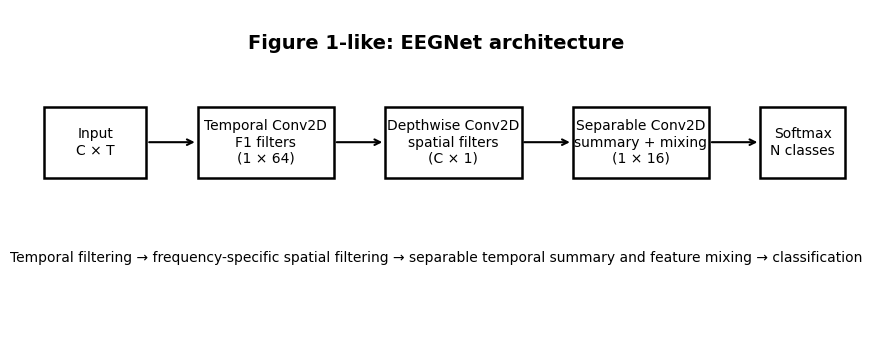

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure1_like_EEGNet_architecture.png
Table 2-like EEGNet architecture:


,Block,Layer,# filters,Size,Output,Activation/Options
0,1,Input,,,"(64, 128)",
1,1,Reshape / 4D input,,,"(1, 64, 128)",channels_last implementation
2,1,Conv2D,8,"(1, 64)","(8, 64, 128)","linear, same padding"
3,1,BatchNorm,,,"(8, 64, 128)",
4,1,DepthwiseConv2D,D×F1=16,"(64, 1)","(16, 1, 128)","linear, max norm=1"
5,1,BatchNorm + ELU + AvgPool + Dropout,,"pool (1,4)","(16, 1, 32)",p=0.5 within / 0.25 cross
6,2,SeparableConv2D,16,"(1, 16)","(16, 1, 32)","linear, same padding"
7,2,BatchNorm + ELU + AvgPool + Dropout,,"pool (1,8)","(16, 1, 4)",p=0.5 within / 0.25 cross
8,Classifier,Flatten + Dense,2,,"(2,)","Softmax, max norm=0.25"


Table 3-like model parameter counts:


Model,Dataset,Trial length (s),Channels,Samples,DeepConvNet,"EEGNet-4,2","EEGNet-8,2",ShallowConvNet
0,ERN,1.25,56,160,170277,1058,2242,91722
1,MRCP,1.50,64,192,176077,1138,2402,104922
2,P300,1.00,64,128,174477,1106,2338,104442
3,SMR,2.00,22,256,156229,836,1796,41004


saved: Figure1_like_EEGNet_architecture.png / Table2_like...csv / Table3_like...csv


In [15]:
# Cell 6C：Figure 1-like / Table 2-like / Table 3-like —— 架构图和参数量表


def plot_figure1_like():
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.axis("off")
    boxes = [
        (0.04, 0.48, 0.12, 0.22, "Input\nC × T"),
        (0.22, 0.48, 0.16, 0.22, "Temporal Conv2D\nF1 filters\n(1 × 64)"),
        (0.44, 0.48, 0.16, 0.22, "Depthwise Conv2D\nspatial filters\n(C × 1)"),
        (0.66, 0.48, 0.16, 0.22, "Separable Conv2D\nsummary + mixing\n(1 × 16)"),
        (0.88, 0.48, 0.10, 0.22, "Softmax\nN classes"),
    ]
    for x, y, w, h, text in boxes:
        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=1.8)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10)
    for i in range(len(boxes)-1):
        x, y, w, h, _ = boxes[i]
        x2, y2, w2, h2, _ = boxes[i+1]
        ax.annotate("", xy=(x2, y2+h2/2), xytext=(x+w, y+h/2), arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.text(0.5, 0.88, "Figure 1-like: EEGNet architecture", ha="center", fontsize=14, fontweight="bold")
    ax.text(0.5, 0.22, "Temporal filtering → frequency-specific spatial filtering → separable temporal summary and feature mixing → classification", ha="center", fontsize=10)
    out_path = OUTPUT_DIR / "Figure1_like_EEGNet_architecture.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)


def make_table2_like(ds_name=None, F1=8, D=2):
    if ds_name is None:
        ds_name = "P300" if "P300" in DATASETS else list(DATASETS.keys())[0]
    ds = DATASETS[ds_name]
    C = int(ds["X"].shape[1])
    T = int(ds["X"].shape[2])
    N = int(ds["nb_classes"])
    kern = 32 if ds_name == "SMR" else 64
    F2 = F1 * D
    rows = [
        {"Block": 1, "Layer": "Input", "# filters": "", "Size": "", "Output": f"({C}, {T})", "Activation/Options": ""},
        {"Block": 1, "Layer": "Reshape / 4D input", "# filters": "", "Size": "", "Output": f"(1, {C}, {T})", "Activation/Options": "channels_last implementation"},
        {"Block": 1, "Layer": "Conv2D", "# filters": F1, "Size": f"(1, {kern})", "Output": f"({F1}, {C}, {T})", "Activation/Options": "linear, same padding"},
        {"Block": 1, "Layer": "BatchNorm", "# filters": "", "Size": "", "Output": f"({F1}, {C}, {T})", "Activation/Options": ""},
        {"Block": 1, "Layer": "DepthwiseConv2D", "# filters": f"D×F1={D*F1}", "Size": f"({C}, 1)", "Output": f"({D*F1}, 1, {T})", "Activation/Options": "linear, max norm=1"},
        {"Block": 1, "Layer": "BatchNorm + ELU + AvgPool + Dropout", "# filters": "", "Size": "pool (1,4)", "Output": f"({D*F1}, 1, {T//4})", "Activation/Options": "p=0.5 within / 0.25 cross"},
        {"Block": 2, "Layer": "SeparableConv2D", "# filters": F2, "Size": "(1, 16)", "Output": f"({F2}, 1, {T//4})", "Activation/Options": "linear, same padding"},
        {"Block": 2, "Layer": "BatchNorm + ELU + AvgPool + Dropout", "# filters": "", "Size": "pool (1,8)", "Output": f"({F2}, 1, {T//32})", "Activation/Options": "p=0.5 within / 0.25 cross"},
        {"Block": "Classifier", "Layer": "Flatten + Dense", "# filters": N, "Size": "", "Output": f"({N},)", "Activation/Options": "Softmax, max norm=0.25"},
    ]
    df = pd.DataFrame(rows)
    df.to_csv(OUTPUT_DIR / f"Table2_like_EEGNet_architecture_{ds_name}.csv", index=False)
    return df


def make_table3_like():
    rows = []
    for ds_name, ds in DATASETS.items():
        for model_name in ["DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"]:
            try:
                K.clear_session()
                model = build_model(
                    model_name=model_name,
                    nb_classes=ds["nb_classes"],
                    chans=ds["X"].shape[1],
                    samples=ds["X"].shape[2],
                    fs=ds["sfreq"],
                    dataset_name=ds_name,
                    cv_type="within",
                )
                rows.append({
                    "Dataset": ds_name,
                    "Trial length (s)": round(ds["X"].shape[2] / ds["sfreq"], 3),
                    "Channels": ds["X"].shape[1],
                    "Samples": ds["X"].shape[2],
                    "Model": model_name,
                    "Trainable parameters": int(model.count_params()),
                })
            except Exception as e:
                rows.append({"Dataset": ds_name, "Model": model_name, "Trainable parameters": np.nan, "Error": repr(e)})
    df = pd.DataFrame(rows)
    wide = df.pivot_table(index=["Dataset", "Trial length (s)", "Channels", "Samples"], columns="Model", values="Trainable parameters", aggfunc="first").reset_index()
    df.to_csv(OUTPUT_DIR / "Table3_like_model_parameter_counts_long.csv", index=False)
    wide.to_csv(OUTPUT_DIR / "Table3_like_model_parameter_counts_wide.csv", index=False)
    return df, wide

plot_figure1_like()
table2_like_df = make_table2_like(ds_name="P300" if "P300" in DATASETS else None, F1=8, D=2)
print("Table 2-like EEGNet architecture:")
display(table2_like_df)
table3_long_df, table3_like_df = make_table3_like()
print("Table 3-like model parameter counts:")
display(table3_like_df)
print("saved: Figure1_like_EEGNet_architecture.png / Table2_like...csv / Table3_like...csv")


In [16]:
# Cell 7：训练一个 fold 的通用函数

def train_eval_generic(
    model_name,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    nb_classes,
    dataset_name,
    sfreq=128,
    metric_name="auc",
    cv_type="within",
    seed=42,
    epochs=50,
    batch_size=16,
    use_class_weight=False,
    verbose=0,
    run_id="run"
):
    K.clear_session()
    set_seed(seed)

    X_train, X_val, X_test = standardize_fold(X_train, X_val, X_test)

    chans = X_train.shape[1]
    samples = X_train.shape[2]

    model = build_model(
        model_name=model_name,
        nb_classes=nb_classes,
        chans=chans,
        samples=samples,
        fs=sfreq,
        dataset_name=dataset_name,
        cv_type=cv_type
    )

    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )

    Y_train = np_utils.to_categorical(y_train, nb_classes)
    Y_val = np_utils.to_categorical(y_val, nb_classes)

    safe_model_name = model_name.replace(",", "_").replace(" ", "_")
    ckpt_path = OUTPUT_DIR / f"{dataset_name}_{safe_model_name}_{cv_type}_{run_id}_best.weights.h5"

    checkpointer = ModelCheckpoint(
        filepath=str(ckpt_path),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )

    class_weights = make_class_weights(y_train) if use_class_weight else None

    if globals().get("PRINT_GPU_EACH_MODEL", False):
        gpu_status(f"开始 CNN 训练：{dataset_name} | {cv_type} | {model_name} | {run_id}")

    history = model.fit(
        as_4d(X_train), Y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=verbose,
        validation_data=(as_4d(X_val), Y_val),
        callbacks=[checkpointer],
        class_weight=class_weights
    )

    model.load_weights(str(ckpt_path))

    probs = model.predict(as_4d(X_test), verbose=0)
    preds = probs.argmax(axis=1)
    score = evaluate_metric(y_test, probs, metric_name)

    return {
        "dataset": dataset_name,
        "model_name": model_name,
        "cv_type": cv_type,
        "run_id": run_id,
        "metric": metric_name,
        "score": score,
        "preds": preds,
        "probs": probs,
        "true": y_test,
        "history": history,
        "model": model,
        "X_test": X_test,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val
    }

In [17]:
# Cell 8：传统 baseline
# P300 / ERN / MRCP：xDAWN + Riemannian Geometry
# SMR：简化 FBCSP baseline（MNE CSP + LogisticRegression）

def run_xdawn_rg_fold(X_train, y_train, X_test, y_test, metric_name="auc"):
    # pyriemann 输入：trials × channels × samples
    try:
        xdawn = XdawnCovariances(nfilter=5)
    except TypeError:
        xdawn = XdawnCovariances(5)

    clf = make_pipeline(
        xdawn,
        TangentSpace(metric="riemann"),
        LogisticRegression(max_iter=5000, solver="saga", penalty="elasticnet", l1_ratio=0.5)
    )

    X_train_z, _, X_test_z = standardize_fold(X_train, X_train, X_test)
    clf.fit(X_train_z, y_train)

    preds = clf.predict(X_test_z)
    if metric_name == "auc" and len(np.unique(y_test)) == 2:
        probs = clf.predict_proba(X_test_z)
        score = roc_auc_score(y_test, probs[:, 1]) if len(np.unique(y_test)) == 2 else accuracy_score(y_test, preds)
    else:
        probs = None
        score = accuracy_score(y_test, preds)

    return score, preds, probs

def run_fbcsp_fold(X_train, y_train, X_test, y_test, sfreq=128):
    # 简化版 FBCSP：9 个 4Hz 滤波器组，每个 band 拟合 CSP，再拼接特征。
    # 关键修复：MNE 的 filter_data 在部分版本中不接受 float32，必须转成 float64。
    # CNN 用 float32 没问题，但 FBCSP / CSP 这类传统方法建议用 float64。
    X_train = np.asarray(X_train, dtype=np.float64)
    X_test = np.asarray(X_test, dtype=np.float64)
    bands = [(f, f + 4) for f in range(4, 40, 4)]
    train_features = []
    test_features = []

    for l_freq, h_freq in bands:
        Xtr = mne.filter.filter_data(X_train.copy(), sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)
        Xte = mne.filter.filter_data(X_test.copy(), sfreq=sfreq, l_freq=l_freq, h_freq=h_freq, verbose=False)

        n_comp = min(4, Xtr.shape[1] - 1)
        csp = CSP(n_components=n_comp, reg="ledoit_wolf", log=True, norm_trace=False)
        train_features.append(csp.fit_transform(Xtr, y_train))
        test_features.append(csp.transform(Xte))

    Xtr_feat = np.concatenate(train_features, axis=1)
    Xte_feat = np.concatenate(test_features, axis=1)

    clf = LogisticRegression(
        max_iter=5000,
        solver="saga",
        penalty="elasticnet",
        l1_ratio=0.95,
        multi_class="ovr"
    )
    clf.fit(Xtr_feat, y_train)
    preds = clf.predict(Xte_feat)
    score = accuracy_score(y_test, preds)

    return score, preds, clf

In [18]:
# Cell 9：within-subject blockwise CV
# 原文：within-subject 采用 4-fold blockwise CV，2 blocks train, 1 val, 1 test。
# 这里如果某个 subject 的 block 不足 4，会自动用可用 block 数；如果只有 1 个 block，则跳过该 subject。

def _make_block_folds(block_ids, n_splits=4):
    block_ids = np.asarray(block_ids)
    if len(block_ids) < 2:
        return []
    n_splits = min(n_splits, len(block_ids))
    folds = np.array_split(block_ids, n_splits)
    return [np.asarray(f) for f in folds if len(f) > 0]

def run_within_subject_cv(ds, model_names, epochs=50, batch_size=16, seed=42, verbose=0):
    dataset_name = ds["name"]
    X_full = ds["X"]
    y_full = ds["y"]
    subjects = ds["subjects"]
    blocks = ds["blocks"]
    nb_classes = ds["nb_classes"]
    sfreq = ds["sfreq"]
    metric_name = ds["metric"]
    use_class_weight = ds["class_weight"]

    rows = []
    details = {}

    for subj in np.unique(subjects):
        subj_idx = subjects == subj
        X_subj = X_full[subj_idx]
        y_subj = y_full[subj_idx]
        b_subj = blocks[subj_idx]
        block_ids = np.unique(b_subj)

        fold_blocks = _make_block_folds(block_ids, n_splits=4)
        if len(fold_blocks) < 2:
            print(f"跳过 {dataset_name} Subject {subj}: block 数不足，block_ids={block_ids}")
            continue

        for fold_i in range(len(fold_blocks)):
            test_blocks = fold_blocks[fold_i]
            val_blocks = fold_blocks[(fold_i + 1) % len(fold_blocks)]
            train_blocks = np.concatenate([fold_blocks[j] for j in range(len(fold_blocks)) if j not in [fold_i, (fold_i+1) % len(fold_blocks)]])

            train_idx = np.isin(b_subj, train_blocks)
            val_idx = np.isin(b_subj, val_blocks)
            test_idx = np.isin(b_subj, test_blocks)

            X_train, y_train = X_subj[train_idx], y_subj[train_idx]
            X_val, y_val = X_subj[val_idx], y_subj[val_idx]
            X_test, y_test = X_subj[test_idx], y_subj[test_idx]

            if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
                continue
            if len(np.unique(y_train)) < nb_classes:
                print(f"跳过 {dataset_name} Subject {subj} Fold {fold_i+1}: train 类别不完整")
                continue

            print(f"\n[{dataset_name}] Subject {subj} Fold {fold_i+1}/{len(fold_blocks)}")
            print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

            # baseline
            if dataset_name in ["P300", "ERN", "MRCP"]:
                try:
                    score, preds, probs = run_xdawn_rg_fold(X_train, y_train, X_test, y_test, metric_name)
                    rows.append({"dataset": dataset_name, "subject": subj, "fold": fold_i+1, "model": "xDAWN+RG", "score": score})
                    details[(dataset_name, subj, fold_i+1, "xDAWN+RG")] = {"score": score, "preds": preds, "true": y_test, "probs": probs}
                    print(f"xDAWN+RG = {score:.4f}")
                except Exception as e:
                    print("xDAWN+RG 失败：", repr(e))

            if dataset_name == "SMR":
                try:
                    score, preds, clf = run_fbcsp_fold(X_train, y_train, X_test, y_test, sfreq=sfreq)
                    rows.append({"dataset": dataset_name, "subject": subj, "fold": fold_i+1, "model": "FBCSP", "score": score})
                    details[(dataset_name, subj, fold_i+1, "FBCSP")] = {"score": score, "preds": preds, "true": y_test, "clf": clf}
                    print(f"FBCSP = {score:.4f}")
                except Exception as e:
                    print("FBCSP 失败：", repr(e))

            # CNN models
            for model_name in model_names:
                try:
                    result = train_eval_generic(
                        model_name=model_name,
                        X_train=X_train, y_train=y_train,
                        X_val=X_val, y_val=y_val,
                        X_test=X_test, y_test=y_test,
                        nb_classes=nb_classes,
                        dataset_name=dataset_name,
                        sfreq=sfreq,
                        metric_name=metric_name,
                        cv_type="within",
                        seed=seed + fold_i,
                        epochs=epochs,
                        batch_size=batch_size,
                        use_class_weight=use_class_weight,
                        verbose=verbose,
                        run_id=f"subj{subj}_fold{fold_i+1}"
                    )
                    rows.append({"dataset": dataset_name, "subject": subj, "fold": fold_i+1, "model": model_name, "score": result["score"]})
                    details[(dataset_name, subj, fold_i+1, model_name)] = result
                    print(f"{model_name} = {result['score']:.4f}")
                except Exception as e:
                    print(f"{model_name} 失败：", repr(e))

    results_df = pd.DataFrame(rows)
    if len(results_df) == 0:
        return results_df, pd.DataFrame(), details

    summary_df = (
        results_df.groupby(["dataset", "model"])["score"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary_df["se"] = summary_df["std"] / np.sqrt(summary_df["count"])
    summary_df["2se"] = 2 * summary_df["se"]
    return results_df, summary_df, details

In [19]:
# Cell 10：cross-subject CV【小样本与全量均适用的修正版】
# 原文 P300/MRCP：随机 4 subjects 做 validation，1 subject 做 test，其余 train，重复 30 次。
# 但如果 P300/MRCP 只有 5 个 subject，不能硬套 4 validation；
# 本函数会自动降级为 3 train / 1 val / 1 test。
# 现在你新增到 10 个 subject 后，会自然变成 5 train / 4 val / 1 test，更接近论文设置。

def _make_cross_splits_paperlike(ds, n_folds=30, n_val_subjects=4, smr_repeats=10, seed=42):
    dataset_name = ds["name"]
    subject_ids = np.array(sorted(pd.unique(ds["subjects"])))
    rng = np.random.default_rng(seed)

    if len(subject_ids) < 3:
        return []

    splits = []

    if dataset_name == "SMR":
        # SMR 原文：9 subjects；每个 test subject 重复 10 次；
        # 其余 subjects 中 5 train + 3 val。
        for rep in range(int(smr_repeats)):
            for test_subj in subject_ids:
                remaining = np.array([s for s in subject_ids if s != test_subj])
                rng.shuffle(remaining)

                if len(remaining) >= 8:
                    train_subjects = remaining[:5]
                    val_subjects = remaining[5:8]
                else:
                    # subject 不够时，至少 1 val，其余尽量给 train
                    val_n = 1
                    val_subjects = remaining[:val_n]
                    train_subjects = remaining[val_n:]

                if len(train_subjects) == 0 or len(val_subjects) == 0:
                    continue
                splits.append((train_subjects, val_subjects, test_subj))

        return splits

    # P300 / MRCP / ERN：随机 test subject + validation subjects。
    # test_order 先覆盖所有 subject，再随机重复，避免小样本时 test 过于偏向某几个人。
    test_order = []
    while len(test_order) < int(n_folds):
        perm = list(rng.permutation(subject_ids))
        test_order.extend(perm)
    test_order = test_order[:int(n_folds)]

    for test_subj in test_order:
        remaining = np.array([s for s in subject_ids if s != test_subj])

        if len(subject_ids) <= 6:
            # 例如 5 个 subject：3 train + 1 val + 1 test
            effective_val = 1
        else:
            # subject 足够多时尽量接近论文：4 val + 1 test + 其余 train
            # 同时至少保留 2 个 train subject
            max_val = max(1, len(remaining) - 2)
            effective_val = min(int(n_val_subjects), max_val)

        val_subjects = rng.choice(remaining, size=effective_val, replace=False)
        train_subjects = np.array([s for s in remaining if s not in val_subjects])

        if len(train_subjects) == 0 or len(val_subjects) == 0:
            continue
        splits.append((train_subjects, val_subjects, test_subj))

    return splits

def inspect_cross_splits(name, n_show=8):
    """可选检查：看某数据集 cross-subject 到底是怎么分 train/val/test 的。"""
    ds = DATASETS[name]
    splits = _make_cross_splits_paperlike(
        ds,
        n_folds=CROSS_FOLDS,
        n_val_subjects=CROSS_VAL_SUBJECTS,
        smr_repeats=SMR_CROSS_REPEATS,
        seed=RANDOM_SEED
    )
    print(f"\n{name}: subject数={len(np.unique(ds['subjects']))}, splits={len(splits)}")
    for i, (train_subjects, val_subjects, test_subj) in enumerate(splits[:n_show], 1):
        print(f"Fold {i}: train={list(train_subjects)} | val={list(val_subjects)} | test={test_subj}")

def run_cross_subject_cv(ds, model_names, n_folds=30, n_val_subjects=4, epochs=50, batch_size=16, seed=42, verbose=0):
    dataset_name = ds["name"]
    X_full = ds["X"]
    y_full = ds["y"]
    subjects = ds["subjects"]
    nb_classes = ds["nb_classes"]
    sfreq = ds["sfreq"]
    metric_name = ds["metric"]
    use_class_weight = ds["class_weight"]

    subject_ids = np.array(sorted(pd.unique(subjects)))
    if len(subject_ids) < 3:
        print(f"{dataset_name}: subject 数只有 {len(subject_ids)}，少于 train/val/test 所需的 3 个，跳过 cross-subject。")
        empty_results = pd.DataFrame(columns=["dataset", "fold", "test_subject", "model", "score"])
        empty_summary = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
        return empty_results, empty_summary, {}

    smr_repeats = globals().get("SMR_CROSS_REPEATS", 1)
    splits = _make_cross_splits_paperlike(
        ds, n_folds=n_folds, n_val_subjects=n_val_subjects,
        smr_repeats=smr_repeats, seed=seed
    )
    if len(splits) == 0:
        print(f"{dataset_name}: 没有生成有效 cross-subject split。")
        empty_results = pd.DataFrame(columns=["dataset", "fold", "test_subject", "model", "score"])
        empty_summary = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
        return empty_results, empty_summary, {}

    print(f"{dataset_name}: subject数={len(subject_ids)}, cross splits={len(splits)}")

    rows = []
    details = {}

    for fold_i, (train_subjects, val_subjects, test_subj) in enumerate(splits, start=1):
        train_idx = np.isin(subjects, train_subjects)
        val_idx = np.isin(subjects, val_subjects)
        test_idx = subjects == test_subj

        X_train, y_train = X_full[train_idx], y_full[train_idx]
        X_val, y_val = X_full[val_idx], y_full[val_idx]
        X_test, y_test = X_full[test_idx], y_full[test_idx]

        if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
            continue
        if len(np.unique(y_train)) < nb_classes:
            print(f"跳过 {dataset_name} Cross Fold {fold_i}: train 类别不完整")
            continue

        print(f"\n[{dataset_name}] Cross Fold {fold_i}/{len(splits)}")
        print("Train subjects:", list(train_subjects), "| Val subjects:", list(val_subjects), "| Test subject:", test_subj)
        print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

        # baseline
        if dataset_name in ["P300", "ERN", "MRCP"]:
            try:
                score, preds, probs = run_xdawn_rg_fold(X_train, y_train, X_test, y_test, metric_name)
                rows.append({"dataset": dataset_name, "fold": fold_i, "test_subject": test_subj, "model": "xDAWN+RG", "score": score})
                details[(dataset_name, fold_i, "xDAWN+RG")] = {"score": score, "preds": preds, "true": y_test, "probs": probs}
                print(f"xDAWN+RG = {score:.4f}")
            except Exception as e:
                print("xDAWN+RG 失败：", repr(e))

        if dataset_name == "SMR":
            try:
                score, preds, clf = run_fbcsp_fold(X_train, y_train, X_test, y_test, sfreq=sfreq)
                rows.append({"dataset": dataset_name, "fold": fold_i, "test_subject": test_subj, "model": "FBCSP", "score": score})
                details[(dataset_name, fold_i, "FBCSP")] = {"score": score, "preds": preds, "true": y_test, "clf": clf}
                print(f"FBCSP = {score:.4f}")
            except Exception as e:
                print("FBCSP 失败：", repr(e))

        # CNN models
        for model_name in model_names:
            try:
                result = train_eval_generic(
                    model_name=model_name,
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test,
                    nb_classes=nb_classes,
                    dataset_name=dataset_name,
                    sfreq=sfreq,
                    metric_name=metric_name,
                    cv_type="cross",
                    seed=seed + fold_i,
                    epochs=epochs,
                    batch_size=batch_size,
                    use_class_weight=use_class_weight,
                    verbose=verbose,
                    run_id=f"cross_f{fold_i}"
                )
                score = result["score"]
                rows.append({"dataset": dataset_name, "fold": fold_i, "test_subject": test_subj, "model": model_name, "score": score})
                details[(dataset_name, fold_i, model_name)] = result
                print(f"{model_name} = {score:.4f}")
            except Exception as e:
                print(f"{model_name} 失败：", repr(e))

    results = pd.DataFrame(rows)
    summary = summarize_results(results)
    return results, summary, details


## v10：按数据集拆分 within / cross 运行

这一版把原来的 **Cell 11（within-subject CV）** 和 **Cell 12（cross-subject CV）** 拆成多个小 cell：

- 先跑原文数据更接近的：`ERN`、`SMR`
- 后跑你使用替代数据的：`MRCP`、`P300`

这样以后如果你只给替代数据集增加 subject，例如只增加 `P300` 或 `MRCP`，通常只需要重新运行对应数据集的 cell，再运行合并 cell 和画图 cell，不需要重跑前面的 ERN / SMR。

注意：如果你改了 `RUN_MODE`、`EPOCHS`、`MODEL_NAMES`、预处理函数、随机种子等全局设置，为了公平比较，建议四组数据都重新跑。


In [20]:
# Cell 11A：within-subject CV 辅助函数 —— 每个数据集单独运行、单独保存
# 运行顺序建议：ERN → SMR → MRCP → P300
# 如果以后只新增 P300/MRCP 数据，只需要重跑对应数据集 cell，再跑 Cell 11F 合并结果即可。

DATASET_RUN_ORDER = ["ERN", "SMR", "MRCP", "P300"]

within_results_by_dataset = globals().get("within_results_by_dataset", {})
within_summaries_by_dataset = globals().get("within_summaries_by_dataset", {})
within_details_all = globals().get("within_details_all", {})

def run_and_save_within_dataset(name):
    if name not in DATASETS:
        print(f"{name}: DATASETS 中没有这个数据集，跳过。请先运行 Cell 6。")
        empty_df = pd.DataFrame(columns=["dataset", "subject", "fold", "model", "score"])
        empty_summary = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
        return empty_df, empty_summary, {}

    print(f"\n========== Cell 11 - within-subject: {name} ==========")
    gpu_status(f"Cell 11 within-subject 开始：{name}")
    ds = DATASETS[name]

    df, summary, details = run_within_subject_cv(
        ds=ds,
        model_names=MODEL_NAMES,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=RANDOM_SEED,
        verbose=0
    )

    result_path = OUTPUT_DIR / f"within_subject_results_{name}.csv"
    summary_path = OUTPUT_DIR / f"within_subject_summary_{name}.csv"

    if isinstance(df, pd.DataFrame) and len(df) > 0:
        df.to_csv(result_path, index=False)
        print("saved:", result_path)
    else:
        df = pd.DataFrame(columns=["dataset", "subject", "fold", "model", "score"])
        print(f"{name}: 没有生成 within-subject 明细结果。")

    if isinstance(summary, pd.DataFrame) and len(summary) > 0:
        summary.to_csv(summary_path, index=False)
        print("saved:", summary_path)
    else:
        summary = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
        print(f"{name}: 没有生成 within-subject summary。")

    within_results_by_dataset[name] = df
    within_summaries_by_dataset[name] = summary
    within_details_all[name] = details

    return df, summary, details


In [21]:
# Cell 11B：within-subject CV - ERN（建议先跑，接近原文数据）
within_ern_df, within_ern_summary, within_ern_details = run_and_save_within_dataset("ERN")
within_ern_summary



========== Cell 11 - within-subject: ERN ==========

GPU CHECK | Cell 11 within-subject 开始：ERN
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100


[ERN] Subject 2 Fold 1/4
Train/Val/Test: (160, 56, 160) (60, 56, 160) (120, 56, 160)
xDAWN+RG = 0.8220
DeepConvNet = 0.5994
ShallowConvNet = 0.5651
EEGNet-4,2 = 0.5731
EEGNet-8,2 = 0.6141

[ERN] Subject 2 Fold 2/4
Train/Val/Test: (220, 56, 160) (60, 56, 160) (60, 56, 160)
xDAWN+RG = 0.9236
DeepConvNet = 0.7975
ShallowConvNet = 0.6875
EEGNet-4,2 = 0.6991
EEGNet-8,2 = 0.7870

[ERN] Subject 2 Fold 3/4
Train/Val/Test: (180, 56, 160) (100, 56, 160) (60, 56, 160)
xDAWN+RG = 0.9006
DeepConvNet = 0.7851
ShallowConvNet = 0.7851
EEGNet-4,2 = 0.7863
EEGNet-8,2 = 0.7531

[ERN] Subject 2 Fold 4/4
Train/Val/Test: (120, 56, 160) (120, 56, 160) (100, 56, 160)
xDAWN+RG = 0.8397
DeepConvNet = 0.6778
ShallowConvNet = 0.5369
EEGNet-4,2 = 0.7102
EEGNet-8,2 = 0.7078

[E

,dataset,model,mean,std,count,se,2se
0,ERN,DeepConvNet,0.674065,0.128142,36,0.021357,0.042714
1,ERN,"EEGNet-4,2",0.613674,0.156000,36,0.026000,0.052000
2,ERN,"EEGNet-8,2",0.653481,0.141910,36,0.023652,0.047303
3,ERN,ShallowConvNet,0.635549,0.133621,36,0.022270,0.044540
4,ERN,xDAWN+RG,0.801217,0.123905,36,0.020651,0.041302


In [22]:
# Cell 11C：within-subject CV - SMR（建议第二个跑，接近原文数据）
within_smr_df, within_smr_summary, within_smr_details = run_and_save_within_dataset("SMR")
within_smr_summary



========== Cell 11 - within-subject: SMR ==========

GPU CHECK | Cell 11 within-subject 开始：SMR
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100


[SMR] Subject 1 Fold 1/4
Train/Val/Test: (144, 22, 256) (72, 22, 256) (72, 22, 256)
Computing rank from data with rank=None
    Using tolerance 1.5e-05 (2.2e-16 eps * 22 dim * 3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.5e-05 (2.2e-16 eps * 22 dim * 3.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 pr

,dataset,model,mean,std,count,se,2se
0,SMR,DeepConvNet,0.277006,0.037701,36,0.006283,0.012567
1,SMR,"EEGNet-4,2",0.255401,0.050491,36,0.008415,0.016830
2,SMR,"EEGNet-8,2",0.254630,0.034663,36,0.005777,0.011554
3,SMR,FBCSP,0.706404,0.170303,36,0.028384,0.056768
4,SMR,ShallowConvNet,0.276235,0.056420,36,0.009403,0.018807


In [23]:
# Cell 11D：within-subject CV - MRCP（替代数据，放后面）
within_mrcp_df, within_mrcp_summary, within_mrcp_details = run_and_save_within_dataset("MRCP")
within_mrcp_summary



========== Cell 11 - within-subject: MRCP ==========

GPU CHECK | Cell 11 within-subject 开始：MRCP
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100


[MRCP] Subject 1 Fold 1/3
Train/Val/Test: (15, 64, 192) (15, 64, 192) (15, 64, 192)
xDAWN+RG = 0.6786
DeepConvNet = 0.9286
ShallowConvNet = 0.7143
EEGNet-4,2 = 0.2679
EEGNet-8,2 = 0.5893

[MRCP] Subject 1 Fold 2/3
Train/Val/Test: (15, 64, 192) (15, 64, 192) (15, 64, 192)
xDAWN+RG = 0.7857
DeepConvNet = 0.6786
ShallowConvNet = 0.7143
EEGNet-4,2 = 0.7321
EEGNet-8,2 = 0.5536

[MRCP] Subject 1 Fold 3/3
Train/Val/Test: (15, 64, 192) (15, 64, 192) (15, 64, 192)
xDAWN+RG = 0.9643
DeepConvNet = 0.7143
ShallowConvNet = 0.8571
EEGNet-4,2 = 0.1786
EEGNet-8,2 = 0.8036

[MRCP] Subject 2 Fold 1/3
Train/Val/Test: (15, 64, 192) (15, 64, 192) (15, 64, 192)
xDAWN+RG = 0.5714
DeepConvNet = 0.8393
ShallowConvNet = 0.3393
EEGNet-4,2 = 0.5893
EEGNet-8,2 = 0.6250

[MRC

,dataset,model,mean,std,count,se,2se
0,MRCP,DeepConvNet,0.651786,0.212779,30,0.038848,0.077696
1,MRCP,"EEGNet-4,2",0.523214,0.212490,30,0.038795,0.077590
2,MRCP,"EEGNet-8,2",0.572619,0.198458,30,0.036233,0.072466
3,MRCP,ShallowConvNet,0.606548,0.157045,30,0.028672,0.057345
4,MRCP,xDAWN+RG,0.719048,0.169468,30,0.030941,0.061881


In [24]:
# Cell 11E：within-subject CV - P300（替代数据，放最后）
within_p300_df, within_p300_summary, within_p300_details = run_and_save_within_dataset("P300")
within_p300_summary



========== Cell 11 - within-subject: P300 ==========

GPU CHECK | Cell 11 within-subject 开始：P300
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100


[P300] Subject 1 Fold 1/4
Train/Val/Test: (240, 64, 128) (120, 64, 128) (360, 64, 128)
xDAWN+RG = 0.7659
DeepConvNet = 0.7147
ShallowConvNet = 0.6351
EEGNet-4,2 = 0.6595
EEGNet-8,2 = 0.6675

[P300] Subject 1 Fold 2/4
Train/Val/Test: (480, 64, 128) (120, 64, 128) (120, 64, 128)
xDAWN+RG = 0.8830
DeepConvNet = 0.8090
ShallowConvNet = 0.6720
EEGNet-4,2 = 0.7440
EEGNet-8,2 = 0.7950

[P300] Subject 1 Fold 3/4
Train/Val/Test: (480, 64, 128) (120, 64, 128) (120, 64, 128)
xDAWN+RG = 0.8490
DeepConvNet = 0.7105
ShallowConvNet = 0.6445
EEGNet-4,2 = 0.5965
EEGNet-8,2 = 0.6900

[P300] Subject 1 Fold 4/4
Train/Val/Test: (240, 64, 128) (360, 64, 128) (120, 64, 128)
xDAWN+RG = 0.8170
DeepConvNet = 0.5695
ShallowConvNet = 0.5860
EEGNet-4,2 = 0.6200
EEGNet-8,2 = 

,dataset,model,mean,std,count,se,2se
0,P300,DeepConvNet,0.654202,0.089876,40,0.014211,0.028421
1,P300,"EEGNet-4,2",0.589479,0.097172,40,0.015364,0.030729
2,P300,"EEGNet-8,2",0.624384,0.101403,40,0.016033,0.032067
3,P300,ShallowConvNet,0.582077,0.064357,40,0.010176,0.020351
4,P300,xDAWN+RG,0.772217,0.100720,40,0.015925,0.031850


In [25]:
# Cell 11F：合并四组 within-subject 结果
# 这个 cell 会优先使用当前内存中的结果；如果某组没在本次会话中运行，会尝试从 OUTPUT_DIR 读取之前保存的 csv。
# 以后如果你只重跑了 P300/MRCP，跑完对应 cell 后，再跑本 cell 即可合并新旧结果。

def _load_dataset_result(kind, name, in_memory_dict):
    if name in in_memory_dict and isinstance(in_memory_dict[name], pd.DataFrame) and len(in_memory_dict[name]) > 0:
        return in_memory_dict[name]

    path = OUTPUT_DIR / f"{kind}_{name}.csv"
    if path.exists():
        print(f"读取已有结果: {path.name}")
        return pd.read_csv(path)

    print(f"未找到 {name} 的 {kind}，跳过。")
    return pd.DataFrame()

within_result_frames = []
within_summary_frames = []

for name in DATASET_RUN_ORDER:
    within_result_frames.append(_load_dataset_result("within_subject_results", name, within_results_by_dataset))
    within_summary_frames.append(_load_dataset_result("within_subject_summary", name, within_summaries_by_dataset))

valid_within_results = [d for d in within_result_frames if isinstance(d, pd.DataFrame) and len(d) > 0]
valid_within_summaries = [d for d in within_summary_frames if isinstance(d, pd.DataFrame) and len(d) > 0]

if len(valid_within_results) > 0:
    within_df = pd.concat(valid_within_results, ignore_index=True)
else:
    within_df = pd.DataFrame(columns=["dataset", "subject", "fold", "model", "score"])
    print("没有可合并的 within-subject 结果。")

if len(valid_within_summaries) > 0:
    within_summary_df = pd.concat(valid_within_summaries, ignore_index=True)
else:
    within_summary_df = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
    print("没有可合并的 within-subject summary。")

within_df.to_csv(OUTPUT_DIR / "within_subject_results.csv", index=False)
within_summary_df.to_csv(OUTPUT_DIR / "within_subject_summary.csv", index=False)

print("\n========== within-subject summary ==========")
display(within_summary_df)
within_summary_df



========== within-subject summary ==========


,dataset,model,mean,std,count,se,2se
0,ERN,DeepConvNet,0.674065,0.128142,36,0.021357,0.042714
1,ERN,"EEGNet-4,2",0.613674,0.156000,36,0.026000,0.052000
2,ERN,"EEGNet-8,2",0.653481,0.141910,36,0.023652,0.047303
3,ERN,ShallowConvNet,0.635549,0.133621,36,0.022270,0.044540
4,ERN,xDAWN+RG,0.801217,0.123905,36,0.020651,0.041302
5,SMR,DeepConvNet,0.277006,0.037701,36,0.006283,0.012567
6,SMR,"EEGNet-4,2",0.255401,0.050491,36,0.008415,0.016830
7,SMR,"EEGNet-8,2",0.254630,0.034663,36,0.005777,0.011554
8,SMR,FBCSP,0.706404,0.170303,36,0.028384,0.056768
9,SMR,ShallowConvNet,0.276235,0.056420,36,0.009403,0.018807


,dataset,model,mean,std,count,se,2se
0,ERN,DeepConvNet,0.674065,0.128142,36,0.021357,0.042714
1,ERN,"EEGNet-4,2",0.613674,0.156000,36,0.026000,0.052000
2,ERN,"EEGNet-8,2",0.653481,0.141910,36,0.023652,0.047303
3,ERN,ShallowConvNet,0.635549,0.133621,36,0.022270,0.044540
4,ERN,xDAWN+RG,0.801217,0.123905,36,0.020651,0.041302
5,SMR,DeepConvNet,0.277006,0.037701,36,0.006283,0.012567
6,SMR,"EEGNet-4,2",0.255401,0.050491,36,0.008415,0.016830
7,SMR,"EEGNet-8,2",0.254630,0.034663,36,0.005777,0.011554
8,SMR,FBCSP,0.706404,0.170303,36,0.028384,0.056768
9,SMR,ShallowConvNet,0.276235,0.056420,36,0.009403,0.018807


In [26]:
# Cell 12A：cross-subject CV 辅助函数 —— 每个数据集单独运行、单独保存
# 运行顺序建议：ERN → SMR → MRCP → P300
# 如果以后只新增 P300/MRCP 数据，只需要重跑对应数据集 cell，再跑 Cell 12F 合并结果即可。

cross_results_by_dataset = globals().get("cross_results_by_dataset", {})
cross_summaries_by_dataset = globals().get("cross_summaries_by_dataset", {})
cross_details_all = globals().get("cross_details_all", {})

def run_and_save_cross_dataset(name):
    if name not in DATASETS:
        print(f"{name}: DATASETS 中没有这个数据集，跳过。请先运行 Cell 6。")
        empty_df = pd.DataFrame(columns=["dataset", "fold", "test_subject", "model", "score"])
        empty_summary = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
        return empty_df, empty_summary, {}

    print(f"\n========== Cell 12 - cross-subject: {name} ==========")
    gpu_status(f"Cell 12 cross-subject 开始：{name}")
    ds = DATASETS[name]

    df, summary, details = run_cross_subject_cv(
        ds=ds,
        model_names=MODEL_NAMES,
        n_folds=CROSS_FOLDS,
        n_val_subjects=CROSS_VAL_SUBJECTS,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=RANDOM_SEED,
        verbose=0
    )

    result_path = OUTPUT_DIR / f"cross_subject_results_{name}.csv"
    summary_path = OUTPUT_DIR / f"cross_subject_summary_{name}.csv"

    if isinstance(df, pd.DataFrame) and len(df) > 0:
        df.to_csv(result_path, index=False)
        print("saved:", result_path)
    else:
        df = pd.DataFrame(columns=["dataset", "fold", "test_subject", "model", "score"])
        print(f"{name}: 没有生成 cross-subject 明细结果。")

    if isinstance(summary, pd.DataFrame) and len(summary) > 0:
        summary.to_csv(summary_path, index=False)
        print("saved:", summary_path)
    else:
        summary = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
        print(f"{name}: 没有生成 cross-subject summary。")

    cross_results_by_dataset[name] = df
    cross_summaries_by_dataset[name] = summary
    cross_details_all[name] = details

    return df, summary, details


In [27]:
# 修复缺失函数：汇总每个模型的 mean / std / 2SE
def summarize_results(results):
    """
    输入:
        results: DataFrame，至少包含 columns:
                 dataset, model, score

    输出:
        summary: 每个 dataset × model 的平均分、标准差、样本数、SE、2SE
    """
    if results is None or len(results) == 0:
        return pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])

    required_cols = {"dataset", "model", "score"}
    missing = required_cols - set(results.columns)
    if missing:
        raise ValueError(f"results 缺少必要列: {missing}")

    summary = (
        results
        .groupby(["dataset", "model"], as_index=False)["score"]
        .agg(mean="mean", std="std", count="count")
    )

    # 如果只有 1 个结果，std 会是 NaN，这里改成 0，避免后面画图报错
    summary["std"] = summary["std"].fillna(0.0)
    summary["se"] = summary["std"] / np.sqrt(summary["count"].clip(lower=1))
    summary["2se"] = 2 * summary["se"]

    # 按论文模型顺序排序，如果 PAPER_MODEL_ORDER 存在就用它
    if "PAPER_MODEL_ORDER" in globals():
        model_order = {m: i for i, m in enumerate(PAPER_MODEL_ORDER)}
        summary["_model_order"] = summary["model"].map(model_order).fillna(999)
        summary = summary.sort_values(["dataset", "_model_order", "model"]).drop(columns=["_model_order"])
    else:
        summary = summary.sort_values(["dataset", "model"])

    return summary.reset_index(drop=True)

print("✅ summarize_results 已定义，可以重新运行 Cell 12B / 12C / 12D / 12E")

✅ summarize_results 已定义，可以重新运行 Cell 12B / 12C / 12D / 12E


In [28]:
# Cell 12B：cross-subject CV - ERN（建议先跑，接近原文数据）
cross_ern_df, cross_ern_summary, cross_ern_details = run_and_save_cross_dataset("ERN")
cross_ern_summary



========== Cell 12 - cross-subject: ERN ==========

GPU CHECK | Cell 12 cross-subject 开始：ERN
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100

ERN: subject数=9, cross splits=3

[ERN] Cross Fold 1/3
Train subjects: [np.int64(2), np.int64(7), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17)] | Val subjects: [np.int64(6)] | Test subject: 11
Train/Val/Test: (2380, 56, 160) (340, 56, 160) (340, 56, 160)
xDAWN+RG = 0.5975
DeepConvNet = 0.7542
ShallowConvNet = 0.6000
EEGNet-4,2 = 0.7306
EEGNet-8,2 = 0.7297

[ERN] Cross Fold 2/3
Train subjects: [np.int64(7), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17)] | Val subjects: [np.int64(6)] | Test subject: 2
Train/Val/Test: (2380, 56, 160) (340, 56, 160) (340, 56, 160)
xDAWN+RG = 0.7150
DeepConvNet = 0.5458
ShallowConvNet = 0.5603
EEGNet-4,2 = 0.6931
EEGNet-8,2 = 0.6836

[ERN] Cross Fold 3/3
Train sub

,dataset,model,mean,std,count,se,2se
0,ERN,DeepConvNet,0.630047,0.109814,3,0.063401,0.126802
1,ERN,"EEGNet-4,2",0.693039,0.037545,3,0.021676,0.043353
2,ERN,"EEGNet-8,2",0.690835,0.035749,3,0.020640,0.041280
3,ERN,ShallowConvNet,0.595360,0.032945,3,0.019021,0.038042
4,ERN,xDAWN+RG,0.657685,0.058809,3,0.033953,0.067907


In [29]:
# Cell 12C：cross-subject CV - SMR（建议第二个跑，接近原文数据）
cross_smr_df, cross_smr_summary, cross_smr_details = run_and_save_cross_dataset("SMR")
cross_smr_summary



========== Cell 12 - cross-subject: SMR ==========

GPU CHECK | Cell 12 cross-subject 开始：SMR
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100

SMR: subject数=9, cross splits=9

[SMR] Cross Fold 1/9
Train subjects: [np.int64(5), np.int64(6), np.int64(4), np.int64(9), np.int64(8)] | Val subjects: [np.int64(3), np.int64(7), np.int64(2)] | Test subject: 1
Train/Val/Test: (1440, 22, 256) (864, 22, 256) (288, 22, 256)
Computing rank from data with rank=None
    Using tolerance 6e-05 (2.2e-16 eps * 22 dim * 1.2e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Computing rank from data

,dataset,model,mean,std,count,se,2se
0,SMR,DeepConvNet,0.265818,0.023875,9,0.007958,0.015916
1,SMR,"EEGNet-4,2",0.278549,0.025855,9,0.008618,0.017236
2,SMR,"EEGNet-8,2",0.319059,0.065593,9,0.021864,0.043729
3,SMR,FBCSP,0.375000,0.091059,9,0.030353,0.060706
4,SMR,ShallowConvNet,0.304784,0.050221,9,0.016740,0.033480


In [30]:
# Cell 12D：cross-subject CV - MRCP（替代数据，放后面）
cross_mrcp_df, cross_mrcp_summary, cross_mrcp_details = run_and_save_cross_dataset("MRCP")
cross_mrcp_summary



========== Cell 12 - cross-subject: MRCP ==========

GPU CHECK | Cell 12 cross-subject 开始：MRCP
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100

MRCP: subject数=10, cross splits=3

[MRCP] Cross Fold 1/3
Train subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(9), np.int64(10)] | Val subjects: [np.int64(8)] | Test subject: 6
Train/Val/Test: (360, 64, 192) (45, 64, 192) (45, 64, 192)
xDAWN+RG = 0.9427
DeepConvNet = 0.9704
ShallowConvNet = 0.6798
EEGNet-4,2 = 0.9565
EEGNet-8,2 = 0.9723

[MRCP] Cross Fold 2/3
Train subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10)] | Val subjects: [np.int64(8)] | Test subject: 7
Train/Val/Test: (360, 64, 192) (45, 64, 192) (45, 64, 192)
xDAWN+RG = 0.9684
DeepConvNet = 0.9822
ShallowConvNet = 0.6126
EEGNet-4,2 = 0.9802
EEGNet-8,2 = 0.9960

[MRCP] Cross F

,dataset,model,mean,std,count,se,2se
0,MRCP,DeepConvNet,0.974308,0.006846,3,0.003953,0.007905
1,MRCP,"EEGNet-4,2",0.942029,0.047156,3,0.027225,0.054451
2,MRCP,"EEGNet-8,2",0.969697,0.027762,3,0.016028,0.032057
3,MRCP,ShallowConvNet,0.710145,0.115665,3,0.066779,0.133558
4,MRCP,xDAWN+RG,0.944664,0.022792,3,0.013159,0.026318


In [31]:
# Cell 12E：cross-subject CV - P300（替代数据，放最后）
cross_p300_df, cross_p300_summary, cross_p300_details = run_and_save_cross_dataset("P300")
cross_p300_summary



========== Cell 12 - cross-subject: P300 ==========

GPU CHECK | Cell 12 cross-subject 开始：P300
TensorFlow: 2.21.0
tf GPUs: []
❌ TensorFlow 未识别 GPU，CNN 会用 CPU，训练会明显变慢。
nvidia-smi: NVIDIA RTX PRO 6000 Blackwell Server Edition, 3, 97887, 100

P300: subject数=10, cross splits=3

[P300] Cross Fold 1/3
Train subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(9), np.int64(10)] | Val subjects: [np.int64(8)] | Test subject: 6
Train/Val/Test: (4863, 64, 128) (533, 64, 128) (533, 64, 128)
xDAWN+RG = 0.8343
DeepConvNet = 0.8443
ShallowConvNet = 0.6244
EEGNet-4,2 = 0.7536
EEGNet-8,2 = 0.7907

[P300] Cross Fold 2/3
Train subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10)] | Val subjects: [np.int64(8)] | Test subject: 7
Train/Val/Test: (4863, 64, 128) (533, 64, 128) (533, 64, 128)
xDAWN+RG = 0.6921
DeepConvNet = 0.7116
ShallowConvNet = 0.5616
EEGNet-4,2 = 0.6448
EEGNet-8,2 = 0.6972

[P300] C

,dataset,model,mean,std,count,se,2se
0,P300,DeepConvNet,0.766350,0.069362,3,0.040046,0.080092
1,P300,"EEGNet-4,2",0.709715,0.057387,3,0.033133,0.066265
2,P300,"EEGNet-8,2",0.748896,0.047505,3,0.027427,0.054854
3,P300,ShallowConvNet,0.616859,0.051895,3,0.029962,0.059923
4,P300,xDAWN+RG,0.761273,0.071178,3,0.041095,0.082190


In [32]:
# Cell 12F：合并四组 cross-subject 结果
# 这个 cell 会优先使用当前内存中的结果；如果某组没在本次会话中运行，会尝试从 OUTPUT_DIR 读取之前保存的 csv。
# 以后如果你只重跑了 P300/MRCP，跑完对应 cell 后，再跑本 cell 即可合并新旧结果。

cross_result_frames = []
cross_summary_frames = []

for name in DATASET_RUN_ORDER:
    cross_result_frames.append(_load_dataset_result("cross_subject_results", name, cross_results_by_dataset))
    cross_summary_frames.append(_load_dataset_result("cross_subject_summary", name, cross_summaries_by_dataset))

valid_cross_results = [d for d in cross_result_frames if isinstance(d, pd.DataFrame) and len(d) > 0]
valid_cross_summaries = [d for d in cross_summary_frames if isinstance(d, pd.DataFrame) and len(d) > 0]

if len(valid_cross_results) > 0:
    cross_df = pd.concat(valid_cross_results, ignore_index=True)
else:
    cross_df = pd.DataFrame(columns=["dataset", "fold", "test_subject", "model", "score"])
    print("没有可合并的 cross-subject 结果。")

if len(valid_cross_summaries) > 0:
    cross_summary_df = pd.concat(valid_cross_summaries, ignore_index=True)
else:
    cross_summary_df = pd.DataFrame(columns=["dataset", "model", "mean", "std", "count", "se", "2se"])
    print("没有可合并的 cross-subject summary。")

cross_df.to_csv(OUTPUT_DIR / "cross_subject_results.csv", index=False)
cross_summary_df.to_csv(OUTPUT_DIR / "cross_subject_summary.csv", index=False)

print("\n========== cross-subject summary ==========")
display(cross_summary_df)
cross_summary_df



========== cross-subject summary ==========


,dataset,model,mean,std,count,se,2se
0,ERN,DeepConvNet,0.630047,0.109814,3,0.063401,0.126802
1,ERN,"EEGNet-4,2",0.693039,0.037545,3,0.021676,0.043353
2,ERN,"EEGNet-8,2",0.690835,0.035749,3,0.020640,0.041280
3,ERN,ShallowConvNet,0.595360,0.032945,3,0.019021,0.038042
4,ERN,xDAWN+RG,0.657685,0.058809,3,0.033953,0.067907
5,SMR,DeepConvNet,0.265818,0.023875,9,0.007958,0.015916
6,SMR,"EEGNet-4,2",0.278549,0.025855,9,0.008618,0.017236
7,SMR,"EEGNet-8,2",0.319059,0.065593,9,0.021864,0.043729
8,SMR,FBCSP,0.375000,0.091059,9,0.030353,0.060706
9,SMR,ShallowConvNet,0.304784,0.050221,9,0.016740,0.033480


,dataset,model,mean,std,count,se,2se
0,ERN,DeepConvNet,0.630047,0.109814,3,0.063401,0.126802
1,ERN,"EEGNet-4,2",0.693039,0.037545,3,0.021676,0.043353
2,ERN,"EEGNet-8,2",0.690835,0.035749,3,0.020640,0.041280
3,ERN,ShallowConvNet,0.595360,0.032945,3,0.019021,0.038042
4,ERN,xDAWN+RG,0.657685,0.058809,3,0.033953,0.067907
5,SMR,DeepConvNet,0.265818,0.023875,9,0.007958,0.015916
6,SMR,"EEGNet-4,2",0.278549,0.025855,9,0.008618,0.017236
7,SMR,"EEGNet-8,2",0.319059,0.065593,9,0.021864,0.043729
8,SMR,FBCSP,0.375000,0.091059,9,0.030353,0.060706
9,SMR,ShallowConvNet,0.304784,0.050221,9,0.016740,0.033480


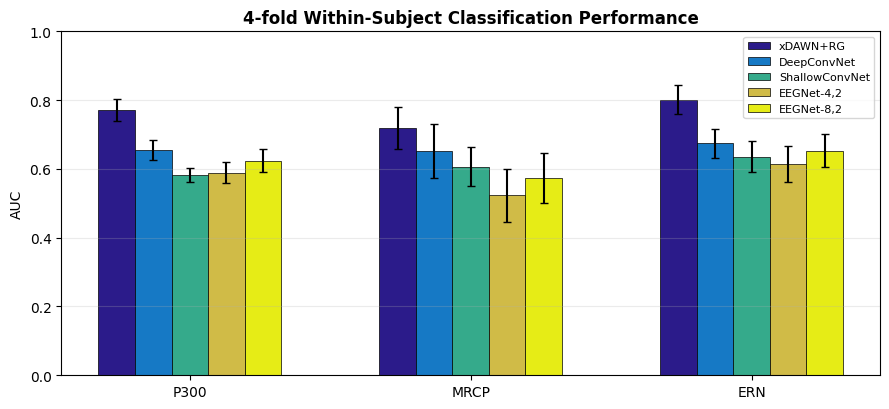

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure2_within_subject_P300_MRCP_ERN.png


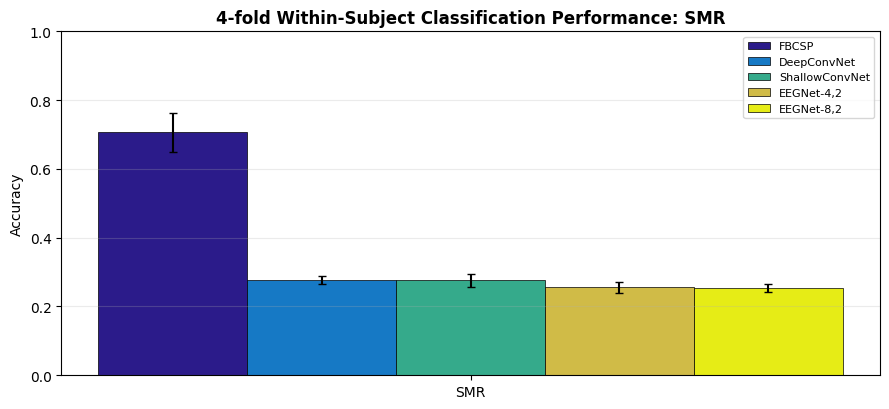

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure3_within_subject_SMR.png


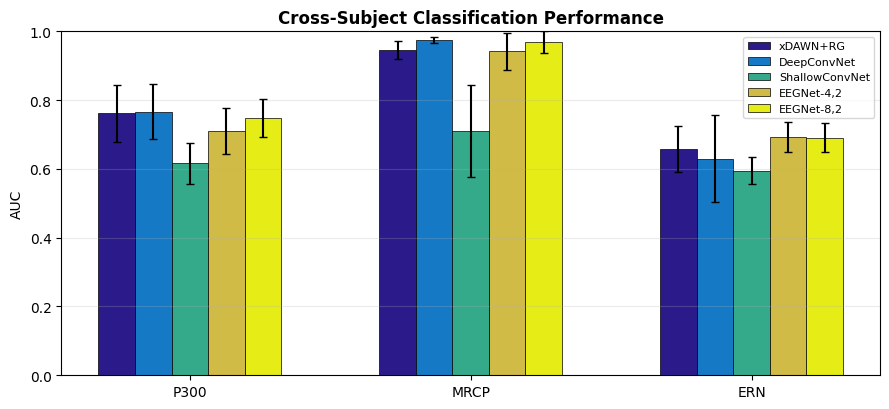

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure4_cross_subject_P300_MRCP_ERN.png


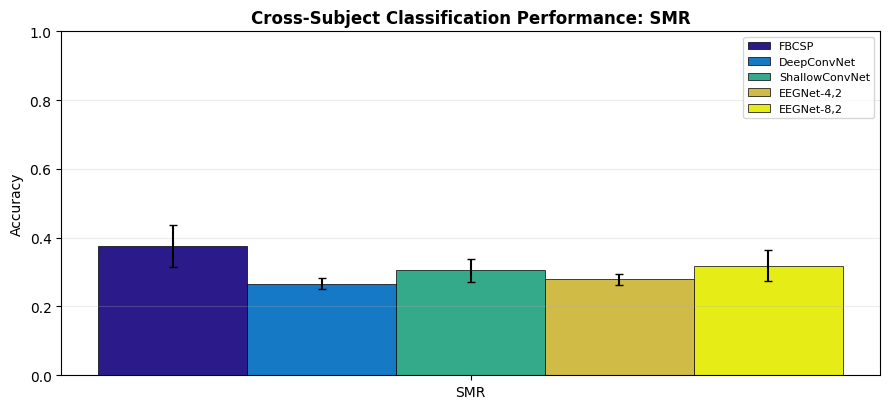

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure5_cross_subject_SMR.png


In [33]:
# Cell 13：画 Figure 2-5 风格柱状图【修正版】
# 关键修改：Figure 5 加回 FBCSP；并在缺少某个模型时不报错。

PAPER_MODEL_ORDER = ["xDAWN+RG", "FBCSP", "DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"]
PAPER_COLORS = {
    "xDAWN+RG": "#2b1b8a",
    "FBCSP": "#2b1b8a",
    "DeepConvNet": "#1679c5",
    "ShallowConvNet": "#35aa8b",
    "EEGNet-4,2": "#d0bb47",
    "EEGNet-8,2": "#e6ec16",
}

def plot_grouped_bar(summary_df, datasets, models, ylabel, title, out_name):
    if summary_df is None or len(summary_df) == 0:
        print(f"{out_name}: summary_df 为空，无法画图")
        return

    plot_df = summary_df[summary_df["dataset"].isin(datasets)].copy()
    if len(plot_df) == 0:
        print(f"{out_name}: 没有可画数据")
        return

    x = np.arange(len(datasets))
    width = 0.13 if len(models) >= 5 else 0.18

    plt.figure(figsize=(9, 4.2))
    for i, model in enumerate(models):
        sub = plot_df[plot_df["model"] == model].set_index("dataset")
        means = [sub.loc[d, "mean"] if d in sub.index else np.nan for d in datasets]
        errs = [sub.loc[d, "2se"] if d in sub.index else 0 for d in datasets]
        if np.all(pd.isna(means)):
            continue
        offset = (i - (len(models)-1)/2) * width
        plt.bar(
            x + offset, means, width,
            yerr=errs, capsize=3,
            label=model,
            color=PAPER_COLORS.get(model, None),
            edgecolor="black",
            linewidth=0.5
        )

    plt.xticks(x, datasets)
    plt.ylim(0, 1)
    plt.ylabel(ylabel)
    plt.title(title, fontweight="bold")
    plt.legend(fontsize=8, loc="upper right", frameon=True)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    out_path = OUTPUT_DIR / out_name
    plt.savefig(out_path, dpi=300)
    plt.show()
    print("saved:", out_path)

plot_grouped_bar(
    within_summary_df,
    datasets=["P300", "MRCP", "ERN"],
    models=["xDAWN+RG", "DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"],
    ylabel="AUC",
    title="4-fold Within-Subject Classification Performance",
    out_name="Figure2_within_subject_P300_MRCP_ERN.png"
)

plot_grouped_bar(
    within_summary_df,
    datasets=["SMR"],
    models=["FBCSP", "DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"],
    ylabel="Accuracy",
    title="4-fold Within-Subject Classification Performance: SMR",
    out_name="Figure3_within_subject_SMR.png"
)

plot_grouped_bar(
    cross_summary_df,
    datasets=["P300", "MRCP", "ERN"],
    models=["xDAWN+RG", "DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"],
    ylabel="AUC",
    title="Cross-Subject Classification Performance",
    out_name="Figure4_cross_subject_P300_MRCP_ERN.png"
)

plot_grouped_bar(
    cross_summary_df,
    datasets=["SMR"],
    models=["FBCSP", "DeepConvNet", "ShallowConvNet", "EEGNet-4,2", "EEGNet-8,2"],
    ylabel="Accuracy",
    title="Cross-Subject Classification Performance: SMR",
    out_name="Figure5_cross_subject_SMR.png"
)


In [34]:
# Cell 13B：Figure 2–5 统计检验表 —— 更接近原文的显著性报告
# 原文 within-subject 使用 repeated-measures ANOVA；这里在实际项目代码中用更稳妥的自动逻辑：
# - within：先按 subject × model 聚合，模型齐全时做 Friedman 检验，并输出 pairwise Wilcoxon。
# - cross：按 model 的 fold scores 做 one-way ANOVA，并输出 pairwise Welch t-test。
# 这不会让数值等于原文，但能补上“显著性检验”这一块。


def _safe_stat_call(func, *args, **kwargs):
    try:
        return func(*args, **kwargs)
    except Exception as e:
        return None, None, repr(e)


def run_within_stats(results_df):
    rows_global, rows_pair = [], []
    if results_df is None or len(results_df) == 0 or "subject" not in results_df.columns:
        return pd.DataFrame(), pd.DataFrame()

    for ds_name, subdf in results_df.groupby("dataset"):
        agg = subdf.groupby(["subject", "model"], as_index=False)["score"].mean()
        pivot = agg.pivot(index="subject", columns="model", values="score")
        valid_models = [m for m in PAPER_MODEL_ORDER if m in pivot.columns]
        pivot = pivot[valid_models].dropna(axis=0, how="any")
        if pivot.shape[0] >= 2 and pivot.shape[1] >= 2:
            try:
                stat, p = stats.friedmanchisquare(*[pivot[m].values for m in pivot.columns])
                test_name = "Friedman paired test over subject-level means"
            except Exception as e:
                stat, p, test_name = np.nan, np.nan, f"failed: {repr(e)}"
        else:
            stat, p, test_name = np.nan, np.nan, "not enough balanced subject × model data"
        rows_global.append({"cv": "within", "dataset": ds_name, "test": test_name, "n_subjects_balanced": pivot.shape[0], "n_models": pivot.shape[1], "statistic": stat, "p_value": p})

        # pairwise against EEGNet-8,2 if available, otherwise all pairs
        if pivot.shape[0] >= 2 and pivot.shape[1] >= 2:
            ref = "EEGNet-8,2" if "EEGNet-8,2" in pivot.columns else pivot.columns[-1]
            for m in pivot.columns:
                if m == ref:
                    continue
                try:
                    w_stat, w_p = stats.wilcoxon(pivot[ref], pivot[m])
                    rows_pair.append({"cv": "within", "dataset": ds_name, "comparison": f"{ref} vs {m}", "test": "Wilcoxon signed-rank", "n": pivot.shape[0], "statistic": w_stat, "p_value": w_p})
                except Exception as e:
                    rows_pair.append({"cv": "within", "dataset": ds_name, "comparison": f"{ref} vs {m}", "test": "Wilcoxon failed", "n": pivot.shape[0], "statistic": np.nan, "p_value": np.nan, "error": repr(e)})

    return pd.DataFrame(rows_global), pd.DataFrame(rows_pair)


def run_cross_stats(results_df):
    rows_global, rows_pair = [], []
    if results_df is None or len(results_df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    for ds_name, subdf in results_df.groupby("dataset"):
        groups = []
        model_names = []
        for m in PAPER_MODEL_ORDER:
            vals = subdf.loc[subdf["model"] == m, "score"].dropna().values
            if len(vals) >= 2:
                groups.append(vals)
                model_names.append(m)
        if len(groups) >= 2:
            try:
                f_stat, p = stats.f_oneway(*groups)
                test_name = "one-way ANOVA over cross-subject folds"
            except Exception as e:
                f_stat, p, test_name = np.nan, np.nan, f"ANOVA failed: {repr(e)}"
        else:
            f_stat, p, test_name = np.nan, np.nan, "not enough model groups"
        rows_global.append({"cv": "cross", "dataset": ds_name, "test": test_name, "n_models": len(groups), "statistic": f_stat, "p_value": p})

        ref = "EEGNet-8,2" if "EEGNet-8,2" in model_names else (model_names[-1] if model_names else None)
        if ref is not None:
            ref_vals = subdf.loc[subdf["model"] == ref, "score"].dropna().values
            for m in model_names:
                if m == ref:
                    continue
                vals = subdf.loc[subdf["model"] == m, "score"].dropna().values
                try:
                    t_stat, t_p = stats.ttest_ind(ref_vals, vals, equal_var=False, nan_policy="omit")
                    rows_pair.append({"cv": "cross", "dataset": ds_name, "comparison": f"{ref} vs {m}", "test": "Welch t-test", "n_ref": len(ref_vals), "n_other": len(vals), "statistic": t_stat, "p_value": t_p})
                except Exception as e:
                    rows_pair.append({"cv": "cross", "dataset": ds_name, "comparison": f"{ref} vs {m}", "test": "Welch failed", "statistic": np.nan, "p_value": np.nan, "error": repr(e)})

    return pd.DataFrame(rows_global), pd.DataFrame(rows_pair)

within_stats_global, within_stats_pairwise = run_within_stats(within_results_df if "within_results_df" in globals() else pd.DataFrame())
cross_stats_global, cross_stats_pairwise = run_cross_stats(cross_results_df if "cross_results_df" in globals() else pd.DataFrame())

stats_global_df = pd.concat([within_stats_global, cross_stats_global], ignore_index=True)
stats_pairwise_df = pd.concat([within_stats_pairwise, cross_stats_pairwise], ignore_index=True)

stats_global_df.to_csv(OUTPUT_DIR / "Figure2_5_global_statistical_tests.csv", index=False)
stats_pairwise_df.to_csv(OUTPUT_DIR / "Figure2_5_pairwise_statistical_tests.csv", index=False)

print("Global statistical tests:")
display(stats_global_df)
print("Pairwise statistical tests:")
display(stats_pairwise_df)
print("saved:", OUTPUT_DIR / "Figure2_5_global_statistical_tests.csv")
print("saved:", OUTPUT_DIR / "Figure2_5_pairwise_statistical_tests.csv")


Global statistical tests:


""


Pairwise statistical tests:


""


saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure2_5_global_statistical_tests.csv
saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure2_5_pairwise_statistical_tests.csv


In [35]:
# Cell 14：选择一个已经训练好的 EEGNet 结果，用于 Figure 6-10 的可解释性图【修正版】
# Figure 7 应优先用 SMR within-subject 结果；Figure 9/10 可优先用 cross-subject。

def get_first_detail(details_all, dataset_name, model_name_contains="EEGNet", prefer_subject=None):
    details = details_all.get(dataset_name, {})
    if prefer_subject is not None:
        for key, value in details.items():
            if model_name_contains in str(key[-1]) and prefer_subject in key and isinstance(value, dict) and "model" in value:
                return key, value
    for key, value in details.items():
        if model_name_contains in str(key[-1]) and isinstance(value, dict) and "model" in value:
            return key, value
    return None, None

def get_first_cross_or_within(dataset_name, model_name_contains="EEGNet-8,2"):
    key, value = get_first_detail(cross_details_all, dataset_name, model_name_contains)
    if value is not None:
        return key, value, "cross"
    key, value = get_first_detail(within_details_all, dataset_name, model_name_contains)
    if value is not None:
        return key, value, "within"
    return None, None, None

def get_first_within_or_cross(dataset_name, model_name_contains="EEGNet-8,2", prefer_subject=None):
    key, value = get_first_detail(within_details_all, dataset_name, model_name_contains, prefer_subject=prefer_subject)
    if value is not None:
        return key, value, "within"
    key, value = get_first_detail(cross_details_all, dataset_name, model_name_contains)
    if value is not None:
        return key, value, "cross"
    return None, None, None


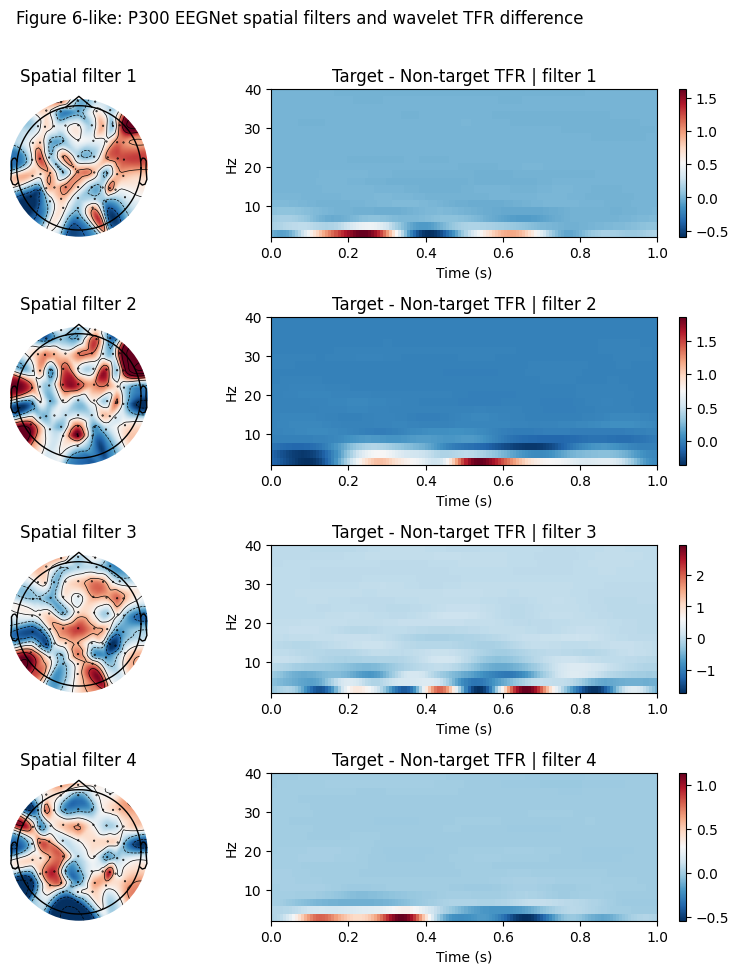

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure6_like_P300_filters_TFR.png


In [36]:
# Cell 15：Figure 6 风格 —— P300 EEGNet-4,1 空间滤波器 + wavelet time-frequency difference
# 原文 Figure 6 用的是 P300 cross-subject EEGNet-4,1。这里如果没有现成模型，会临时训练一个小模型。

def train_one_feature_model(ds, model_name="EEGNet-4,1", cv_type="cross", epochs=EPOCHS):
    subjects = np.unique(ds["subjects"])
    if len(subjects) >= 3 and cv_type == "cross":
        test_subj = subjects[-1]
        val_subj = subjects[-2]
        train_subj = subjects[:-2]
        train_idx = np.isin(ds["subjects"], train_subj)
        val_idx = ds["subjects"] == val_subj
        test_idx = ds["subjects"] == test_subj
    else:
        # subject 不够则退回第一个 subject 的 block split
        subj = subjects[0]
        idx = ds["subjects"] == subj
        block_ids = np.unique(ds["blocks"][idx])
        folds = _make_block_folds(block_ids, n_splits=min(4, len(block_ids)))
        if len(folds) < 2:
            raise RuntimeError("P300 block/subject 太少，无法训练 Figure 6 模型")
        test_blocks = folds[0]
        val_blocks = folds[1]
        train_blocks = np.concatenate(folds[2:]) if len(folds) > 2 else folds[1]
        train_idx = idx & np.isin(ds["blocks"], train_blocks)
        val_idx = idx & np.isin(ds["blocks"], val_blocks)
        test_idx = idx & np.isin(ds["blocks"], test_blocks)
        cv_type = "within"

    return train_eval_generic(
        model_name=model_name,
        X_train=ds["X"][train_idx], y_train=ds["y"][train_idx],
        X_val=ds["X"][val_idx], y_val=ds["y"][val_idx],
        X_test=ds["X"][test_idx], y_test=ds["y"][test_idx],
        nb_classes=ds["nb_classes"],
        dataset_name=ds["name"],
        sfreq=ds["sfreq"],
        metric_name=ds["metric"],
        cv_type=cv_type,
        seed=RANDOM_SEED,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        use_class_weight=ds["class_weight"],
        verbose=0,
        run_id="figure6_feature_model"
    )

def plot_p300_figure6(ds, result):
    model = result["model"]
    X_test = result["X_test"]
    y_test = result["true"]
    info = ds["info"]
    sfreq = ds["sfreq"]

    spatial_layer = model.get_layer("conv_spatial")
    W = spatial_layer.get_weights()[0]  # shape: (Chans, 1, F1, D)
    W = W[:, 0, :, :]                  # Chans × F1 × D

    # 取 depthwise conv 输出作为每个 filter 的时间序列
    activation_model = Model(inputs=model.input, outputs=model.get_layer("conv_spatial").output)
    # result["X_test"] 已经是在训练函数里按 train 均值/方差标准化后的版本
    acts = activation_model.predict(as_4d(X_test), verbose=0)
    # acts: trials × 1 × samples × filters
    acts = acts[:, 0, :, :]

    n_filters = acts.shape[-1]
    freqs = np.arange(2, 41, 2)
    n_cycles = freqs / 2.0

    fig, axes = plt.subplots(n_filters, 2, figsize=(9, 2.4 * n_filters))

    if n_filters == 1:
        axes = np.array([axes])

    for f in range(n_filters):
        ax_topo = axes[f, 0]
        weight_vec = W[:, f, 0] if W.ndim == 3 and f < W.shape[1] else W[:, 0, 0]
        try:
            mne.viz.plot_topomap(weight_vec, info, axes=ax_topo, show=False)
        except Exception:
            ax_topo.plot(weight_vec)
        ax_topo.set_title(f"Spatial filter {f+1}")

        sig = acts[:, :, f][:, np.newaxis, :]  # n_epochs × 1 × times
        power = tfr_array_morlet(sig, sfreq=sfreq, freqs=freqs, n_cycles=n_cycles, output="power", verbose=False)
        # power: epochs × channels × freqs × times
        if len(np.unique(y_test)) == 2:
            cls1 = 1
            cls0 = 0
        else:
            cls1 = np.unique(y_test)[-1]
            cls0 = np.unique(y_test)[0]
        diff = power[y_test == cls1, 0].mean(axis=0) - power[y_test == cls0, 0].mean(axis=0)

        ax_tf = axes[f, 1]
        im = ax_tf.imshow(
            diff,
            aspect="auto",
            origin="lower",
            extent=[0, X_test.shape[2] / sfreq, freqs[0], freqs[-1]],
            cmap="RdBu_r"
        )
        ax_tf.set_title(f"Target - Non-target TFR | filter {f+1}")
        ax_tf.set_xlabel("Time (s)")
        ax_tf.set_ylabel("Hz")
        plt.colorbar(im, ax=ax_tf, fraction=0.046)

    plt.suptitle("Figure 6-like: P300 EEGNet spatial filters and wavelet TFR difference", y=1.01)
    plt.tight_layout()
    out_path = OUTPUT_DIR / "Figure6_like_P300_filters_TFR.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)

if "P300" in DATASETS:
    fig6_result = train_one_feature_model(DATASETS["P300"], model_name="EEGNet-4,1", epochs=EPOCHS)
    plot_p300_figure6(DATASETS["P300"], fig6_result)
else:
    print("未加载 P300，跳过 Figure 6")

In [37]:
# Cell 16：Table 4 风格 —— P300 temporal filters ablation
# 原文 Table 4 是移除 EEGNet-4,1 的 1/2/3 个 filter 后比较 test AUC。

def clone_and_ablate_temporal_filters(model, filter_ids):
    cloned = tf.keras.models.clone_model(model)
    cloned.set_weights(model.get_weights())

    conv = cloned.get_layer("conv_temporal")
    weights = conv.get_weights()
    W = weights[0].copy()  # shape: 1 × kernLength × 1 × F1
    for f in filter_ids:
        W[:, :, :, f] = 0
    weights[0] = W
    conv.set_weights(weights)
    return cloned

def run_ablation_table(result, metric_name="auc"):
    model = result["model"]
    X_test = result["X_test"]
    y_test = result["true"]
    n_filters = model.get_layer("conv_temporal").get_weights()[0].shape[-1]

    rows = []
    base_probs = model.predict(as_4d(X_test), verbose=0)
    rows.append({"filters_removed": "None", "score": evaluate_metric(y_test, base_probs, metric_name)})

    for r in range(1, n_filters):
        for combo in itertools.combinations(range(n_filters), r):
            ablated = clone_and_ablate_temporal_filters(model, combo)
            probs = ablated.predict(as_4d(X_test), verbose=0)
            rows.append({
                "filters_removed": tuple([c+1 for c in combo]),
                "score": evaluate_metric(y_test, probs, metric_name)
            })

    df = pd.DataFrame(rows)
    return df

if "P300" in DATASETS and "fig6_result" in globals():
    ablation_df = run_ablation_table(fig6_result, metric_name=DATASETS["P300"]["metric"])
    ablation_df.to_csv(OUTPUT_DIR / "Table4_like_P300_filter_ablation.csv", index=False)
    display(ablation_df)
else:
    print("缺少 P300 fig6_result，跳过 ablation")

,filters_removed,score
0,None,0.699871
1,"(1,)",0.659992
2,"(2,)",0.691552
3,"(3,)",0.723517
4,"(4,)",0.692315
5,"(1, 2)",0.653175
6,"(1, 3)",0.617444
7,"(1, 4)",0.643974
8,"(2, 3)",0.717129
9,"(2, 4)",0.681994


Figure 7 使用结果： ('SMR', np.int64(1), 3, 'EEGNet-8,2') | mode= within


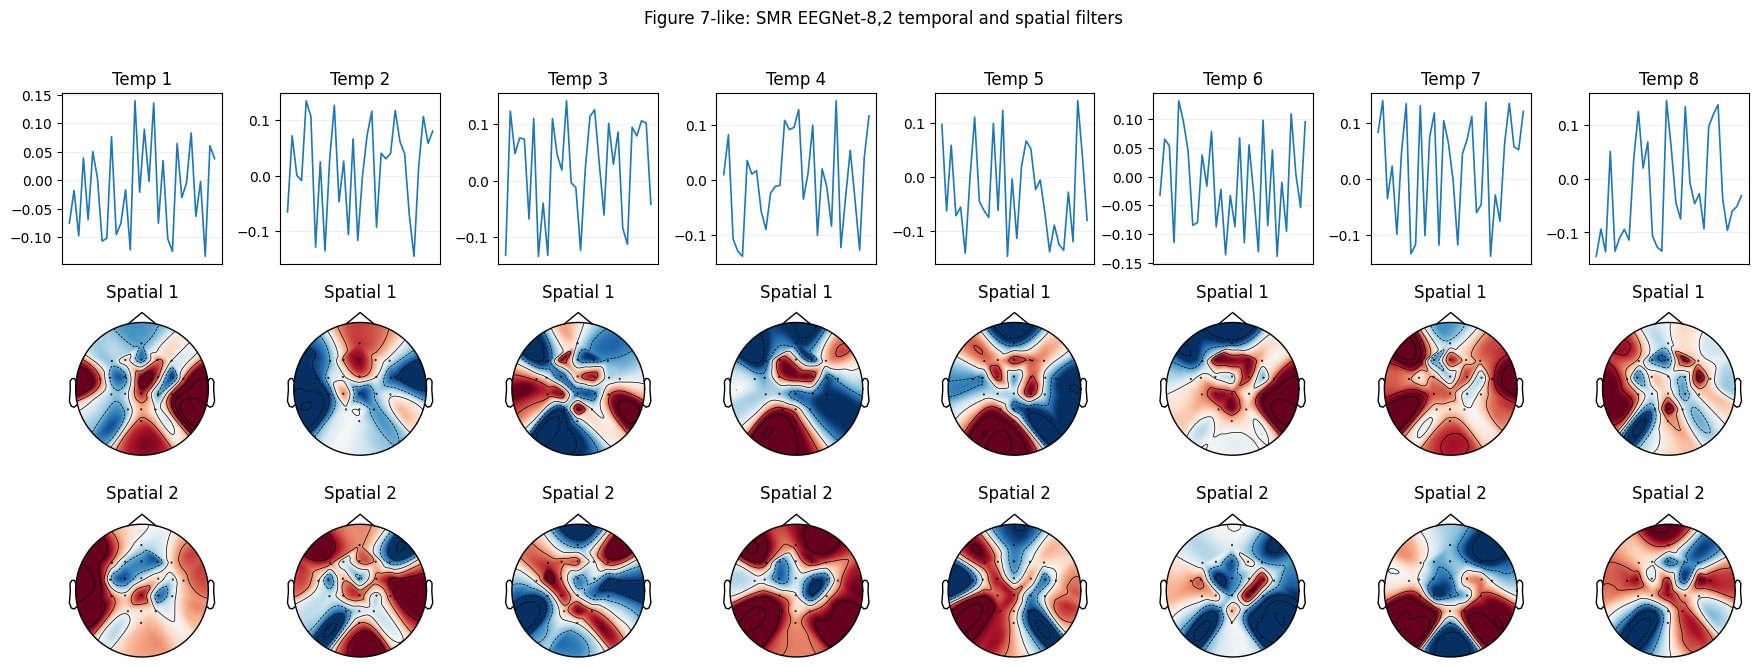

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure7_like_SMR_filters.png


In [38]:
# Cell 17：Figure 7 风格 —— SMR EEGNet-8,2 temporal kernels + spatial filters【修正版】
# 原文 Figure 7 用 SMR subject 3 的 within-subject EEGNet-8,2。
# 关键修改：优先找 within subject=3 的结果，而不是优先拿 cross result。

def plot_smr_figure7(ds, result):
    model = result["model"]
    info = ds["info"]

    Wt = model.get_layer("conv_temporal").get_weights()[0]  # 1 × kernLength × 1 × F1
    temporal = Wt[0, :, 0, :]
    Ws = model.get_layer("conv_spatial").get_weights()[0][:, 0, :, :]  # Chans × F1 × D

    F1 = temporal.shape[1]
    D = Ws.shape[2]

    fig, axes = plt.subplots(D + 1, F1, figsize=(2.2 * F1, 2.2 * (D + 1)))
    if F1 == 1:
        axes = axes[:, np.newaxis]

    for f in range(F1):
        ax = axes[0, f]
        ax.plot(temporal[:, f], linewidth=1.2)
        ax.set_title(f"Temp {f+1}")
        ax.set_xticks([])
        ax.grid(alpha=0.2)

        for d in range(D):
            ax2 = axes[d + 1, f]
            plot_topomap_safe(Ws[:, f, d], info, ax2, title=f"Spatial {d+1}")

    plt.suptitle("Figure 7-like: SMR EEGNet-8,2 temporal and spatial filters", y=1.02)
    plt.tight_layout()
    out_path = OUTPUT_DIR / "Figure7_like_SMR_filters.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)

if "SMR" in DATASETS:
    key, smr_result, mode = get_first_within_or_cross("SMR", "EEGNet-8,2", prefer_subject=3)
    print("Figure 7 使用结果：", key, "| mode=", mode)
    if smr_result is not None:
        plot_smr_figure7(DATASETS["SMR"], smr_result)
    else:
        print("没有找到 SMR EEGNet-8,2 结果，请先运行 Cell 11C 或 Cell 12C")
else:
    print("未加载 SMR，跳过 Figure 7")


Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 22 dim * 4.1e+14  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 22 dim * 4.1e+14  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 2 (2.2e-16 eps * 22 dim * 4.1e+14  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
D

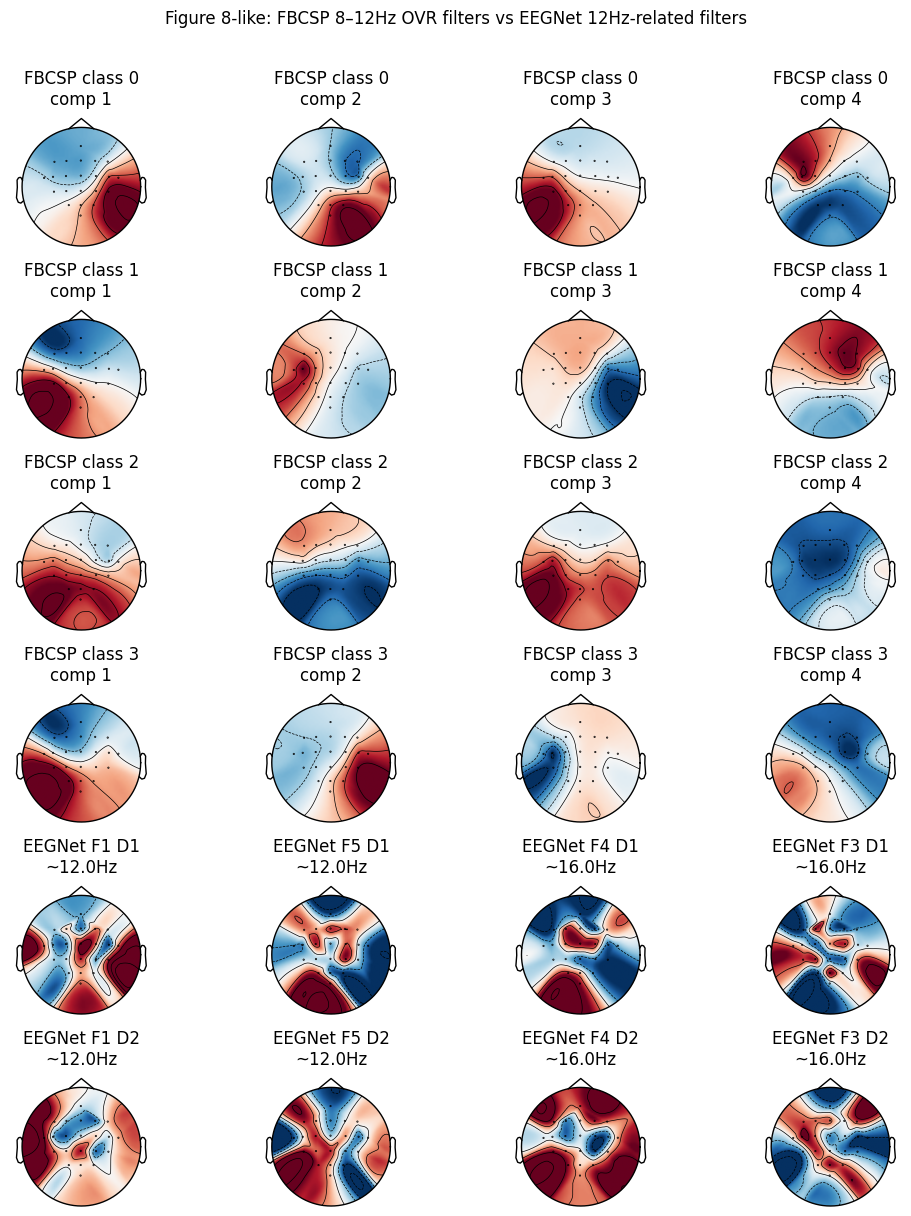

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure8_like_FBCSP_OVR_vs_EEGNet.png


In [39]:
# Cell 18：Figure 8 风格 —— FBCSP OVR 空间滤波器 vs EEGNet 空间滤波器【更对应论文版】
# 原文 Figure 8：A 部分是 8–12Hz filter-bank 中四个 one-vs-rest 类别组合的 FBCSP 空间滤波器；
# B 部分是 EEGNet-8,2 中接近 12Hz 的 temporal filters 对应的两个 spatial filters。


def _fit_ovr_csp_patterns_812(X_train, y_train, sfreq=128, n_components=4):
    X_train = np.asarray(X_train, dtype=np.float64)
    X_812 = mne.filter.filter_data(X_train.copy(), sfreq=sfreq, l_freq=8, h_freq=12, verbose=False)
    classes = np.sort(np.unique(y_train))
    patterns_by_class = []
    for cls in classes:
        y_bin = (y_train == cls).astype(int)
        if len(np.unique(y_bin)) < 2:
            continue
        csp = CSP(n_components=min(n_components, X_812.shape[1]-1), reg="ledoit_wolf", log=True, norm_trace=False)
        csp.fit(X_812, y_bin)
        patterns = csp.patterns_[:n_components]
        patterns_by_class.append((int(cls), patterns))
    return patterns_by_class


def _dominant_freqs_from_temporal_kernels(Wt, sfreq):
    freqs = np.fft.rfftfreq(Wt.shape[0], d=1/sfreq)
    dom_freqs = []
    for f in range(Wt.shape[1]):
        spec = np.abs(np.fft.rfft(Wt[:, f]))
        mask = (freqs >= 4) & (freqs <= 40)
        if not np.any(mask):
            dom_freqs.append(np.nan)
        else:
            dom_freqs.append(float(freqs[mask][np.argmax(spec[mask])]))
    return np.asarray(dom_freqs)


def plot_fig8_like(ds, eegnet_result):
    if ds["name"] != "SMR":
        print("Figure 8 只适合 SMR")
        return

    X_train = np.asarray(eegnet_result["X_train"], dtype=np.float64)
    y_train = np.asarray(eegnet_result["y_train"])
    info = ds["info"]

    patterns_by_class = _fit_ovr_csp_patterns_812(X_train, y_train, sfreq=ds["sfreq"], n_components=4)
    if len(patterns_by_class) == 0:
        print("FBCSP/OVR CSP patterns 拟合失败，跳过 Figure 8")
        return

    eegnet = eegnet_result["model"]
    Ws = eegnet.get_layer("conv_spatial").get_weights()[0][:, 0, :, :]  # Chans × F1 × D
    Wt = eegnet.get_layer("conv_temporal").get_weights()[0][0, :, 0, :] # time × F1
    dom_freqs = _dominant_freqs_from_temporal_kernels(Wt, ds["sfreq"])
    chosen = np.argsort(np.abs(dom_freqs - 12))[:4]

    # 4 行 FBCSP OVR + D 行 EEGNet。D 通常为 2，所以整体是 6×4，更接近原文 Figure 8。
    D = Ws.shape[2]
    n_rows = len(patterns_by_class) + D
    fig, axes = plt.subplots(n_rows, 4, figsize=(10.5, 2.0 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])

    row = 0
    for cls, patterns in patterns_by_class:
        for comp_i in range(4):
            ax = axes[row, comp_i]
            if comp_i < patterns.shape[0]:
                plot_topomap_safe(patterns[comp_i], info, ax, title=f"FBCSP class {cls}\ncomp {comp_i+1}")
            else:
                ax.axis("off")
        row += 1

    for d in range(D):
        for col_i, f in enumerate(chosen):
            vec = Ws[:, f, d]
            plot_topomap_safe(vec, info, axes[row, col_i], title=f"EEGNet F{f+1} D{d+1}\n~{dom_freqs[f]:.1f}Hz")
        row += 1

    plt.suptitle("Figure 8-like: FBCSP 8–12Hz OVR filters vs EEGNet 12Hz-related filters", y=1.01)
    plt.tight_layout()
    out_path = OUTPUT_DIR / "Figure8_like_FBCSP_OVR_vs_EEGNet.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)

if "SMR" in DATASETS and "smr_result" in globals() and smr_result is not None:
    plot_fig8_like(DATASETS["SMR"], smr_result)
else:
    print("缺少 SMR EEGNet 结果，跳过 Figure 8")


Figure 9 使用结果： ('MRCP', 1, 'EEGNet-8,2') | mode= cross


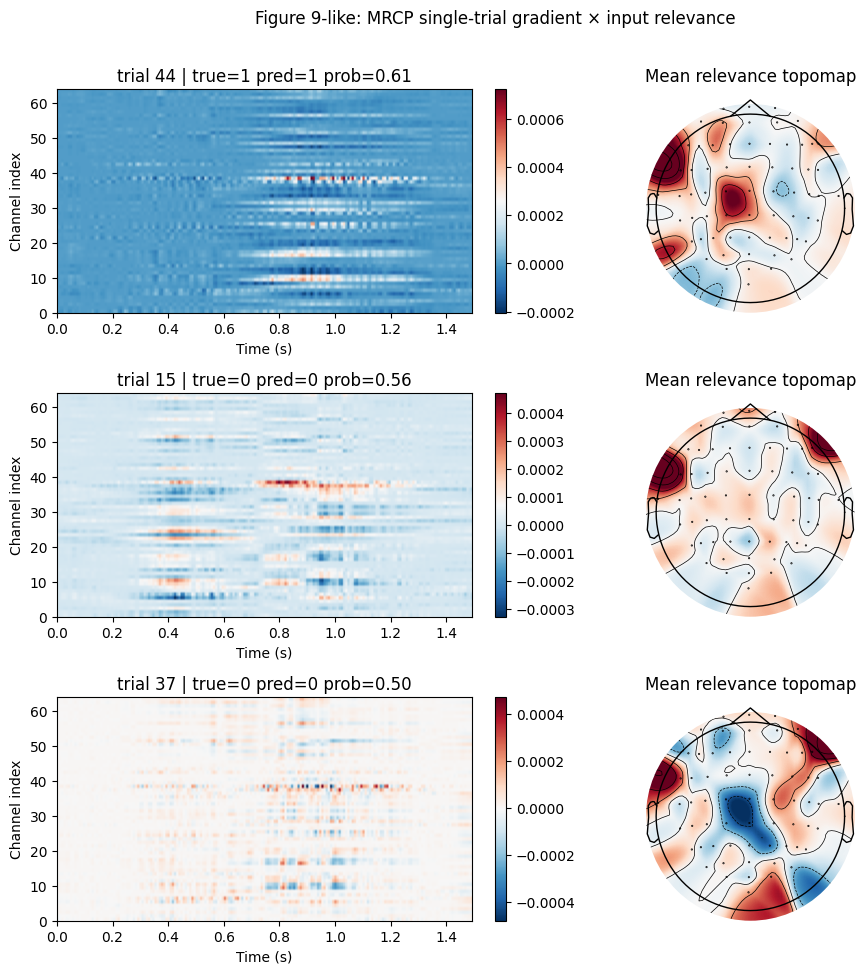

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure9_like_MRCP_relevance.png
Figure 10 使用结果： ('ERN', 1, 'EEGNet-4,2') | mode= cross


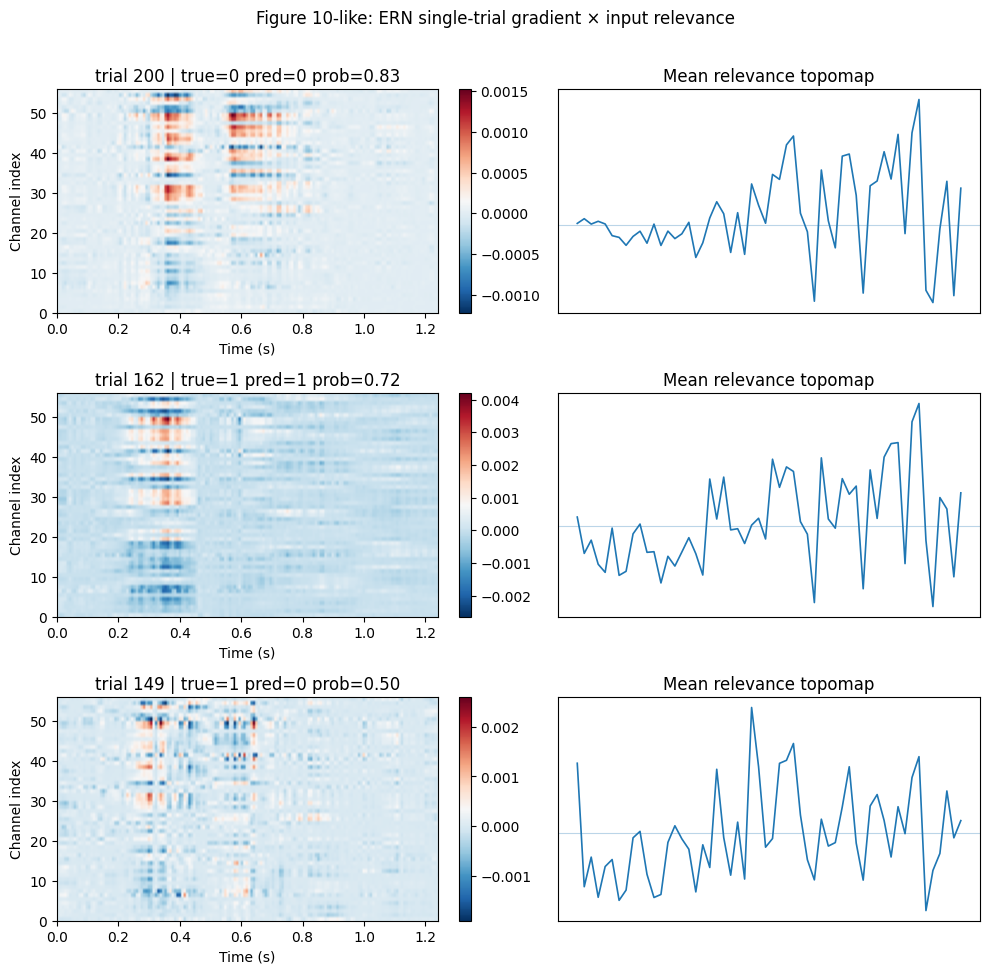

saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/Figure10_like_ERN_relevance.png


In [40]:
# Cell 19：Figure 9 / Figure 10 风格 —— gradient × input relevance【保留替代说明 + 稳定版】
# 原文 Figure 9 / 10 用 DeepLIFT；这里用更容易跑通的 gradient × input 替代。
# 报告里必须写清楚：这是“可解释性分析近似复现”，不是 DeepLIFT 严格复现。

def gradient_relevance(model, x_single, class_id=None):
    x = tf.convert_to_tensor(as_4d(x_single[np.newaxis, ...]), dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        probs = model(x, training=False)
        if class_id is None:
            class_id = int(tf.argmax(probs[0]).numpy())
        score = probs[:, class_id]
    grads = tape.gradient(score, x).numpy()[0, :, :, 0]
    relevance = grads * x_single
    return relevance, class_id, float(probs[0, class_id].numpy())

def plot_relevance_trials(ds, result, out_name, title, n_trials=3):
    model = result["model"]
    X = result["X_test"]
    y = result["true"]
    probs = result["probs"]
    pred = probs.argmax(axis=1)
    conf = probs.max(axis=1)

    correct = np.where(pred == y)[0]
    chosen = []
    if len(correct) > 0:
        chosen.append(correct[np.argmax(conf[correct])])
    if ds["nb_classes"] >= 2:
        for cls in np.unique(y):
            idx = correct[y[correct] == cls] if len(correct) else np.array([])
            if len(idx) > 0 and idx[np.argmax(conf[idx])] not in chosen:
                chosen.append(idx[np.argmax(conf[idx])])
    low = np.argsort(conf)
    for i in low:
        if i not in chosen:
            chosen.append(i)
        if len(chosen) >= n_trials:
            break
    chosen = chosen[:n_trials]

    fig, axes = plt.subplots(len(chosen), 2, figsize=(10, 3.2 * len(chosen)))
    if len(chosen) == 1:
        axes = np.array([axes])

    times = np.arange(X.shape[2]) / ds["sfreq"]

    for row, idx in enumerate(chosen):
        rel, pred_cls, pred_prob = gradient_relevance(model, X[idx], class_id=int(pred[idx]))

        ax0 = axes[row, 0]
        im = ax0.imshow(rel, aspect="auto", origin="lower", extent=[times[0], times[-1], 0, rel.shape[0]], cmap="RdBu_r")
        ax0.set_title(f"trial {idx} | true={y[idx]} pred={pred_cls} prob={pred_prob:.2f}")
        ax0.set_xlabel("Time (s)")
        ax0.set_ylabel("Channel index")
        plt.colorbar(im, ax=ax0, fraction=0.046)

        ax1 = axes[row, 1]
        topo_vec = rel.mean(axis=1)
        plot_topomap_safe(topo_vec, ds["info"], ax1, title="Mean relevance topomap")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    out_path = OUTPUT_DIR / out_name
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", out_path)

if "MRCP" in DATASETS:
    key, mrcp_result, mode = get_first_cross_or_within("MRCP", "EEGNet-8,2")
    print("Figure 9 使用结果：", key, "| mode=", mode)
    if mrcp_result is not None:
        plot_relevance_trials(
            DATASETS["MRCP"], mrcp_result,
            out_name="Figure9_like_MRCP_relevance.png",
            title="Figure 9-like: MRCP single-trial gradient × input relevance"
        )
    else:
        print("没有找到 MRCP EEGNet-8,2 结果")
else:
    print("未加载 MRCP")

if "ERN" in DATASETS:
    key, ern_result, mode = get_first_cross_or_within("ERN", "EEGNet-4,2")
    print("Figure 10 使用结果：", key, "| mode=", mode)
    if ern_result is not None:
        plot_relevance_trials(
            DATASETS["ERN"], ern_result,
            out_name="Figure10_like_ERN_relevance.png",
            title="Figure 10-like: ERN single-trial gradient × input relevance"
        )
    else:
        print("没有找到 ERN EEGNet-4,2 结果")
else:
    print("未加载 ERN")


In [41]:
# Cell 20：结果总览、论文对应检查与保存

print("OUTPUT_DIR =", OUTPUT_DIR)
print("\n生成的文件：")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

correspondence_rows = [
    {"Paper item": "Figure 1", "Notebook output": "Figure1_like_EEGNet_architecture.png", "Level": "structure-level reproduction"},
    {"Paper item": "Table 1", "Notebook output": "Table1_paper_dataset_summary.csv + Table1_current_loaded_dataset_summary.csv", "Level": "paper vs current data comparison"},
    {"Paper item": "Table 2", "Notebook output": "Table2_like_EEGNet_architecture_*.csv", "Level": "architecture table reproduction"},
    {"Paper item": "Table 3", "Notebook output": "Table3_like_model_parameter_counts_wide.csv", "Level": "parameter-count reproduction using current data shapes"},
    {"Paper item": "Figure 2", "Notebook output": "Figure2_within_subject_P300_MRCP_ERN.png", "Level": "format + workflow reproduction"},
    {"Paper item": "Figure 3", "Notebook output": "Figure3_within_subject_SMR.png", "Level": "format + workflow reproduction"},
    {"Paper item": "Figure 4", "Notebook output": "Figure4_cross_subject_P300_MRCP_ERN.png", "Level": "format + workflow reproduction"},
    {"Paper item": "Figure 5", "Notebook output": "Figure5_cross_subject_SMR.png", "Level": "format + workflow reproduction"},
    {"Paper item": "Statistical tests", "Notebook output": "Figure2_5_global_statistical_tests.csv + pairwise tests", "Level": "added to match paper reporting"},
    {"Paper item": "Figure 6", "Notebook output": "Figure6_like_P300_filters_TFR.png", "Level": "approximate; affected by replacement P300"},
    {"Paper item": "Table 4", "Notebook output": "Table4_like_P300_filter_ablation.csv", "Level": "approximate; affected by replacement P300"},
    {"Paper item": "Figure 7", "Notebook output": "Figure7_like_SMR_filters.png", "Level": "close if SMR channels/montage are correct"},
    {"Paper item": "Figure 8", "Notebook output": "Figure8_like_FBCSP_OVR_vs_EEGNet.png", "Level": "closer OVR-style reproduction"},
    {"Paper item": "Figure 9", "Notebook output": "Figure9_like_MRCP_relevance.png", "Level": "uses gradient × input, not DeepLIFT"},
    {"Paper item": "Figure 10", "Notebook output": "Figure10_like_ERN_relevance.png", "Level": "uses gradient × input, not DeepLIFT"},
]
correspondence_df = pd.DataFrame(correspondence_rows)
correspondence_df.to_csv(OUTPUT_DIR / "paper_item_correspondence_checklist.csv", index=False)
print("\n论文项目对应检查表：")
display(correspondence_df)
print("saved:", OUTPUT_DIR / "paper_item_correspondence_checklist.csv")


OUTPUT_DIR = /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip

生成的文件：
 - ERN_DeepConvNet_cross_cross_f1_best.weights.h5
 - ERN_DeepConvNet_cross_cross_f2_best.weights.h5
 - ERN_DeepConvNet_cross_cross_f3_best.weights.h5
 - ERN_DeepConvNet_within_subj11_fold1_best.weights.h5
 - ERN_DeepConvNet_within_subj11_fold2_best.weights.h5
 - ERN_DeepConvNet_within_subj11_fold3_best.weights.h5
 - ERN_DeepConvNet_within_subj11_fold4_best.weights.h5
 - ERN_DeepConvNet_within_subj12_fold1_best.weights.h5
 - ERN_DeepConvNet_within_subj12_fold2_best.weights.h5
 - ERN_DeepConvNet_within_subj12_fold3_best.weights.h5
 - ERN_DeepConvNet_within_subj12_fold4_best.weights.h5
 - ERN_DeepConvNet_within_subj13_fold1_best.weights.h5
 - ERN_DeepConvNet_within_subj13_fold2_best.weights.h5
 - ERN_DeepConvNet_within_subj13_fold3_best.weights.h5
 - ERN_DeepConvNet_within_subj13_fold4_best.weights.h5
 - ERN_DeepConvNet_within_subj14_fold1_best.weights.h5
 - ERN_DeepConvNet_within_subj14_fold2_best.weights.h5


,Paper item,Notebook output,Level
0,Figure 1,Figure1_like_EEGNet_architecture.png,structure-level reproduction
1,Table 1,Table1_paper_dataset_summary.csv + Table1_curr...,paper vs current data comparison
2,Table 2,Table2_like_EEGNet_architecture_*.csv,architecture table reproduction
3,Table 3,Table3_like_model_parameter_counts_wide.csv,parameter-count reproduction using current dat...
4,Figure 2,Figure2_within_subject_P300_MRCP_ERN.png,format + workflow reproduction
5,Figure 3,Figure3_within_subject_SMR.png,format + workflow reproduction
6,Figure 4,Figure4_cross_subject_P300_MRCP_ERN.png,format + workflow reproduction
7,Figure 5,Figure5_cross_subject_SMR.png,format + workflow reproduction
8,Statistical tests,Figure2_5_global_statistical_tests.csv + pairw...,added to match paper reporting
9,Figure 6,Figure6_like_P300_filters_TFR.png,approximate; affected by replacement P300


saved: /root/autodl-tmp/EEGNet_reproduction_outputs_smoke_fourzip/paper_item_correspondence_checklist.csv
